# AAL3 EEG-fMRI Representational Connectivity

This notebook turns the existing EEG-fMRI RSA fusion logic into an AAL3 ROI-level, time-resolved representational connectivity analysis.

Important interpretation: this is not classical BOLD functional connectivity. Each ROI signal is an EEG-fused representational timecourse: the similarity between that ROI's fMRI stimulus geometry and the EEG stimulus geometry at each time point. ROI-to-ROI edges therefore reflect similarity/co-fluctuation of fused representational dynamics.

## Analysis Overview

1. Load EEG data, fMRI single-trial beta patterns, and AAL3 ROI masks.
2. Compute condition-specific EEG RDM vectors for pleasant, neutral, and unpleasant stimuli.
3. Compute condition-specific fMRI RDM vectors for every AAL3 ROI.
4. Fuse modalities by correlating fMRI ROI RDMs with EEG RDMs over time.
5. Baseline-correct ROI fusion timecourses.
6. Compute ROI-to-ROI representational connectivity using epoch-level and sliding-window correlations.
7. Run edge-level statistics and save tables/figures.

The expensive intermediate arrays are cached in `aal3_fusion_connectivity_outputs/`.

In [ ]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist
from scipy.stats import ttest_1samp, ttest_rel
from statsmodels.stats.multitest import fdrcorrection

import nibabel as nib
from nilearn.image import resample_img

sns.set_context("talk")
sns.set_style("white")
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_DIR = Path.cwd()
PARENT_DIR = PROJECT_DIR.parent

EEG_PATH = PARENT_DIR / "IAPS_EEG_RSA" / "eeg_raw.npy"
FMRI_PATH = PARENT_DIR / "IAPS_Searchlight" / "allsub_avg.npy"
BRAIN_MASK_PATH = PARENT_DIR / "IAPS_Searchlight" / "mask.npy"
TEMPLATE_IMG_PATH = PARENT_DIR / "IAPS_fMRI_RSA" / "fMRI_singletrial_betas" / "nifti" / "Nt1.img"
AAL3_DIR = PARENT_DIR / "data" / "masks" / "AAL3" / "new"

OUT_DIR = PROJECT_DIR / "aal3_fusion_connectivity_outputs"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
for d in [OUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Condition order follows the existing wholebrain RSA fusion notebook.
CONDITIONS = {
    "pleasant": np.arange(0, 20),
    "neutral": np.arange(20, 40),
    "unpleasant": np.arange(40, 60),
}
CONDITION_NAMES = list(CONDITIONS.keys())

# The existing ROI block in RSA_fmri_eeg.ipynb used this 65-ROI AAL3 set.
DEFAULT_AAL3_65_ROIS = [
    "ACCpre", "ACCsub", "ACCsup", "Amygdala", "Angular", "Calcarine", "Caudate",
    "Cerebellum", "Cuneus", "FrontalInfOper", "FrontalInfOrb", "FrontalInfTri",
    "FrontalMedOrb", "FrontalMid", "FrontalSup", "FrontalSupMedial", "Fusiform",
    "Heschl", "Hippocampus", "Insula", "LC", "Lingual", "NAcc", "OccipitalInf",
    "OccipitalMid", "OccipitalSup", "OFCant", "OFClat", "OFCmed", "OFCpost",
    "Pallidum", "ParacentralLobule", "ParaHippocampal", "ParietalInf", "ParietalSup",
    "Postcentral", "Precentral", "Precuneus", "Putamen", "RedN", "RolandicOper",
    "SNpc", "SNpr", "SuppMotorArea", "SupraMarginal", "TemporalInf", "TemporalMid",
    "TemporalPoleMid", "TemporalPoleSup", "TemporalSup", "ThalAV", "ThalIL", "ThalLGN",
    "ThalLP", "ThalMDl", "ThalMDm", "ThalMGN", "ThalPuA", "ThalPuI", "ThalPuL",
    "ThalPuM", "ThalRe", "ThalVA", "ThalVL", "ThalVPL",
]

# Set USE_ALL_AAL3_MASK_FILES=True to include every .nii.gz file in AAL3/new.
USE_ALL_AAL3_MASK_FILES = False
ROI_NAMES = sorted([p.stem.replace(".nii", "") for p in AAL3_DIR.glob("*.nii.gz")]) if USE_ALL_AAL3_MASK_FILES else DEFAULT_AAL3_65_ROIS

N_TIMEPOINTS = 575
TIMES_MS = np.arange(1, N_TIMEPOINTS + 1) * 4 - 300
BASELINE_MASK = TIMES_MS < 0

# Main choices.
RDM_METRIC = "correlation"
FUSION_CORRELATION = "spearman"  # "spearman" matches the searchlight fusion logic; "pearson" is faster.
MIN_VALID_VOXELS_PER_ROI = 5
FORCE_RECOMPUTE_EEG_RDMS = False
FORCE_RECOMPUTE_FMRI_RDMS = False
FORCE_RECOMPUTE_FUSION = False

print("Project:", PROJECT_DIR)
print("Output:", OUT_DIR)
print("ROIs:", len(ROI_NAMES))
print("Time axis:", TIMES_MS[0], "to", TIMES_MS[-1], "ms")

In [ ]:
for path in [EEG_PATH, FMRI_PATH, BRAIN_MASK_PATH, TEMPLATE_IMG_PATH, AAL3_DIR]:
    if not path.exists():
        raise FileNotFoundError(path)

eeg_arr = np.load(EEG_PATH, mmap_mode="r")
allsub_avg = np.load(FMRI_PATH, mmap_mode="r")
brain_mask = np.load(BRAIN_MASK_PATH, mmap_mode="r")
template_img = nib.load(str(TEMPLATE_IMG_PATH))

print("EEG:", eeg_arr.shape, eeg_arr.dtype)
print("fMRI:", allsub_avg.shape, allsub_avg.dtype)
print("Brain mask:", brain_mask.shape, brain_mask.dtype)
print("Template image:", template_img.shape, template_img.header.get_zooms()[:3])

expected_voxels = int(np.prod(brain_mask.shape))
if allsub_avg.shape[-1] != expected_voxels:
    raise ValueError(f"fMRI voxel dimension {allsub_avg.shape[-1]} does not match mask grid {expected_voxels}.")
if eeg_arr.shape[-1] != N_TIMEPOINTS:
    raise ValueError(f"EEG time dimension {eeg_arr.shape[-1]} does not match expected {N_TIMEPOINTS}.")

## Helper Functions

In [ ]:
def rdm_vector(patterns, metric="correlation"):
    """Return the upper-triangle RDM vector for rows=stimuli, columns=features."""
    patterns = np.asarray(patterns, dtype=np.float32)
    patterns = np.nan_to_num(patterns, nan=0.0, posinf=0.0, neginf=0.0)
    if patterns.ndim != 2 or patterns.shape[0] < 2 or patterns.shape[1] < 1:
        return np.full(patterns.shape[0] * (patterns.shape[0] - 1) // 2, np.nan, dtype=np.float32)
    vec = pdist(patterns, metric=metric).astype(np.float32)
    return np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)


def ordinal_rank_rows(x):
    """Fast row-wise ordinal ranks. Ties are rare in continuous RDMs; use scipy.rankdata if exact tie averaging is needed."""
    x = np.asarray(x, dtype=np.float32)
    was_1d = x.ndim == 1
    if was_1d:
        x = x[None, :]
    order = np.argsort(x, axis=1)
    ranks = np.empty_like(order, dtype=np.float32)
    rows = np.arange(x.shape[0])[:, None]
    ranks[rows, order] = np.arange(x.shape[1], dtype=np.float32)
    return ranks[0] if was_1d else ranks


def normalize_for_rowwise_corr(x, method="pearson"):
    """Normalize a vector or matrix so dot products equal Pearson/Spearman correlations."""
    x = np.asarray(x, dtype=np.float32)
    was_1d = x.ndim == 1
    if was_1d:
        x = x[None, :]

    finite_rows = np.isfinite(x).all(axis=1)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    if method == "spearman":
        x = ordinal_rank_rows(x)
    elif method != "pearson":
        raise ValueError("method must be 'pearson' or 'spearman'")

    x = x - x.mean(axis=1, keepdims=True)
    denom = np.linalg.norm(x, axis=1, keepdims=True)
    valid = finite_rows & (denom[:, 0] > 1e-8)
    x = np.divide(x, denom, out=np.full_like(x, np.nan, dtype=np.float32), where=denom > 1e-8)
    x[~valid] = np.nan
    return x[0] if was_1d else x


def fisher_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return np.arctanh(r)


def fisher_r(z):
    return np.tanh(z)


def baseline_correct(data, times_ms=TIMES_MS):
    """Subtract each subject/condition/ROI baseline mean over time < 0 ms."""
    baseline = times_ms < 0
    base_mean = np.nanmean(data[..., baseline], axis=-1, keepdims=True)
    return data - base_mean


def zscore_timecourses(data, axis=-1):
    mean = np.nanmean(data, axis=axis, keepdims=True)
    std = np.nanstd(data, axis=axis, keepdims=True)
    return np.divide(data - mean, std, out=np.zeros_like(data, dtype=np.float32), where=std > 1e-8)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

## Step 1: Compute Condition-Specific EEG RDM Vectors

In [ ]:
def compute_condition_eeg_rdm_vectors(eeg_arr, conditions, cache_path, force=False, metric="correlation"):
    """Compute EEG RDM upper-triangle vectors for each subject, condition, and time point."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force:
        print("Loading cached EEG RDM vectors:", cache_path)
        z = np.load(cache_path, allow_pickle=True)
        return z["eeg_vecs"], list(z["condition_names"]), z["times_ms"]

    n_subjects, n_channels, n_stimuli, n_time = eeg_arr.shape
    first_cond_len = len(next(iter(conditions.values())))
    n_pairs = first_cond_len * (first_cond_len - 1) // 2
    condition_names = list(conditions.keys())
    eeg_vecs = np.empty((n_subjects, len(condition_names), n_time, n_pairs), dtype=np.float32)

    for subj in range(n_subjects):
        print(f"Subject {subj + 1:02d}/{n_subjects}: EEG RDMs")
        for ci, cond_name in enumerate(condition_names):
            stim_idx = np.asarray(conditions[cond_name])
            # Use np.take to preserve axis order. Fancy indexing like eeg_arr[subj, :, stim_idx, :]
            # moves the stimulus axis to the front and would compute channel-by-channel RDMs.
            eeg_cond = np.take(eeg_arr[subj], stim_idx, axis=1)  # channels x stimuli x time
            for t in range(n_time):
                patterns = eeg_cond[:, :, t].T  # stimuli x channels
                eeg_vecs[subj, ci, t] = rdm_vector(patterns, metric=metric)

    np.savez_compressed(
        cache_path,
        eeg_vecs=eeg_vecs,
        condition_names=np.array(condition_names),
        times_ms=TIMES_MS,
        metric=np.array(metric),
    )
    print("Saved:", cache_path)
    return eeg_vecs, condition_names, TIMES_MS


EEG_RDM_CACHE = OUT_DIR / "condition_eeg_rdm_vectors.npz"
eeg_vecs, condition_names, times_ms = compute_condition_eeg_rdm_vectors(
    eeg_arr,
    CONDITIONS,
    EEG_RDM_CACHE,
    force=FORCE_RECOMPUTE_EEG_RDMS,
    metric=RDM_METRIC,
)
print("EEG RDM vectors:", eeg_vecs.shape)

## Step 2: Load and Resample AAL3 ROI Masks

In [ ]:
def load_aal3_masks(roi_names, aal3_dir, target_img, min_voxels=5):
    masks = {}
    voxel_counts = {}
    missing = []

    for roi in roi_names:
        roi_path = Path(aal3_dir) / f"{roi}.nii.gz"
        if not roi_path.exists():
            missing.append(roi)
            continue
        roi_img = nib.load(str(roi_path))
        roi_resampled = resample_img(
            roi_img,
            target_affine=target_img.affine,
            target_shape=target_img.shape[:3],
            interpolation="nearest",
        )
        mask = roi_resampled.get_fdata() > 0
        voxel_count = int(mask.sum())
        if voxel_count < min_voxels:
            print(f"Skipping {roi}: only {voxel_count} voxels after resampling")
            continue
        masks[roi] = mask.astype(bool)
        voxel_counts[roi] = voxel_count

    if missing:
        print("Missing masks:", missing)
    print(f"Loaded {len(masks)} ROI masks")
    return masks, voxel_counts


aal3_masks, voxel_counts = load_aal3_masks(
    ROI_NAMES,
    AAL3_DIR,
    template_img,
    min_voxels=MIN_VALID_VOXELS_PER_ROI,
)
roi_names = list(aal3_masks.keys())
voxel_count_arr = np.array([voxel_counts[r] for r in roi_names], dtype=np.int32)

pd.DataFrame({"roi": roi_names, "voxel_count": voxel_count_arr}).to_csv(
    TABLE_DIR / "aal3_roi_voxel_counts.csv", index=False
)
print(pd.DataFrame({"roi": roi_names, "voxel_count": voxel_count_arr}).head())

## Step 3: Compute AAL3 fMRI ROI RDM Vectors

In [ ]:
def compute_fmri_roi_rdm_vectors(allsub_avg, masks, conditions, cache_path, force=False, metric="correlation"):
    """Compute fMRI ROI RDM upper-triangle vectors: subjects x conditions x ROIs x pairs."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force:
        print("Loading cached fMRI ROI RDM vectors:", cache_path)
        z = np.load(cache_path, allow_pickle=True)
        return z["fmri_vecs"], list(z["roi_names"]), list(z["condition_names"]), z["voxel_counts"]

    roi_names = list(masks.keys())
    condition_names = list(conditions.keys())
    n_subjects = allsub_avg.shape[0]
    first_cond_len = len(next(iter(conditions.values())))
    n_pairs = first_cond_len * (first_cond_len - 1) // 2
    fmri_vecs = np.full((n_subjects, len(condition_names), len(roi_names), n_pairs), np.nan, dtype=np.float32)
    voxel_counts = np.array([int(masks[r].sum()) for r in roi_names], dtype=np.int32)
    flat_masks = {roi: masks[roi].ravel() for roi in roi_names}

    for subj in range(n_subjects):
        print(f"Subject {subj + 1:02d}/{n_subjects}: fMRI ROI RDMs")
        subj_data = np.asarray(allsub_avg[subj], dtype=np.float32)  # stimuli x voxels
        for ci, cond_name in enumerate(condition_names):
            stim_idx = np.asarray(conditions[cond_name])
            subj_cond = subj_data[stim_idx]
            for ri, roi in enumerate(roi_names):
                mask_flat = flat_masks[roi]
                patterns = subj_cond[:, mask_flat]
                valid_voxels = np.isfinite(patterns).all(axis=0)
                patterns = patterns[:, valid_voxels]
                if patterns.shape[1] < MIN_VALID_VOXELS_PER_ROI:
                    continue
                fmri_vecs[subj, ci, ri] = rdm_vector(patterns, metric=metric)

    np.savez_compressed(
        cache_path,
        fmri_vecs=fmri_vecs,
        roi_names=np.array(roi_names),
        condition_names=np.array(condition_names),
        voxel_counts=voxel_counts,
        metric=np.array(metric),
    )
    print("Saved:", cache_path)
    return fmri_vecs, roi_names, condition_names, voxel_counts


FMRI_RDM_CACHE = OUT_DIR / "aal3_fmri_roi_rdm_vectors.npz"
fmri_vecs, roi_names, condition_names, voxel_count_arr = compute_fmri_roi_rdm_vectors(
    allsub_avg,
    aal3_masks,
    CONDITIONS,
    FMRI_RDM_CACHE,
    force=FORCE_RECOMPUTE_FMRI_RDMS,
    metric=RDM_METRIC,
)
print("fMRI ROI RDM vectors:", fmri_vecs.shape)

## Step 4: EEG-fMRI ROI Fusion

`fusion_ts[subject, condition, roi, time]` is the correlation between one fMRI ROI RDM and the EEG RDM at that time point.

In [ ]:
def compute_roi_fusion_timeseries(fmri_vecs, eeg_vecs, cache_path, force=False, method="spearman"):
    """Fuse fMRI ROI RDMs with EEG RDMs over time."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force:
        print("Loading cached ROI fusion timecourses:", cache_path)
        z = np.load(cache_path, allow_pickle=True)
        return z["fusion_ts"], list(z["roi_names"]), list(z["condition_names"]), z["times_ms"]

    n_subjects, n_conditions, n_rois, _ = fmri_vecs.shape
    n_time = eeg_vecs.shape[2]
    fusion_ts = np.full((n_subjects, n_conditions, n_rois, n_time), np.nan, dtype=np.float32)

    for subj in range(n_subjects):
        print(f"Subject {subj + 1:02d}/{n_subjects}: ROI fusion")
        for ci in range(n_conditions):
            eeg_norm = normalize_for_rowwise_corr(eeg_vecs[subj, ci], method=method)  # time x pairs
            for ri in range(n_rois):
                brain_norm = normalize_for_rowwise_corr(fmri_vecs[subj, ci, ri], method=method)  # pairs
                if np.isfinite(brain_norm).all():
                    fusion_ts[subj, ci, ri] = eeg_norm @ brain_norm

    np.savez_compressed(
        cache_path,
        fusion_ts=fusion_ts,
        roi_names=np.array(roi_names),
        condition_names=np.array(condition_names),
        times_ms=TIMES_MS,
        fusion_correlation=np.array(method),
    )
    print("Saved:", cache_path)
    return fusion_ts, roi_names, condition_names, TIMES_MS


FUSION_CACHE = OUT_DIR / "aal3_roi_eeg_fmri_fusion_timeseries.npz"
fusion_ts, roi_names, condition_names, times_ms = compute_roi_fusion_timeseries(
    fmri_vecs,
    eeg_vecs,
    FUSION_CACHE,
    force=FORCE_RECOMPUTE_FUSION,
    method=FUSION_CORRELATION,
)
fusion_bc = baseline_correct(fusion_ts, times_ms)

print("Fusion timecourses:", fusion_ts.shape)
print("Baseline-corrected fusion:", fusion_bc.shape)

## Step 5: Quick QC of ROI Fusion Timecourses

In [ ]:
def plot_roi_time_heatmap(fusion_bc, condition_name, roi_names, condition_names, times_ms, out_path=None):
    ci = condition_names.index(condition_name)
    mean_roi_time = np.nanmean(fusion_bc[:, ci], axis=0)  # roi x time

    fig, ax = plt.subplots(figsize=(14, max(8, len(roi_names) * 0.16)))
    vmax = np.nanpercentile(np.abs(mean_roi_time), 98)
    sns.heatmap(
        mean_roi_time,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        yticklabels=roi_names,
        xticklabels=False,
        cbar_kws={"label": "Baseline-corrected fusion r"},
    )
    zero_idx = int(np.where(times_ms >= 0)[0][0])
    ax.axvline(zero_idx, color="black", linewidth=1)
    ax.set_title(f"AAL3 ROI EEG-fMRI fusion timecourses: {condition_name}")
    ax.set_xlabel("Time (ms), 4 ms samples")
    ax.set_ylabel("AAL3 ROI")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return fig, ax


for cond in condition_names:
    plot_roi_time_heatmap(
        fusion_bc,
        cond,
        roi_names,
        condition_names,
        times_ms,
        out_path=FIG_DIR / f"roi_fusion_heatmap_{cond}.png",
    )
    plt.show()

## Step 6: ROI-to-ROI Representational Connectivity

Connectivity is computed by correlating baseline-corrected ROI fusion timecourses across time. These edges reflect shared time-varying EEG-fMRI representational alignment.

In [ ]:
EPOCHS = {
    "baseline": (-296, 0),
    "early_0_200": (0, 200),
    "mid_200_600": (200, 600),
    "late_600_1200": (600, 1200),
    "sustained_1200_2000": (1200, 2000),
}


def corrcoef_rois(x):
    """ROI x time -> ROI x ROI correlation matrix."""
    x = np.asarray(x, dtype=np.float32)
    valid = np.isfinite(x).all(axis=1) & (np.nanstd(x, axis=1) > 1e-8)
    conn = np.full((x.shape[0], x.shape[0]), np.nan, dtype=np.float32)
    if valid.sum() >= 2:
        conn_valid = np.corrcoef(x[valid])
        idx = np.where(valid)[0]
        conn[np.ix_(idx, idx)] = conn_valid.astype(np.float32)
    np.fill_diagonal(conn, 1.0)
    return conn


def compute_epoch_connectivity(fusion_bc, times_ms, epochs):
    n_subjects, n_conditions, n_rois, _ = fusion_bc.shape
    epoch_names = list(epochs.keys())
    conn = np.full((n_subjects, n_conditions, len(epoch_names), n_rois, n_rois), np.nan, dtype=np.float32)

    for ei, epoch_name in enumerate(epoch_names):
        lo, hi = epochs[epoch_name]
        mask = (times_ms >= lo) & (times_ms < hi)
        time_idx = np.where(mask)[0]
        print(epoch_name, lo, hi, "ms", "samples", int(mask.sum()))
        for subj in range(n_subjects):
            for ci in range(n_conditions):
                roi_time = np.take(fusion_bc[subj, ci], time_idx, axis=1)  # rois x time
                conn[subj, ci, ei] = corrcoef_rois(roi_time)
    return conn, epoch_names


def compute_sliding_window_connectivity(fusion_bc, times_ms, window_ms=160, step_ms=40):
    n_subjects, n_conditions, n_rois, _ = fusion_bc.shape
    centers = []
    mats = []
    start = int(times_ms.min())
    stop = int(times_ms.max() - window_ms)
    for lo in range(start, stop + 1, step_ms):
        hi = lo + window_ms
        mask = (times_ms >= lo) & (times_ms < hi)
        time_idx = np.where(mask)[0]
        if len(time_idx) < 8:
            continue
        centers.append((lo + hi) / 2)
        win_conn = np.full((n_subjects, n_conditions, n_rois, n_rois), np.nan, dtype=np.float32)
        for subj in range(n_subjects):
            for ci in range(n_conditions):
                roi_time = np.take(fusion_bc[subj, ci], time_idx, axis=1)  # rois x time
                win_conn[subj, ci] = corrcoef_rois(roi_time)
        mats.append(win_conn)
    return np.stack(mats, axis=2), np.array(centers, dtype=np.float32)


epoch_conn, epoch_names = compute_epoch_connectivity(fusion_bc, times_ms, EPOCHS)
sliding_conn, sliding_centers_ms = compute_sliding_window_connectivity(fusion_bc, times_ms, window_ms=160, step_ms=40)

CONNECTIVITY_CACHE = OUT_DIR / "aal3_representational_connectivity.npz"
np.savez_compressed(
    CONNECTIVITY_CACHE,
    epoch_conn=epoch_conn,
    sliding_conn=sliding_conn,
    sliding_centers_ms=sliding_centers_ms,
    epoch_names=np.array(epoch_names),
    roi_names=np.array(roi_names),
    condition_names=np.array(condition_names),
    times_ms=times_ms,
)
print("Saved:", CONNECTIVITY_CACHE)
print("Epoch connectivity:", epoch_conn.shape)
print("Sliding connectivity:", sliding_conn.shape)

## Step 7: Edge-Level Statistics

In [ ]:
def upper_edge_indices(n_rois):
    return np.triu_indices(n_rois, k=1)


def edge_stats_vs_baseline(epoch_conn, roi_names, condition_names, epoch_names, baseline_epoch="baseline"):
    rows = []
    rr, cc = upper_edge_indices(len(roi_names))
    baseline_idx = epoch_names.index(baseline_epoch)

    for ci, cond in enumerate(condition_names):
        base_edges = fisher_z(epoch_conn[:, ci, baseline_idx][:, rr, cc])
        for ei, epoch in enumerate(epoch_names):
            if epoch == baseline_epoch:
                continue
            edge_values = fisher_z(epoch_conn[:, ci, ei][:, rr, cc])
            diff = edge_values - base_edges
            pvals = []
            tvals = []
            means = []
            for edge_i in range(diff.shape[1]):
                vals = diff[:, edge_i]
                vals = vals[np.isfinite(vals)]
                if len(vals) < 3:
                    tvals.append(np.nan)
                    pvals.append(np.nan)
                    means.append(np.nan)
                else:
                    t, p = ttest_1samp(vals, 0.0)
                    tvals.append(t)
                    pvals.append(p)
                    means.append(vals.mean())
            pvals = np.array(pvals, dtype=np.float64)
            valid = np.isfinite(pvals)
            qvals = np.full_like(pvals, np.nan)
            if valid.any():
                _, qvals[valid] = fdrcorrection(pvals[valid], alpha=0.05)
            for edge_i, (r, c) in enumerate(zip(rr, cc)):
                rows.append({
                    "condition": cond,
                    "epoch": epoch,
                    "roi_i": roi_names[r],
                    "roi_j": roi_names[c],
                    "mean_delta_z_vs_baseline": means[edge_i],
                    "mean_delta_r_vs_baseline": fisher_r(means[edge_i]) if np.isfinite(means[edge_i]) else np.nan,
                    "t": tvals[edge_i],
                    "p": pvals[edge_i],
                    "q_fdr": qvals[edge_i],
                })
    return pd.DataFrame(rows)


def edge_stats_condition_contrast(epoch_conn, roi_names, condition_names, epoch_names, contrasts):
    rows = []
    rr, cc = upper_edge_indices(len(roi_names))
    for cond_a, cond_b in contrasts:
        ia = condition_names.index(cond_a)
        ib = condition_names.index(cond_b)
        for ei, epoch in enumerate(epoch_names):
            edge_a = fisher_z(epoch_conn[:, ia, ei][:, rr, cc])
            edge_b = fisher_z(epoch_conn[:, ib, ei][:, rr, cc])
            diff = edge_a - edge_b
            pvals = []
            tvals = []
            means = []
            for edge_i in range(diff.shape[1]):
                vals = diff[:, edge_i]
                vals = vals[np.isfinite(vals)]
                if len(vals) < 3:
                    tvals.append(np.nan)
                    pvals.append(np.nan)
                    means.append(np.nan)
                else:
                    t, p = ttest_1samp(vals, 0.0)
                    tvals.append(t)
                    pvals.append(p)
                    means.append(vals.mean())
            pvals = np.array(pvals, dtype=np.float64)
            valid = np.isfinite(pvals)
            qvals = np.full_like(pvals, np.nan)
            if valid.any():
                _, qvals[valid] = fdrcorrection(pvals[valid], alpha=0.05)
            for edge_i, (r, c) in enumerate(zip(rr, cc)):
                rows.append({
                    "contrast": f"{cond_a}_minus_{cond_b}",
                    "epoch": epoch,
                    "roi_i": roi_names[r],
                    "roi_j": roi_names[c],
                    "mean_delta_z": means[edge_i],
                    "mean_delta_r": fisher_r(means[edge_i]) if np.isfinite(means[edge_i]) else np.nan,
                    "t": tvals[edge_i],
                    "p": pvals[edge_i],
                    "q_fdr": qvals[edge_i],
                })
    return pd.DataFrame(rows)


stats_vs_baseline = edge_stats_vs_baseline(epoch_conn, roi_names, condition_names, epoch_names)
stats_contrasts = edge_stats_condition_contrast(
    epoch_conn,
    roi_names,
    condition_names,
    epoch_names,
    contrasts=[("pleasant", "neutral"), ("unpleasant", "neutral"), ("unpleasant", "pleasant")],
)

stats_vs_baseline.to_csv(TABLE_DIR / "edge_stats_vs_baseline_fdr.csv", index=False)
stats_contrasts.to_csv(TABLE_DIR / "edge_stats_condition_contrasts_fdr.csv", index=False)

display(stats_vs_baseline.sort_values("q_fdr").head(20))
display(stats_contrasts.sort_values("q_fdr").head(20))

## Step 8: Connectivity Visualizations

In [ ]:
def plot_group_connectivity_matrix(epoch_conn, condition_name, epoch_name, roi_names, condition_names, epoch_names, out_path=None):
    ci = condition_names.index(condition_name)
    ei = epoch_names.index(epoch_name)
    mat = fisher_r(np.nanmean(fisher_z(epoch_conn[:, ci, ei]), axis=0))
    np.fill_diagonal(mat, np.nan)
    vmax = np.nanpercentile(np.abs(mat), 98)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        xticklabels=roi_names,
        yticklabels=roi_names,
        cbar_kws={"label": "Group mean edge r"},
    )
    ax.set_title(f"Representational connectivity: {condition_name}, {epoch_name}")
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


for cond in condition_names:
    for epoch in ["early_0_200", "mid_200_600", "late_600_1200"]:
        plot_group_connectivity_matrix(
            epoch_conn,
            cond,
            epoch,
            roi_names,
            condition_names,
            epoch_names,
            out_path=FIG_DIR / f"connectivity_matrix_{cond}_{epoch}.png",
        )
        plt.show()

In [ ]:
def summarize_top_edges(epoch_conn, condition_name, epoch_name, roi_names, condition_names, epoch_names, n=30):
    ci = condition_names.index(condition_name)
    ei = epoch_names.index(epoch_name)
    rr, cc = upper_edge_indices(len(roi_names))
    edge_values = fisher_r(np.nanmean(fisher_z(epoch_conn[:, ci, ei][:, rr, cc]), axis=0))
    df = pd.DataFrame({
        "condition": condition_name,
        "epoch": epoch_name,
        "roi_i": [roi_names[i] for i in rr],
        "roi_j": [roi_names[j] for j in cc],
        "group_mean_r": edge_values,
        "abs_group_mean_r": np.abs(edge_values),
    })
    return df.sort_values("abs_group_mean_r", ascending=False).head(n)


top_edge_tables = []
for cond in condition_names:
    for epoch in epoch_names:
        if epoch == "baseline":
            continue
        top_edge_tables.append(summarize_top_edges(epoch_conn, cond, epoch, roi_names, condition_names, epoch_names, n=30))

top_edges = pd.concat(top_edge_tables, ignore_index=True)
top_edges.to_csv(TABLE_DIR / "top_group_mean_edges_by_condition_epoch.csv", index=False)
display(top_edges.head(30))

## Step 8b: Temporal Connectivity Visualization

These plots use the sliding-window connectivity tensor to show how ROI edges and network-pair connectivity evolve over time.

In [ ]:
def sliding_edge_dataframe(sliding_conn, sliding_centers_ms, roi_names, condition_names, condition_name):
    ci = condition_names.index(condition_name)
    rr, cc = upper_edge_indices(len(roi_names))
    n_windows = sliding_conn.shape[2]
    n_edges = len(rr)
    mean_edges = np.full((n_windows, n_edges), np.nan, dtype=np.float32)

    # Avoid NumPy advanced-index axis reordering by extracting each edge explicitly.
    # sliding_conn shape is subjects x conditions x windows x rois x rois.
    for edge_idx, (r, c) in enumerate(zip(rr, cc)):
        edge_subject_time = sliding_conn[:, ci, :, r, c]  # subjects x windows
        mean_edges[:, edge_idx] = fisher_r(np.nanmean(fisher_z(edge_subject_time), axis=0))
    rows = []
    for edge_idx, (r, c) in enumerate(zip(rr, cc)):
        vals = mean_edges[:, edge_idx]
        peak_idx = int(np.nanargmax(np.abs(vals))) if np.isfinite(vals).any() else 0
        rows.append({
            "edge_idx": edge_idx,
            "roi_i": roi_names[r],
            "roi_j": roi_names[c],
            "peak_abs_r": float(np.nanmax(np.abs(vals))),
            "peak_r": float(vals[peak_idx]),
            "peak_time_ms": float(sliding_centers_ms[peak_idx]),
        })
    return pd.DataFrame(rows).sort_values("peak_abs_r", ascending=False), mean_edges, rr, cc


def plot_sliding_edge_heatmap(sliding_conn, sliding_centers_ms, condition_name, roi_names, condition_names, top_n=40, out_path=None):
    edge_df, mean_edges, rr, cc = sliding_edge_dataframe(sliding_conn, sliding_centers_ms, roi_names, condition_names, condition_name)
    keep = edge_df.head(top_n)["edge_idx"].to_numpy(dtype=int)
    heat = mean_edges[:, keep].T
    labels = [f"{roi_names[rr[i]]} - {roi_names[cc[i]]}" for i in keep]
    vmax = np.nanpercentile(np.abs(heat), 98)

    fig, ax = plt.subplots(figsize=(14, max(8, top_n * 0.22)))
    sns.heatmap(
        heat,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        yticklabels=labels,
        xticklabels=False,
        cbar_kws={"label": "Sliding-window edge r"},
    )
    zero_idx = int(np.argmin(np.abs(sliding_centers_ms)))
    ax.axvline(zero_idx, color="black", linewidth=1)
    tick_positions = np.linspace(0, len(sliding_centers_ms) - 1, 8).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([str(int(sliding_centers_ms[i])) for i in tick_positions], rotation=0)
    ax.set_title(f"Top dynamic ROI-to-ROI edges: {condition_name}")
    ax.set_xlabel("Sliding-window center time (ms)")
    ax.set_ylabel("ROI edge")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax, edge_df.head(top_n)


for cond in condition_names:
    fig, ax, top_dynamic_edges = plot_sliding_edge_heatmap(
        sliding_conn,
        sliding_centers_ms,
        cond,
        roi_names,
        condition_names,
        top_n=40,
        out_path=FIG_DIR / f"sliding_top_edges_heatmap_{cond}.png",
    )
    top_dynamic_edges.to_csv(TABLE_DIR / f"top_dynamic_edges_{cond}.csv", index=False)
    plt.show()
    display(top_dynamic_edges.head(10))

In [ ]:
def sliding_network_timeseries(sliding_conn, sliding_centers_ms, roi_names, condition_names, network_indices, network_pair):
    net_a, net_b = network_pair
    idx_a = network_indices[net_a]
    idx_b = network_indices[net_b]
    rows = []
    for subj in range(sliding_conn.shape[0]):
        for ci, cond in enumerate(condition_names):
            for wi, center_ms in enumerate(sliding_centers_ms):
                mat = sliding_conn[subj, ci, wi]
                submat = mat[np.ix_(idx_a, idx_b)]
                if net_a == net_b:
                    rr, cc = np.triu_indices(len(idx_a), k=1)
                    vals = submat[rr, cc] if len(idx_a) > 1 else np.array([np.nan])
                else:
                    vals = submat.ravel()
                rows.append({
                    "subject": subj + 1,
                    "condition": cond,
                    "center_ms": center_ms,
                    "network_i": net_a,
                    "network_j": net_b,
                    "mean_z": np.nanmean(fisher_z(vals)),
                    "mean_r": fisher_r(np.nanmean(fisher_z(vals))),
                })
    return pd.DataFrame(rows)


def plot_sliding_network_pair(df, network_pair, out_path=None):
    net_a, net_b = network_pair
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(
        data=df,
        x="center_ms",
        y="mean_z",
        hue="condition",
        errorbar="se",
        ax=ax,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Sliding-window network connectivity: {net_a} - {net_b}")
    ax.set_xlabel("Window center time (ms)")
    ax.set_ylabel("Mean Fisher-z edge strength")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


# This cell depends on NETWORK_MAP below. Run Step 9 first, then rerun this cell for network-level temporal plots.
# Example after Step 9:
# pair = ("visual", "limbic")
# df_pair = sliding_network_timeseries(sliding_conn, sliding_centers_ms, roi_names, condition_names, network_indices, pair)
# plot_sliding_network_pair(df_pair, pair, out_path=FIG_DIR / "sliding_network_visual_limbic.png")

## Step 9: Optional Network-Level Summary

This coarse grouping is heuristic. Edit `NETWORK_MAP` if you want anatomy categories to match a specific paper or hypothesis.

In [ ]:
NETWORK_MAP = {
    "visual": ["Calcarine", "Cuneus", "Lingual", "OccipitalInf", "OccipitalMid", "OccipitalSup", "Fusiform"],
    "temporal": ["TemporalInf", "TemporalMid", "TemporalSup", "TemporalPoleMid", "TemporalPoleSup", "Heschl"],
    "limbic": ["Amygdala", "Hippocampus", "ParaHippocampal", "OFCant", "OFClat", "OFCmed", "OFCpost", "ACCpre", "ACCsub", "ACCsup", "NAcc"],
    "insula_cingulate": ["Insula"],
    "frontal": ["FrontalInfOper", "FrontalInfOrb", "FrontalInfTri", "FrontalMedOrb", "FrontalMid", "FrontalSup", "FrontalSupMedial", "SuppMotorArea", "Precentral", "RolandicOper"],
    "parietal": ["Angular", "ParietalInf", "ParietalSup", "Postcentral", "Precuneus", "SupraMarginal", "ParacentralLobule"],
    "subcortical": ["Caudate", "Pallidum", "Putamen", "ThalAV", "ThalIL", "ThalLGN", "ThalLP", "ThalMDl", "ThalMDm", "ThalMGN", "ThalPuA", "ThalPuI", "ThalPuL", "ThalPuM", "ThalRe", "ThalVA", "ThalVL", "ThalVPL", "LC", "RedN", "SNpc", "SNpr"],
    "cerebellum": ["Cerebellum"],
}

roi_to_network = {}
for network, rois in NETWORK_MAP.items():
    for roi in rois:
        if roi in roi_names:
            roi_to_network[roi] = network

network_names = sorted(set(roi_to_network.values()))
network_indices = {net: [roi_names.index(r) for r in roi_names if roi_to_network.get(r) == net] for net in network_names}
print({k: len(v) for k, v in network_indices.items()})


def compute_network_summary(epoch_conn, network_indices, network_names):
    rows = []
    n_subjects, n_conditions, n_epochs = epoch_conn.shape[:3]
    for subj in range(n_subjects):
        for ci, cond in enumerate(condition_names):
            for ei, epoch in enumerate(epoch_names):
                mat = epoch_conn[subj, ci, ei]
                for a, net_a in enumerate(network_names):
                    idx_a = network_indices[net_a]
                    for net_b in network_names[a:]:
                        idx_b = network_indices[net_b]
                        submat = mat[np.ix_(idx_a, idx_b)]
                        if net_a == net_b:
                            rr, cc = np.triu_indices(len(idx_a), k=1)
                            vals = submat[rr, cc] if len(idx_a) > 1 else np.array([np.nan])
                        else:
                            vals = submat.ravel()
                        rows.append({
                            "subject": subj + 1,
                            "condition": cond,
                            "epoch": epoch,
                            "network_i": net_a,
                            "network_j": net_b,
                            "mean_r": np.nanmean(vals),
                            "mean_z": np.nanmean(fisher_z(vals)),
                        })
    return pd.DataFrame(rows)


network_summary = compute_network_summary(epoch_conn, network_indices, network_names)
network_summary.to_csv(TABLE_DIR / "network_level_connectivity_summary.csv", index=False)
display(network_summary.head())

In [ ]:
def plot_network_epoch_lines(network_summary, network_pair, out_path=None):
    net_a, net_b = network_pair
    df = network_summary[
        ((network_summary["network_i"] == net_a) & (network_summary["network_j"] == net_b)) |
        ((network_summary["network_i"] == net_b) & (network_summary["network_j"] == net_a))
    ].copy()
    df = df[df["epoch"] != "baseline"]
    epoch_order = [e for e in epoch_names if e != "baseline"]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.pointplot(
        data=df,
        x="epoch",
        y="mean_z",
        hue="condition",
        order=epoch_order,
        errorbar="se",
        dodge=0.25,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"Network representational connectivity: {net_a} - {net_b}")
    ax.set_ylabel("Mean Fisher-z edge strength")
    ax.set_xlabel("Epoch")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


for pair in [("visual", "limbic"), ("visual", "temporal"), ("limbic", "frontal"), ("limbic", "subcortical")]:
    if pair[0] in network_names and pair[1] in network_names:
        plot_network_epoch_lines(network_summary, pair, out_path=FIG_DIR / f"network_line_{pair[0]}_{pair[1]}.png")
        plt.show()

In [ ]:
sliding_network_rows = []
for pair in [("visual", "limbic"), ("visual", "temporal"), ("limbic", "frontal"), ("limbic", "subcortical")]:
    if pair[0] in network_names and pair[1] in network_names:
        df_pair = sliding_network_timeseries(sliding_conn, sliding_centers_ms, roi_names, condition_names, network_indices, pair)
        sliding_network_rows.append(df_pair)
        plot_sliding_network_pair(
            df_pair,
            pair,
            out_path=FIG_DIR / f"sliding_network_{pair[0]}_{pair[1]}.png",
        )
        plt.show()

if sliding_network_rows:
    sliding_network_summary = pd.concat(sliding_network_rows, ignore_index=True)
    sliding_network_summary.to_csv(TABLE_DIR / "sliding_network_level_connectivity_summary.csv", index=False)
    display(sliding_network_summary.head())

## Step 10: Save Metadata

In [ ]:
metadata = {
    "analysis_name": "AAL3 EEG-fMRI representational connectivity",
    "interpretation": "Edges reflect similarity of EEG-fMRI representational fusion timecourses, not classic BOLD functional connectivity.",
    "project_dir": str(PROJECT_DIR),
    "eeg_path": str(EEG_PATH),
    "fmri_path": str(FMRI_PATH),
    "aal3_dir": str(AAL3_DIR),
    "template_img_path": str(TEMPLATE_IMG_PATH),
    "conditions": {k: v.tolist() for k, v in CONDITIONS.items()},
    "roi_names": roi_names,
    "voxel_counts": {r: int(v) for r, v in zip(roi_names, voxel_count_arr)},
    "rdm_metric": RDM_METRIC,
    "fusion_correlation": FUSION_CORRELATION,
    "epochs_ms": EPOCHS,
    "sliding_window_ms": 160,
    "sliding_step_ms": 40,
    "times_ms_first_last": [int(times_ms[0]), int(times_ms[-1])],
    "outputs": {
        "eeg_rdm_cache": str(EEG_RDM_CACHE),
        "fmri_rdm_cache": str(FMRI_RDM_CACHE),
        "fusion_cache": str(FUSION_CACHE),
        "connectivity_cache": str(CONNECTIVITY_CACHE),
        "tables": str(TABLE_DIR),
        "figures": str(FIG_DIR),
    },
}
save_json(metadata, OUT_DIR / "analysis_metadata.json")
print("Saved metadata:", OUT_DIR / "analysis_metadata.json")

## Suggested Robustness Checks

The analysis above is the main pipeline. Before interpreting edges strongly, add these controls:

1. Subject-shuffled control: pair each subject's fMRI ROI RDMs with another subject's EEG RDMs.
2. Stimulus-label permutation: permute stimulus order in EEG RDMs within each condition before fusion.
3. Global fusion control: regress the whole-brain or across-ROI mean fusion timecourse from each ROI before connectivity.
4. Reliability filter: keep ROIs whose fusion timecourses are reliable across split halves of subjects.
5. Compare against fMRI-only representational connectivity from ROI RDM-to-RDM similarity.

## Step 11: ROI-Level Temporal Connectivity

This section converts the dynamic ROI-to-ROI matrices into ROI/node-level temporal connectivity. For each ROI and sliding time window, node strength is the average connectivity between that ROI and all other ROIs.

Two versions are saved and plotted:

- `signed`: average Fisher-z edge strength, preserving positive/negative direction.
- `absolute`: average absolute Fisher-z edge strength, useful as time-resolved hubness or overall coupling strength.

In [ ]:
def compute_sliding_roi_strength(sliding_conn, mode="signed"):
    """Return subject x condition x window x ROI temporal node strength."""
    z = fisher_z(sliding_conn).astype(np.float32)
    n_rois = z.shape[-1]
    diag = np.arange(n_rois)
    z[..., diag, diag] = np.nan

    if mode == "signed":
        strength_z = np.nanmean(z, axis=-1)
    elif mode == "absolute":
        strength_z = np.nanmean(np.abs(z), axis=-1)
    elif mode == "positive":
        strength_z = np.nanmean(np.where(z > 0, z, np.nan), axis=-1)
    elif mode == "negative":
        strength_z = np.nanmean(np.where(z < 0, z, np.nan), axis=-1)
    else:
        raise ValueError("mode must be 'signed', 'absolute', 'positive', or 'negative'")
    return strength_z.astype(np.float32)


roi_strength_signed = compute_sliding_roi_strength(sliding_conn, mode="signed")
roi_strength_abs = compute_sliding_roi_strength(sliding_conn, mode="absolute")

ROI_TEMPORAL_CONNECTIVITY_CACHE = OUT_DIR / "aal3_roi_level_temporal_connectivity.npz"
np.savez_compressed(
    ROI_TEMPORAL_CONNECTIVITY_CACHE,
    roi_strength_signed=roi_strength_signed,
    roi_strength_abs=roi_strength_abs,
    sliding_centers_ms=sliding_centers_ms,
    roi_names=np.array(roi_names),
    condition_names=np.array(condition_names),
)
print("Saved:", ROI_TEMPORAL_CONNECTIVITY_CACHE)
print("ROI signed temporal connectivity:", roi_strength_signed.shape)
print("ROI absolute temporal connectivity:", roi_strength_abs.shape)

In [ ]:
def roi_strength_to_long(strength, measure_name, roi_names, condition_names, sliding_centers_ms):
    rows = []
    n_subjects, n_conditions, n_windows, n_rois = strength.shape
    for subj in range(n_subjects):
        for ci, cond in enumerate(condition_names):
            for wi, center_ms in enumerate(sliding_centers_ms):
                for ri, roi in enumerate(roi_names):
                    rows.append({
                        "subject": subj + 1,
                        "condition": cond,
                        "center_ms": float(center_ms),
                        "roi": roi,
                        "measure": measure_name,
                        "strength_z": float(strength[subj, ci, wi, ri]),
                        "strength_r": float(fisher_r(strength[subj, ci, wi, ri])) if np.isfinite(strength[subj, ci, wi, ri]) else np.nan,
                    })
    return pd.DataFrame(rows)


roi_temporal_long = pd.concat(
    [
        roi_strength_to_long(roi_strength_signed, "signed", roi_names, condition_names, sliding_centers_ms),
        roi_strength_to_long(roi_strength_abs, "absolute", roi_names, condition_names, sliding_centers_ms),
    ],
    ignore_index=True,
)
roi_temporal_long.to_csv(TABLE_DIR / "roi_level_temporal_connectivity_long.csv", index=False)
display(roi_temporal_long.head())

In [ ]:
def plot_roi_temporal_strength_heatmap(strength, condition_name, measure_name, roi_names, condition_names, sliding_centers_ms, top_n=None, out_path=None):
    ci = condition_names.index(condition_name)
    group_strength = np.nanmean(strength[:, ci], axis=0).T  # ROI x window

    if top_n is not None and top_n < len(roi_names):
        peak = np.nanmax(np.abs(group_strength), axis=1)
        keep = np.argsort(peak)[::-1][:top_n]
        group_strength = group_strength[keep]
        labels = [roi_names[i] for i in keep]
    else:
        labels = roi_names

    vmax = np.nanpercentile(np.abs(group_strength), 98)
    if measure_name == "absolute":
        cmap = "magma"
        vmin = 0
        center = None
    else:
        cmap = "RdBu_r"
        vmin = -vmax
        center = 0

    fig, ax = plt.subplots(figsize=(14, max(8, len(labels) * 0.18)))
    sns.heatmap(
        group_strength,
        ax=ax,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        yticklabels=labels,
        xticklabels=False,
        cbar_kws={"label": f"ROI {measure_name} temporal connectivity (Fisher z)"},
    )
    zero_idx = int(np.argmin(np.abs(sliding_centers_ms)))
    ax.axvline(zero_idx, color="white" if measure_name == "absolute" else "black", linewidth=1)
    tick_positions = np.linspace(0, len(sliding_centers_ms) - 1, 8).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([str(int(sliding_centers_ms[i])) for i in tick_positions], rotation=0)
    ax.set_title(f"ROI-level temporal connectivity: {condition_name}, {measure_name}")
    ax.set_xlabel("Sliding-window center time (ms)")
    ax.set_ylabel("AAL3 ROI")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


for cond in condition_names:
    plot_roi_temporal_strength_heatmap(
        roi_strength_signed,
        cond,
        "signed",
        roi_names,
        condition_names,
        sliding_centers_ms,
        top_n=None,
        out_path=FIG_DIR / f"roi_level_temporal_connectivity_signed_{cond}.png",
    )
    plt.show()

    plot_roi_temporal_strength_heatmap(
        roi_strength_abs,
        cond,
        "absolute",
        roi_names,
        condition_names,
        sliding_centers_ms,
        top_n=None,
        out_path=FIG_DIR / f"roi_level_temporal_connectivity_absolute_{cond}.png",
    )
    plt.show()

In [ ]:
def plot_top_roi_temporal_strength_lines(strength, measure_name, roi_names, condition_names, sliding_centers_ms, top_n=12, out_path=None):
    group_strength = np.nanmean(strength, axis=0)  # condition x window x ROI
    roi_score = np.nanmax(np.abs(group_strength), axis=(0, 1))
    top_idx = np.argsort(roi_score)[::-1][:top_n]

    rows = []
    for ci, cond in enumerate(condition_names):
        for wi, center_ms in enumerate(sliding_centers_ms):
            for ri in top_idx:
                rows.append({
                    "condition": cond,
                    "center_ms": float(center_ms),
                    "roi": roi_names[ri],
                    "strength_z": float(group_strength[ci, wi, ri]),
                })
    df = pd.DataFrame(rows)

    g = sns.relplot(
        data=df,
        x="center_ms",
        y="strength_z",
        hue="roi",
        col="condition",
        kind="line",
        col_wrap=1,
        height=4,
        aspect=2.6,
        facet_kws={"sharey": True, "sharex": True},
    )
    for ax in g.axes.flat:
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("Sliding-window center time (ms)")
        ax.set_ylabel(f"ROI {measure_name} temporal connectivity (Fisher z)")
    g.fig.suptitle(f"Top ROI-level temporal connectivity curves ({measure_name})", y=1.02)
    if out_path is not None:
        g.fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return g, df


top_roi_abs_plot, top_roi_abs_df = plot_top_roi_temporal_strength_lines(
    roi_strength_abs,
    "absolute",
    roi_names,
    condition_names,
    sliding_centers_ms,
    top_n=12,
    out_path=FIG_DIR / "top_roi_level_temporal_connectivity_absolute_lines.png",
)
top_roi_abs_df.to_csv(TABLE_DIR / "top_roi_level_temporal_connectivity_absolute_lines.csv", index=False)
plt.show()

top_roi_signed_plot, top_roi_signed_df = plot_top_roi_temporal_strength_lines(
    roi_strength_signed,
    "signed",
    roi_names,
    condition_names,
    sliding_centers_ms,
    top_n=12,
    out_path=FIG_DIR / "top_roi_level_temporal_connectivity_signed_lines.png",
)
top_roi_signed_df.to_csv(TABLE_DIR / "top_roi_level_temporal_connectivity_signed_lines.csv", index=False)
plt.show()

## Step 12: ROI-Pair Connectivity Across EEG-Fusion Time

This is the full ROI-to-ROI-pair temporal representation: every AAL3 edge has one value at every EEG-fusion time point.

Because a single time point cannot support a within-subject temporal correlation, this section uses edge co-fluctuation. For each subject, condition, ROI pair, and time point:

`edge_ij(t) = z_i(t) * z_j(t)`

where `z_i(t)` is the baseline-corrected ROI fusion timecourse z-scored across time within that subject/condition/ROI. Positive values mean both ROIs are jointly high or jointly low relative to their own fusion timecourses; negative values mean one is high while the other is low.

Output shape is `subjects x conditions x ROI_pairs x timepoints`. With 65 ROIs, this gives 2080 ROI pairs x 575 EEG-fusion time points.

In [ ]:
def compute_edge_cofluctuation_timecourses(fusion_bc, roi_names):
    """Compute instantaneous ROI-pair co-fluctuation from fused ROI timecourses."""
    n_subjects, n_conditions, n_rois, n_time = fusion_bc.shape
    rr, cc = np.triu_indices(n_rois, k=1)
    edge_names = np.array([f"{roi_names[i]}--{roi_names[j]}" for i, j in zip(rr, cc)])

    roi_z = zscore_timecourses(fusion_bc.astype(np.float32), axis=-1)
    edge_ts = np.empty((n_subjects, n_conditions, len(rr), n_time), dtype=np.float32)

    for edge_idx, (i, j) in enumerate(zip(rr, cc)):
        edge_ts[:, :, edge_idx, :] = roi_z[:, :, i, :] * roi_z[:, :, j, :]

    return edge_ts, rr.astype(np.int32), cc.astype(np.int32), edge_names


edge_time_ts, edge_i, edge_j, edge_names = compute_edge_cofluctuation_timecourses(fusion_bc, roi_names)
group_edge_time = np.nanmean(edge_time_ts, axis=0)  # conditions x edges x time

EDGE_TIME_CACHE = OUT_DIR / "aal3_roi_pair_by_time_connectivity.npz"
np.savez_compressed(
    EDGE_TIME_CACHE,
    edge_time_ts=edge_time_ts,
    group_edge_time=group_edge_time,
    edge_i=edge_i,
    edge_j=edge_j,
    edge_names=edge_names,
    roi_names=np.array(roi_names),
    condition_names=np.array(condition_names),
    times_ms=times_ms,
    definition=np.array("edge_ij_t = zscore_time(ROI_i_fusion) * zscore_time(ROI_j_fusion)"),
)
print("Saved:", EDGE_TIME_CACHE)
print("Subject-level ROI-pair x time connectivity:", edge_time_ts.shape)
print("Group ROI-pair x time connectivity:", group_edge_time.shape)

In [ ]:
def summarize_edge_timecourses(group_edge_time, edge_names, edge_i, edge_j, roi_names, condition_names, times_ms):
    rows = []
    for ci, cond in enumerate(condition_names):
        data = group_edge_time[ci]  # edges x time
        for edge_idx, edge_name in enumerate(edge_names):
            vals = data[edge_idx]
            if np.isfinite(vals).any():
                peak_abs_idx = int(np.nanargmax(np.abs(vals)))
                peak_pos_idx = int(np.nanargmax(vals))
                peak_neg_idx = int(np.nanargmin(vals))
            else:
                peak_abs_idx = peak_pos_idx = peak_neg_idx = 0
            rows.append({
                "condition": cond,
                "edge_idx": edge_idx,
                "roi_i": roi_names[int(edge_i[edge_idx])],
                "roi_j": roi_names[int(edge_j[edge_idx])],
                "edge_name": edge_name,
                "mean_connectivity": float(np.nanmean(vals)),
                "peak_abs_connectivity": float(vals[peak_abs_idx]),
                "peak_abs_magnitude": float(np.abs(vals[peak_abs_idx])),
                "peak_abs_time_ms": float(times_ms[peak_abs_idx]),
                "peak_positive_connectivity": float(vals[peak_pos_idx]),
                "peak_positive_time_ms": float(times_ms[peak_pos_idx]),
                "peak_negative_connectivity": float(vals[peak_neg_idx]),
                "peak_negative_time_ms": float(times_ms[peak_neg_idx]),
            })
    return pd.DataFrame(rows)


edge_time_summary = summarize_edge_timecourses(
    group_edge_time,
    edge_names,
    edge_i,
    edge_j,
    roi_names,
    condition_names,
    times_ms,
)
edge_time_summary.to_csv(TABLE_DIR / "roi_pair_by_time_connectivity_summary.csv", index=False)
display(edge_time_summary.sort_values("peak_abs_magnitude", ascending=False).head(20))

In [ ]:
def plot_all_roi_pairs_by_time(group_edge_time, condition_name, edge_names, condition_names, times_ms, sort_by="peak", out_path=None):
    ci = condition_names.index(condition_name)
    data = group_edge_time[ci].copy()  # edges x time

    if sort_by == "peak":
        order = np.argsort(np.nanmax(np.abs(data), axis=1))[::-1]
    elif sort_by == "mean":
        order = np.argsort(np.nanmean(data, axis=1))[::-1]
    else:
        order = np.arange(data.shape[0])
    data = data[order]
    sorted_edge_names = edge_names[order]

    vmax = np.nanpercentile(np.abs(data), 99)
    fig_height = max(12, min(34, data.shape[0] * 0.012))
    fig, ax = plt.subplots(figsize=(16, fig_height))
    sns.heatmap(
        data,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        yticklabels=False,
        xticklabels=False,
        cbar_kws={"label": "Group mean ROI-pair co-fluctuation"},
    )
    zero_idx = int(np.where(times_ms >= 0)[0][0])
    ax.axvline(zero_idx, color="black", linewidth=1)
    tick_positions = np.linspace(0, len(times_ms) - 1, 10).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([str(int(times_ms[i])) for i in tick_positions], rotation=0)
    ax.set_title(f"All ROI-pair temporal connectivity: {condition_name} ({data.shape[0]} edges x {data.shape[1]} timepoints)")
    ax.set_xlabel("EEG-fusion time (ms)")
    ax.set_ylabel("ROI pair, sorted by peak magnitude")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax, sorted_edge_names


for cond in condition_names:
    fig, ax, sorted_edge_names = plot_all_roi_pairs_by_time(
        group_edge_time,
        cond,
        edge_names,
        condition_names,
        times_ms,
        sort_by="peak",
        out_path=FIG_DIR / f"all_roi_pairs_by_time_{cond}.png",
    )
    plt.show()

In [ ]:
def gaussian_kernel1d_sigma_samples(sigma_samples, truncate=4.0):
    if sigma_samples is None or sigma_samples <= 0:
        return None
    radius = max(1, int(truncate * sigma_samples + 0.5))
    x = np.arange(-radius, radius + 1, dtype=np.float32)
    kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
    kernel /= kernel.sum()
    return kernel


def gaussian_smooth_1d(y, sigma_ms=0, times_ms=None):
    y = np.asarray(y, dtype=np.float32)
    if sigma_ms is None or sigma_ms <= 0:
        return y.copy()
    if times_ms is None or len(times_ms) < 2:
        sample_ms = 4.0
    else:
        sample_ms = float(np.nanmedian(np.diff(times_ms)))
    sigma_samples = float(sigma_ms) / sample_ms
    kernel = gaussian_kernel1d_sigma_samples(sigma_samples)
    if kernel is None:
        return y.copy()
    valid = np.isfinite(y).astype(np.float32)
    y_filled = np.nan_to_num(y, nan=0.0)
    numerator = np.convolve(y_filled, kernel, mode="same")
    denominator = np.convolve(valid, kernel, mode="same")
    return np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator > 1e-8)


def plot_top_roi_pair_timecourses(group_edge_time, edge_time_summary, condition_name, edge_names, condition_names, times_ms, top_n=20, gaussian_sigma_ms=0, show_raw_when_smoothed=True, out_path=None):
    ci = condition_names.index(condition_name)
    top_edges = edge_time_summary[edge_time_summary["condition"] == condition_name].sort_values("peak_abs_magnitude", ascending=False).head(top_n)
    rows = []
    for edge_idx in top_edges["edge_idx"].to_numpy(dtype=int):
        for ti, t in enumerate(times_ms):
            rows.append({
                "time_ms": float(t),
                "edge_name": edge_names[edge_idx],
                "connectivity_raw": float(group_edge_time[ci, edge_idx, ti]),
            })
    df = pd.DataFrame(rows)
    if gaussian_sigma_ms and gaussian_sigma_ms > 0:
        smoothed_parts = []
        for edge_name, subdf in df.groupby("edge_name", sort=False):
            subdf = subdf.copy()
            subdf["connectivity"] = gaussian_smooth_1d(subdf["connectivity_raw"].to_numpy(), sigma_ms=gaussian_sigma_ms, times_ms=times_ms)
            smoothed_parts.append(subdf)
        df = pd.concat(smoothed_parts, ignore_index=True)
    else:
        df["connectivity"] = df["connectivity_raw"]

    fig, ax = plt.subplots(figsize=(14, 7))
    if gaussian_sigma_ms and gaussian_sigma_ms > 0 and show_raw_when_smoothed:
        sns.lineplot(data=df, x="time_ms", y="connectivity_raw", hue="edge_name", ax=ax, linewidth=0.8, alpha=0.22, legend=False)
    sns.lineplot(data=df, x="time_ms", y="connectivity", hue="edge_name", ax=ax, linewidth=1.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    smooth_label = "raw" if not gaussian_sigma_ms else f"Gaussian sigma={gaussian_sigma_ms} ms"
    ax.set_title(f"Top ROI-pair temporal connectivity curves: {condition_name} ({smooth_label})")
    ax.set_xlabel("EEG-fusion time (ms)")
    ax.set_ylabel("Group mean ROI-pair co-fluctuation")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, title="ROI pair")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax, df


top_pair_timecourse_tables = []
for cond in condition_names:
    fig, ax, df_top_pairs = plot_top_roi_pair_timecourses(
        group_edge_time,
        edge_time_summary,
        cond,
        edge_names,
        condition_names,
        times_ms,
        top_n=20,
        gaussian_sigma_ms=0,
        out_path=FIG_DIR / f"top_roi_pair_timecourses_{cond}.png",
    )
    df_top_pairs["condition"] = cond
    top_pair_timecourse_tables.append(df_top_pairs)
    plt.show()

top_pair_timecourses = pd.concat(top_pair_timecourse_tables, ignore_index=True)
top_pair_timecourses.to_csv(TABLE_DIR / "top_roi_pair_timecourses_long.csv", index=False)
display(top_pair_timecourses.head())

## Step 13: ROI-Pair Connectivity Using All 60 Trials

The previous sections compute condition-specific connectivity for pleasant, neutral, and unpleasant stimuli separately. This section builds a separate `all_trials` analysis using all 60 stimuli together in one fMRI RDM and one EEG RDM at each time point.

This gives a condition-agnostic ROI-pair temporal connectivity estimate over the full stimulus set.

In [ ]:
ALL_TRIALS_NAME = "all_trials"
ALL_TRIALS_IDX = np.arange(eeg_arr.shape[2])


def compute_all_trials_eeg_rdm_vectors(eeg_arr, cache_path, force=False, metric="correlation"):
    cache_path = Path(cache_path)
    if cache_path.exists() and not force:
        print("Loading cached all-trials EEG RDM vectors:", cache_path)
        z = np.load(cache_path, allow_pickle=True)
        return z["eeg_vecs_all"], z["times_ms"]

    n_subjects, n_channels, n_stimuli, n_time = eeg_arr.shape
    n_pairs = n_stimuli * (n_stimuli - 1) // 2
    eeg_vecs_all = np.empty((n_subjects, n_time, n_pairs), dtype=np.float32)

    for subj in range(n_subjects):
        print(f"Subject {subj + 1:02d}/{n_subjects}: all-trials EEG RDMs")
        eeg_subj = np.asarray(eeg_arr[subj], dtype=np.float32)  # channels x stimuli x time
        for t in range(n_time):
            patterns = eeg_subj[:, :, t].T  # stimuli x channels
            eeg_vecs_all[subj, t] = rdm_vector(patterns, metric=metric)

    np.savez_compressed(cache_path, eeg_vecs_all=eeg_vecs_all, times_ms=TIMES_MS, metric=np.array(metric))
    print("Saved:", cache_path)
    return eeg_vecs_all, TIMES_MS


def compute_all_trials_fmri_roi_rdm_vectors(allsub_avg, masks, cache_path, force=False, metric="correlation"):
    cache_path = Path(cache_path)
    if cache_path.exists() and not force:
        print("Loading cached all-trials fMRI ROI RDM vectors:", cache_path)
        z = np.load(cache_path, allow_pickle=True)
        return z["fmri_vecs_all"], list(z["roi_names"]), z["voxel_counts"]

    roi_names_all = list(masks.keys())
    n_subjects, n_stimuli, _ = allsub_avg.shape
    n_pairs = n_stimuli * (n_stimuli - 1) // 2
    fmri_vecs_all = np.full((n_subjects, len(roi_names_all), n_pairs), np.nan, dtype=np.float32)
    voxel_counts_all = np.array([int(masks[r].sum()) for r in roi_names_all], dtype=np.int32)
    flat_masks = {roi: masks[roi].ravel() for roi in roi_names_all}

    for subj in range(n_subjects):
        print(f"Subject {subj + 1:02d}/{n_subjects}: all-trials fMRI ROI RDMs")
        subj_data = np.asarray(allsub_avg[subj], dtype=np.float32)  # stimuli x voxels
        for ri, roi in enumerate(roi_names_all):
            patterns = subj_data[:, flat_masks[roi]]
            valid_voxels = np.isfinite(patterns).all(axis=0)
            patterns = patterns[:, valid_voxels]
            if patterns.shape[1] < MIN_VALID_VOXELS_PER_ROI:
                continue
            fmri_vecs_all[subj, ri] = rdm_vector(patterns, metric=metric)

    np.savez_compressed(
        cache_path,
        fmri_vecs_all=fmri_vecs_all,
        roi_names=np.array(roi_names_all),
        voxel_counts=voxel_counts_all,
        metric=np.array(metric),
    )
    print("Saved:", cache_path)
    return fmri_vecs_all, roi_names_all, voxel_counts_all


def compute_all_trials_roi_fusion(fmri_vecs_all, eeg_vecs_all, cache_path, force=False, method="spearman"):
    cache_path = Path(cache_path)
    if cache_path.exists() and not force:
        print("Loading cached all-trials ROI fusion:", cache_path)
        z = np.load(cache_path, allow_pickle=True)
        return z["fusion_all"], list(z["roi_names"]), z["times_ms"]

    n_subjects, n_rois, _ = fmri_vecs_all.shape
    n_time = eeg_vecs_all.shape[1]
    fusion_all = np.full((n_subjects, n_rois, n_time), np.nan, dtype=np.float32)

    for subj in range(n_subjects):
        print(f"Subject {subj + 1:02d}/{n_subjects}: all-trials ROI fusion")
        eeg_norm = normalize_for_rowwise_corr(eeg_vecs_all[subj], method=method)  # time x pairs
        for ri in range(n_rois):
            brain_norm = normalize_for_rowwise_corr(fmri_vecs_all[subj, ri], method=method)
            if np.isfinite(brain_norm).all():
                fusion_all[subj, ri] = eeg_norm @ brain_norm

    np.savez_compressed(
        cache_path,
        fusion_all=fusion_all,
        roi_names=np.array(roi_names),
        times_ms=TIMES_MS,
        fusion_correlation=np.array(method),
    )
    print("Saved:", cache_path)
    return fusion_all, roi_names, TIMES_MS

In [ ]:
ALL_EEG_RDM_CACHE = OUT_DIR / "all_trials_eeg_rdm_vectors.npz"
ALL_FMRI_RDM_CACHE = OUT_DIR / "all_trials_aal3_fmri_roi_rdm_vectors.npz"
ALL_FUSION_CACHE = OUT_DIR / "all_trials_aal3_roi_eeg_fmri_fusion_timeseries.npz"

eeg_vecs_all, times_ms_all = compute_all_trials_eeg_rdm_vectors(
    eeg_arr,
    ALL_EEG_RDM_CACHE,
    force=False,
    metric=RDM_METRIC,
)
fmri_vecs_all, roi_names_all_trials, voxel_counts_all_trials = compute_all_trials_fmri_roi_rdm_vectors(
    allsub_avg,
    aal3_masks,
    ALL_FMRI_RDM_CACHE,
    force=False,
    metric=RDM_METRIC,
)
fusion_all, roi_names_all_trials, times_ms_all = compute_all_trials_roi_fusion(
    fmri_vecs_all,
    eeg_vecs_all,
    ALL_FUSION_CACHE,
    force=False,
    method=FUSION_CORRELATION,
)

fusion_all_bc = baseline_correct(fusion_all[:, None, :, :], times_ms_all)[:, 0]
all_trials_edge_time_ts, all_trials_edge_i, all_trials_edge_j, all_trials_edge_names = compute_edge_cofluctuation_timecourses(
    fusion_all_bc[:, None, :, :],
    roi_names_all_trials,
)
all_trials_edge_time_ts = all_trials_edge_time_ts[:, 0]  # subjects x edges x time
all_trials_group_edge_time = np.nanmean(all_trials_edge_time_ts, axis=0)  # edges x time

ALL_EDGE_TIME_CACHE = OUT_DIR / "all_trials_roi_pair_by_time_connectivity.npz"
np.savez_compressed(
    ALL_EDGE_TIME_CACHE,
    edge_time_ts=all_trials_edge_time_ts,
    group_edge_time=all_trials_group_edge_time,
    edge_i=all_trials_edge_i,
    edge_j=all_trials_edge_j,
    edge_names=all_trials_edge_names,
    roi_names=np.array(roi_names_all_trials),
    condition_name=np.array(ALL_TRIALS_NAME),
    times_ms=times_ms_all,
    definition=np.array("all 60 trials; edge_ij_t = zscore_time(ROI_i_fusion) * zscore_time(ROI_j_fusion)"),
)
print("Saved:", ALL_EDGE_TIME_CACHE)
print("All-trials subject-level edge x time:", all_trials_edge_time_ts.shape)
print("All-trials group edge x time:", all_trials_group_edge_time.shape)

In [ ]:
all_trials_edge_time_summary = summarize_edge_timecourses(
    all_trials_group_edge_time[None, :, :],
    all_trials_edge_names,
    all_trials_edge_i,
    all_trials_edge_j,
    roi_names_all_trials,
    [ALL_TRIALS_NAME],
    times_ms_all,
)
all_trials_edge_time_summary.to_csv(TABLE_DIR / "all_trials_roi_pair_by_time_connectivity_summary.csv", index=False)
display(all_trials_edge_time_summary.sort_values("peak_abs_magnitude", ascending=False).head(20))

fig, ax, sorted_all_trials_edges = plot_all_roi_pairs_by_time(
    all_trials_group_edge_time[None, :, :],
    ALL_TRIALS_NAME,
    all_trials_edge_names,
    [ALL_TRIALS_NAME],
    times_ms_all,
    sort_by="peak",
    out_path=FIG_DIR / "all_roi_pairs_by_time_all_trials.png",
)
plt.show()

fig, ax, all_trials_top_pair_df = plot_top_roi_pair_timecourses(
    all_trials_group_edge_time[None, :, :],
    all_trials_edge_time_summary,
    ALL_TRIALS_NAME,
    all_trials_edge_names,
    [ALL_TRIALS_NAME],
    times_ms_all,
    top_n=20,
    out_path=FIG_DIR / "top_roi_pair_timecourses_all_trials.png",
)
all_trials_top_pair_df.to_csv(TABLE_DIR / "top_roi_pair_timecourses_all_trials_long.csv", index=False)
plt.show()

In [ ]:
# Gaussian smoothing playground for all-trials ROI-pair curves.
# Change these values and rerun only this cell.
# ALL_TRIALS_APPLY_GAUSSIAN_SMOOTHING = False gives raw/no smoothing.
ALL_TRIALS_APPLY_GAUSSIAN_SMOOTHING = True
ALL_TRIALS_GAUSSIAN_SIGMA_MS = 40


def _gaussian_kernel1d_sigma_samples_local(sigma_samples, truncate=4.0):
    if sigma_samples is None or sigma_samples <= 0:
        return None
    radius = max(1, int(truncate * sigma_samples + 0.5))
    x = np.arange(-radius, radius + 1, dtype=np.float32)
    kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
    kernel /= kernel.sum()
    return kernel


def _gaussian_smooth_1d_local(y, sigma_ms=0, times_ms=None):
    y = np.asarray(y, dtype=np.float32)
    if sigma_ms is None or sigma_ms <= 0:
        return y.copy()
    sample_ms = 4.0 if times_ms is None or len(times_ms) < 2 else float(np.nanmedian(np.diff(times_ms)))
    kernel = _gaussian_kernel1d_sigma_samples_local(float(sigma_ms) / sample_ms)
    if kernel is None:
        return y.copy()
    valid = np.isfinite(y).astype(np.float32)
    y_filled = np.nan_to_num(y, nan=0.0)
    numerator = np.convolve(y_filled, kernel, mode="same")
    denominator = np.convolve(valid, kernel, mode="same")
    return np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator > 1e-8)


def plot_top_roi_pair_timecourses_all_trials_smoothed(
    group_edge_time,
    edge_time_summary,
    condition_name,
    edge_names,
    condition_names,
    times_ms,
    top_n=20,
    apply_smoothing=True,
    gaussian_sigma_ms=40,
    show_raw_when_smoothed=True,
    out_path=None,
):
    ci = condition_names.index(condition_name)
    top_edges = edge_time_summary[edge_time_summary["condition"] == condition_name].sort_values("peak_abs_magnitude", ascending=False).head(top_n)
    rows = []
    for edge_idx in top_edges["edge_idx"].to_numpy(dtype=int):
        raw = np.asarray(group_edge_time[ci, edge_idx], dtype=np.float32)
        if apply_smoothing and gaussian_sigma_ms > 0:
            smooth = _gaussian_smooth_1d_local(raw, sigma_ms=gaussian_sigma_ms, times_ms=times_ms)
        else:
            smooth = raw.copy()
        for ti, t in enumerate(times_ms):
            rows.append({
                "time_ms": float(t),
                "edge_name": edge_names[edge_idx],
                "connectivity_raw": float(raw[ti]),
                "connectivity": float(smooth[ti]),
            })
    df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(14, 7))
    if apply_smoothing and gaussian_sigma_ms > 0 and show_raw_when_smoothed:
        sns.lineplot(data=df, x="time_ms", y="connectivity_raw", hue="edge_name", ax=ax, linewidth=0.8, alpha=0.22, legend=False)
    sns.lineplot(data=df, x="time_ms", y="connectivity", hue="edge_name", ax=ax, linewidth=1.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    smooth_label = f"Gaussian sigma={gaussian_sigma_ms} ms" if apply_smoothing and gaussian_sigma_ms > 0 else "raw"
    ax.set_title(f"Top ROI-pair temporal connectivity curves: {condition_name} ({smooth_label})")
    ax.set_xlabel("EEG-fusion time (ms)")
    ax.set_ylabel("Group mean ROI-pair co-fluctuation")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, title="ROI pair")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax, df


sigma_label = ALL_TRIALS_GAUSSIAN_SIGMA_MS if ALL_TRIALS_APPLY_GAUSSIAN_SMOOTHING else 0
fig, ax, all_trials_top_pair_smoothed_df = plot_top_roi_pair_timecourses_all_trials_smoothed(
    all_trials_group_edge_time[None, :, :],
    all_trials_edge_time_summary,
    ALL_TRIALS_NAME,
    all_trials_edge_names,
    [ALL_TRIALS_NAME],
    times_ms_all,
    top_n=20,
    apply_smoothing=ALL_TRIALS_APPLY_GAUSSIAN_SMOOTHING,
    gaussian_sigma_ms=ALL_TRIALS_GAUSSIAN_SIGMA_MS,
    show_raw_when_smoothed=True,
    out_path=FIG_DIR / f"top_roi_pair_timecourses_all_trials_gaussian_sigma{sigma_label}ms.png",
)
all_trials_top_pair_smoothed_df.to_csv(
    TABLE_DIR / f"top_roi_pair_timecourses_all_trials_gaussian_sigma{sigma_label}ms_long.csv",
    index=False,
)
plt.show()


## Step 14: Standalone HTML ROI-Pair Explorer

This writes a self-contained HTML file with ROI dropdowns, add/remove pair controls, condition checkboxes, and a temporal connectivity plot. Use this if notebook widgets are unavailable.

In [ ]:
def write_roi_pair_explorer_html(output_path):
    datasets = {cond: np.round(group_edge_time[ci], 5).astype(float).tolist() for ci, cond in enumerate(condition_names)}
    if "all_trials_group_edge_time" in globals():
        datasets[ALL_TRIALS_NAME] = np.round(all_trials_group_edge_time, 5).astype(float).tolist()

    edge_payload = []
    for idx, (i, j) in enumerate(zip(edge_i, edge_j)):
        edge_payload.append({
            "idx": int(idx),
            "roi_i": roi_names[int(i)],
            "roi_j": roi_names[int(j)],
            "name": f"{roi_names[int(i)]} -- {roi_names[int(j)]}",
        })

    payload = {
        "roiNames": list(roi_names),
        "timesMs": [float(x) for x in times_ms],
        "edges": edge_payload,
        "datasets": datasets,
    }
    payload_json = json.dumps(payload)

    html = f"""
<!doctype html>
<html>
<head>
  <meta charset=\"utf-8\" />
  <title>AAL3 ROI-Pair Temporal Connectivity Explorer</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 24px; color: #222; }}
    .row {{ display: flex; gap: 12px; align-items: center; flex-wrap: wrap; margin-bottom: 12px; }}
    select, button {{ font-size: 14px; padding: 6px; }}
    #selectedPairs {{ width: 520px; height: 180px; }}
    #plot {{ border: 1px solid #ccc; width: 1100px; height: 520px; max-width: 100%; }}
    .small {{ font-size: 12px; color: #555; }}
    label {{ margin-right: 12px; }}
  </style>
</head>
<body>
  <h2>AAL3 ROI-Pair Temporal Connectivity Explorer</h2>
  <p class=\"small\">Edge value: group mean ROI-pair temporal connectivity across EEG-fusion time. Add ROI pairs, select datasets, then plot.</p>
  <div class=\"row\">
    <label>ROI A <select id=\"roiA\"></select></label>
    <label>ROI B <select id=\"roiB\"></select></label>
    <button id=\"addPair\">Add pair</button>
    <button id=\"removePair\">Remove selected</button>
    <button id=\"clearPairs\">Clear</button>
    <label><input id=\"smoothToggle\" type=\"checkbox\" /> Smooth</label>
    <label>Gaussian sigma (ms) <input id=\"sigmaMs\" type=\"number\" min=\"0\" step=\"4\" value=\"40\" style=\"width:80px\" /></label>
    <button id=\"plotButton\">Plot selected</button>
  </div>
  <div class=\"row\">
    <select id=\"selectedPairs\" multiple></select>
    <div id=\"datasetChecks\"></div>
  </div>
  <canvas id=\"plot\" width=\"1100\" height=\"520\"></canvas>
  <div id=\"status\" class=\"small\"></div>

  <script>
    const payload = {payload_json};
    const roiA = document.getElementById('roiA');
    const roiB = document.getElementById('roiB');
    const selectedPairs = document.getElementById('selectedPairs');
    const datasetChecks = document.getElementById('datasetChecks');
    const statusBox = document.getElementById('status');
    const canvas = document.getElementById('plot');
    const ctx = canvas.getContext('2d');
    const smoothToggle = document.getElementById('smoothToggle');
    const sigmaInput = document.getElementById('sigmaMs');
    const colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#17becf','#8c564b','#e377c2','#7f7f7f','#bcbd22'];

    function gaussianKernel(sigmaSamples) {{
      if (!Number.isFinite(sigmaSamples) || sigmaSamples <= 0) return null;
      const radius = Math.max(1, Math.round(4 * sigmaSamples));
      const kernel = [];
      let sum = 0;
      for (let i = -radius; i <= radius; i++) {{
        const v = Math.exp(-0.5 * Math.pow(i / sigmaSamples, 2));
        kernel.push(v); sum += v;
      }}
      return kernel.map(v => v / sum);
    }}

    function gaussianSmooth(y, sigmaMs) {{
      if (!Number.isFinite(sigmaMs) || sigmaMs <= 0) return y.slice();
      const dt = Math.abs(payload.timesMs[1] - payload.timesMs[0]) || 4;
      const kernel = gaussianKernel(sigmaMs / dt);
      if (!kernel) return y.slice();
      const radius = Math.floor(kernel.length / 2);
      const out = new Array(y.length).fill(NaN);
      for (let i = 0; i < y.length; i++) {{
        let numerator = 0, denominator = 0;
        for (let k = 0; k < kernel.length; k++) {{
          const j = i + k - radius;
          if (j < 0 || j >= y.length) continue;
          const val = y[j];
          if (!Number.isFinite(val)) continue;
          numerator += val * kernel[k];
          denominator += kernel[k];
        }}
        out[i] = denominator > 0 ? numerator / denominator : NaN;
      }}
      return out;
    }}

    payload.roiNames.forEach((roi, idx) => {{
      roiA.add(new Option(roi, roi));
      roiB.add(new Option(roi, roi));
    }});
    if (payload.roiNames.length > 1) roiB.value = payload.roiNames[1];

    const edgeLookup = new Map();
    payload.edges.forEach(e => {{
      const key = [e.roi_i, e.roi_j].sort().join('||');
      edgeLookup.set(key, e.idx);
    }});

    Object.keys(payload.datasets).forEach((name, idx) => {{
      const id = 'ds_' + idx;
      const cb = document.createElement('input');
      cb.type = 'checkbox'; cb.id = id; cb.value = name; cb.checked = true;
      const lab = document.createElement('label');
      lab.appendChild(cb); lab.appendChild(document.createTextNode(' ' + name));
      datasetChecks.appendChild(lab);
    }});

    function pairKey(a, b) {{ return [a, b].sort().join('||'); }}
    function pairLabel(a, b) {{ const p = [a, b].sort(); return p[0] + ' -- ' + p[1]; }}

    document.getElementById('addPair').onclick = () => {{
      const a = roiA.value, b = roiB.value;
      if (a === b) {{ statusBox.textContent = 'Choose two different ROIs.'; return; }}
      const key = pairKey(a, b);
      const idx = edgeLookup.get(key);
      const label = pairLabel(a, b);
      for (const opt of selectedPairs.options) if (opt.value === String(idx)) return;
      selectedPairs.add(new Option(label, String(idx)));
      statusBox.textContent = 'Added ' + label;
    }};

    document.getElementById('removePair').onclick = () => {{
      Array.from(selectedPairs.selectedOptions).forEach(opt => opt.remove());
    }};
    document.getElementById('clearPairs').onclick = () => {{ selectedPairs.innerHTML = ''; }};

    function checkedDatasets() {{
      return Array.from(datasetChecks.querySelectorAll('input:checked')).map(x => x.value);
    }}

    function drawPlot() {{
      const pairs = Array.from(selectedPairs.options).map(opt => ({{idx: Number(opt.value), label: opt.text}}));
      const datasets = checkedDatasets();
      const applySmoothing = smoothToggle ? smoothToggle.checked : false;
      const sigmaMs = (applySmoothing && sigmaInput) ? (Number(sigmaInput.value) || 0) : 0;
      ctx.clearRect(0, 0, canvas.width, canvas.height);
      if (!pairs.length || !datasets.length) {{ statusBox.textContent = 'Add pairs and select at least one dataset.'; return; }}

      const margin = {{left: 70, right: 260, top: 30, bottom: 55}};
      const w = canvas.width - margin.left - margin.right;
      const h = canvas.height - margin.top - margin.bottom;
      const series = [];
      let vals = [];
      datasets.forEach(ds => pairs.forEach(p => {{
        const raw = payload.datasets[ds][p.idx];
        const y = gaussianSmooth(raw, sigmaMs);
        series.push({{dataset: ds, pair: p, y: y}});
        vals.push(...y);
      }}));
      vals = vals.filter(Number.isFinite);
      let ymin = Math.min(...vals), ymax = Math.max(...vals);
      const pad = Math.max(0.05, (ymax - ymin) * 0.08);
      ymin -= pad; ymax += pad;
      const tmin = payload.timesMs[0], tmax = payload.timesMs[payload.timesMs.length - 1];
      const xScale = t => margin.left + ((t - tmin) / (tmax - tmin)) * w;
      const yScale = y => margin.top + (1 - ((y - ymin) / (ymax - ymin))) * h;

      ctx.strokeStyle = '#222'; ctx.lineWidth = 1;
      ctx.beginPath(); ctx.moveTo(margin.left, margin.top); ctx.lineTo(margin.left, margin.top + h); ctx.lineTo(margin.left + w, margin.top + h); ctx.stroke();
      const x0 = xScale(0); ctx.strokeStyle = '#555'; ctx.setLineDash([5,5]); ctx.beginPath(); ctx.moveTo(x0, margin.top); ctx.lineTo(x0, margin.top + h); ctx.stroke(); ctx.setLineDash([]);
      const y0 = yScale(0); ctx.strokeStyle = '#999'; ctx.beginPath(); ctx.moveTo(margin.left, y0); ctx.lineTo(margin.left + w, y0); ctx.stroke();

      ctx.fillStyle = '#222'; ctx.font = '12px Arial';
      for (let k=0; k<8; k++) {{
        const t = tmin + k * (tmax - tmin) / 7;
        const x = xScale(t);
        ctx.fillText(String(Math.round(t)), x - 15, margin.top + h + 25);
      }}
      ctx.fillText('EEG-fusion time (ms)', margin.left + w/2 - 55, canvas.height - 12);
      ctx.save(); ctx.translate(18, margin.top + h/2 + 80); ctx.rotate(-Math.PI/2); ctx.fillText('ROI-pair temporal connectivity', 0, 0); ctx.restore();

      let lineNo = 0;
      series.forEach(s => {{
        const color = colors[lineNo % colors.length];
        ctx.strokeStyle = color; ctx.lineWidth = 1.8; ctx.beginPath();
        s.y.forEach((y, i) => {{
          const x = xScale(payload.timesMs[i]); const yy = yScale(y);
          if (i === 0) ctx.moveTo(x, yy); else ctx.lineTo(x, yy);
        }});
        ctx.stroke();
        ctx.fillStyle = color; ctx.fillText(s.dataset + ': ' + s.pair.label, margin.left + w + 18, margin.top + 16 + lineNo * 16);
        lineNo++;
      }});
      statusBox.textContent = 'Plotted ' + lineNo + ' curves. Smoothing ' + (applySmoothing ? ('on, Gaussian sigma = ' + sigmaMs + ' ms.') : 'off.');
    }}

    document.getElementById('plotButton').onclick = drawPlot;
  </script>
</body>
</html>
"""
    output_path = Path(output_path)
    output_path.write_text(html, encoding="utf-8")
    return output_path


html_explorer_path = write_roi_pair_explorer_html(OUT_DIR / "roi_pair_temporal_connectivity_explorer.html")
print("Wrote HTML explorer:", html_explorer_path)

## Step 14: Interactive ROI-Pair Dropdown Explorer

Use the dropdowns to add ROI pairs to a selected list, remove pairs, and plot their temporal connectivity curves. The explorer includes pleasant, neutral, unpleasant, and the all-trials analysis if Step 13 has been run.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display, clear_output
except ImportError as exc:
    raise ImportError("Install ipywidgets to use the interactive ROI-pair explorer: pip install ipywidgets") from exc


def build_pair_time_datasets():
    datasets = {}
    for ci, cond in enumerate(condition_names):
        datasets[cond] = group_edge_time[ci]
    if "all_trials_group_edge_time" in globals():
        datasets[ALL_TRIALS_NAME] = all_trials_group_edge_time
    return datasets


pair_time_datasets = build_pair_time_datasets()
edge_lookup = {tuple(sorted((roi_names[int(i)], roi_names[int(j)]))): idx for idx, (i, j) in enumerate(zip(edge_i, edge_j))}

roi_a_dropdown = widgets.Dropdown(options=roi_names, description="ROI A:", layout=widgets.Layout(width="320px"))
roi_b_dropdown = widgets.Dropdown(options=roi_names, value=roi_names[1], description="ROI B:", layout=widgets.Layout(width="320px"))
condition_select = widgets.SelectMultiple(
    options=list(pair_time_datasets.keys()),
    value=tuple(pair_time_datasets.keys()),
    description="Data:",
    rows=min(6, len(pair_time_datasets)),
    layout=widgets.Layout(width="320px"),
)
selected_pairs = widgets.SelectMultiple(options=[], description="Pairs:", rows=10, layout=widgets.Layout(width="520px"))
add_button = widgets.Button(description="Add pair", button_style="success")
remove_button = widgets.Button(description="Remove selected", button_style="warning")
clear_button = widgets.Button(description="Clear", button_style="")
plot_button = widgets.Button(description="Plot selected", button_style="primary")
output = widgets.Output()


def selected_options_as_list():
    return list(selected_pairs.options)


def on_add_pair(_):
    roi_a = roi_a_dropdown.value
    roi_b = roi_b_dropdown.value
    if roi_a == roi_b:
        with output:
            clear_output(wait=True)
            print("Choose two different ROIs.")
        return
    key = tuple(sorted((roi_a, roi_b)))
    edge_idx_for_pair = edge_lookup[key]
    label = f"{key[0]} -- {key[1]}"
    options = selected_options_as_list()
    if label not in options:
        selected_pairs.options = options + [label]
    selected_pairs.value = tuple([label])


def on_remove_pair(_):
    remove = set(selected_pairs.value)
    selected_pairs.options = [opt for opt in selected_pairs.options if opt not in remove]


def on_clear_pairs(_):
    selected_pairs.options = []


def label_to_edge_idx(label):
    roi_a, roi_b = [x.strip() for x in label.split("--")]
    return edge_lookup[tuple(sorted((roi_a, roi_b)))]


def on_plot_selected(_):
    with output:
        clear_output(wait=True)
        pair_labels = list(selected_pairs.options)
        datasets_to_plot = list(condition_select.value)
        if not pair_labels:
            print("Add at least one ROI pair first.")
            return
        if not datasets_to_plot:
            print("Select at least one dataset/condition.")
            return

        fig, ax = plt.subplots(figsize=(13, 6))
        for dataset_name in datasets_to_plot:
            data = pair_time_datasets[dataset_name]
            for label in pair_labels:
                edge_idx_for_pair = label_to_edge_idx(label)
                ax.plot(times_ms, data[edge_idx_for_pair], linewidth=1.8, label=f"{dataset_name}: {label}")

        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("EEG-fusion time (ms)")
        ax.set_ylabel("Group mean ROI-pair temporal connectivity")
        ax.set_title("Selected ROI-pair temporal connectivity")
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
        plt.tight_layout()
        plt.show()


add_button.on_click(on_add_pair)
remove_button.on_click(on_remove_pair)
clear_button.on_click(on_clear_pairs)
plot_button.on_click(on_plot_selected)

controls = widgets.VBox([
    widgets.HBox([roi_a_dropdown, roi_b_dropdown, add_button]),
    widgets.HBox([selected_pairs, condition_select]),
    widgets.HBox([remove_button, clear_button, plot_button]),
])
ipy_display(controls, output)

## Step 15: Directional ROI-to-ROI Lagged Predictive Connectivity

The ROI-pair co-fluctuation analysis above is symmetric: `Amygdala -- TemporalMid` equals `TemporalMid -- Amygdala`. Direction requires a lagged predictive model.

For a source ROI `A` and target ROI `B`, this section estimates whether the source's earlier fused representation predicts the target's later fused representation, after controlling for the target's own past:

`B(t) ~ B(t-lag) + A(t-lag)`

The reported directional value is the partial correlation between `A(t-lag)` and `B(t)` after residualizing both against `B(t-lag)`. Reverse direction is computed separately:

`A(t) ~ A(t-lag) + B(t-lag)`

This is best described as **time-lagged directed predictive representational connectivity**, not proof of causal neural signaling.

In [72]:
def build_directional_fusion_datasets():
    """Return datasets as name -> subjects x rois x time fused ROI timecourses."""
    datasets = {cond: fusion_bc[:, ci, :, :] for ci, cond in enumerate(condition_names)}
    if "fusion_all_bc" in globals():
        datasets[ALL_TRIALS_NAME] = fusion_all_bc
    return datasets


def make_lagged_windows(times_ms, window_ms=160, step_ms=40):
    starts = np.arange(int(times_ms.min()), int(times_ms.max() - window_ms) + 1, step_ms)
    centers = starts + window_ms / 2
    windows = []
    for lo in starts:
        hi = lo + window_ms
        idx = np.where((times_ms >= lo) & (times_ms < hi))[0]
        if len(idx) >= 8:
            windows.append(idx)
    return np.asarray(centers[:len(windows)], dtype=np.float32), windows


def _residualize_against_intercept_and_control(y, control):
    X = np.column_stack([np.ones(len(control), dtype=np.float32), control.astype(np.float32)])
    beta, *_ = np.linalg.lstsq(X, y.astype(np.float32), rcond=None)
    return y - X @ beta


def lagged_predictive_partial_corr(source_ts, target_ts, lag_samples, target_indices, min_samples=8):
    """source(t-lag) -> target(t), controlling target(t-lag)."""
    target_indices = np.asarray(target_indices, dtype=int)
    valid_t = target_indices[target_indices - lag_samples >= 0]
    if len(valid_t) < min_samples:
        return np.nan

    y = np.asarray(target_ts[valid_t], dtype=np.float32)
    y_past = np.asarray(target_ts[valid_t - lag_samples], dtype=np.float32)
    x_past = np.asarray(source_ts[valid_t - lag_samples], dtype=np.float32)
    mask = np.isfinite(y) & np.isfinite(y_past) & np.isfinite(x_past)
    if mask.sum() < min_samples:
        return np.nan

    y = y[mask]
    y_past = y_past[mask]
    x_past = x_past[mask]
    if np.nanstd(y) < 1e-8 or np.nanstd(y_past) < 1e-8 or np.nanstd(x_past) < 1e-8:
        return np.nan

    y_resid = _residualize_against_intercept_and_control(y, y_past)
    x_resid = _residualize_against_intercept_and_control(x_past, y_past)
    if np.nanstd(y_resid) < 1e-8 or np.nanstd(x_resid) < 1e-8:
        return np.nan
    return float(np.corrcoef(x_resid, y_resid)[0, 1])


def compute_directional_pair(dataset, source_roi, target_roi, roi_names, times_ms, lags_ms=(4, 20, 40, 80, 120), window_ms=160, step_ms=40):
    """Compute source->target and target->source for one ROI pair.

    Parameters
    ----------
    dataset : array, shape subjects x rois x time
    source_roi, target_roi : str
    roi_names : list[str]
    times_ms : array

    Returns
    -------
    result : dict with forward/reverse arrays, shape subjects x windows x lags.
    """
    if source_roi == target_roi:
        raise ValueError("Choose two different ROIs.")
    source_idx = list(roi_names).index(source_roi)
    target_idx = list(roi_names).index(target_roi)
    sample_ms = float(np.nanmedian(np.diff(times_ms)))
    lag_samples = np.array([max(1, int(round(lag / sample_ms))) for lag in lags_ms], dtype=int)
    lag_ms_actual = lag_samples * sample_ms
    centers_ms, windows = make_lagged_windows(times_ms, window_ms=window_ms, step_ms=step_ms)

    n_subjects = dataset.shape[0]
    forward = np.full((n_subjects, len(windows), len(lag_samples)), np.nan, dtype=np.float32)
    reverse = np.full_like(forward, np.nan)

    for subj in range(n_subjects):
        src = np.asarray(dataset[subj, source_idx], dtype=np.float32)
        tgt = np.asarray(dataset[subj, target_idx], dtype=np.float32)
        for wi, target_indices in enumerate(windows):
            for li, lag_samp in enumerate(lag_samples):
                forward[subj, wi, li] = lagged_predictive_partial_corr(src, tgt, lag_samp, target_indices)
                reverse[subj, wi, li] = lagged_predictive_partial_corr(tgt, src, lag_samp, target_indices)

    return {
        "source_roi": source_roi,
        "target_roi": target_roi,
        "forward": forward,
        "reverse": reverse,
        "asymmetry": forward - reverse,
        "centers_ms": centers_ms,
        "lags_ms": lag_ms_actual.astype(np.float32),
        "window_ms": window_ms,
        "step_ms": step_ms,
    }


def directional_result_to_long(result, dataset_name):
    rows = []
    source_roi = result["source_roi"]
    target_roi = result["target_roi"]
    for direction_name, arr in [
        (f"{source_roi}->{target_roi}", result["forward"]),
        (f"{target_roi}->{source_roi}", result["reverse"]),
        (f"{source_roi}->{target_roi} minus {target_roi}->{source_roi}", result["asymmetry"]),
    ]:
        for subj in range(arr.shape[0]):
            for wi, center_ms in enumerate(result["centers_ms"]):
                for li, lag_ms in enumerate(result["lags_ms"]):
                    rows.append({
                        "dataset": dataset_name,
                        "subject": subj + 1,
                        "source_roi": source_roi,
                        "target_roi": target_roi,
                        "direction": direction_name,
                        "window_center_ms": float(center_ms),
                        "lag_ms": float(lag_ms),
                        "value": float(arr[subj, wi, li]) if np.isfinite(arr[subj, wi, li]) else np.nan,
                    })
    return pd.DataFrame(rows)


def group_directional_summary(long_df):
    rows = []
    group_cols = ["dataset", "source_roi", "target_roi", "direction", "window_center_ms", "lag_ms"]
    for keys, subdf in long_df.groupby(group_cols, dropna=False):
        vals = subdf["value"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            mean_value = np.nan
            sem_value = np.nan
        else:
            # Directional values are correlations; Fisher-z average is safer for forward/reverse.
            if "minus" in keys[3]:
                mean_value = float(np.nanmean(vals))
            else:
                mean_value = float(fisher_r(np.nanmean(fisher_z(vals))))
            sem_value = float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan
        rows.append(dict(zip(group_cols, keys), mean_value=mean_value, sem_value=sem_value, n=len(vals)))
    return pd.DataFrame(rows)


In [73]:
# Example directional pair. Change these and rerun this cell.
directional_datasets = build_directional_fusion_datasets()
DIRECTION_DATASET = ALL_TRIALS_NAME if ALL_TRIALS_NAME in directional_datasets else condition_names[0]
DIRECTION_SOURCE_ROI = "Amygdala" if "Amygdala" in roi_names else roi_names[0]
DIRECTION_TARGET_ROI = "TemporalMid" if "TemporalMid" in roi_names else roi_names[1]
DIRECTION_LAGS_MS = [4, 20, 40, 80, 120]
DIRECTION_WINDOW_MS = 160
DIRECTION_STEP_MS = 40

result_directional = compute_directional_pair(
    directional_datasets[DIRECTION_DATASET],
    DIRECTION_SOURCE_ROI,
    DIRECTION_TARGET_ROI,
    roi_names,
    times_ms,
    lags_ms=DIRECTION_LAGS_MS,
    window_ms=DIRECTION_WINDOW_MS,
    step_ms=DIRECTION_STEP_MS,
)
directional_long = directional_result_to_long(result_directional, DIRECTION_DATASET)
directional_summary = group_directional_summary(directional_long)

out_csv = TABLE_DIR / f"directional_{DIRECTION_DATASET}_{DIRECTION_SOURCE_ROI}_to_{DIRECTION_TARGET_ROI}.csv"
directional_long.to_csv(out_csv, index=False)
print("Saved subject-level directional table:", out_csv)
display(directional_summary.head())


Saved subject-level directional table: n:\Experimental_Data\yujunchen\projects\IAPS_fMRI_EEG_fusion\aal3_fusion_connectivity_outputs\tables\directional_all_trials_Amygdala_to_TemporalMid.csv


,dataset,source_roi,target_roi,direction,window_center_ms,lag_ms,mean_value,sem_value,n
0,all_trials,Amygdala,TemporalMid,Amygdala->TemporalMid,-216.0,4.0,-0.080310,0.055013,20
1,all_trials,Amygdala,TemporalMid,Amygdala->TemporalMid,-216.0,20.0,-0.141208,0.086479,20
2,all_trials,Amygdala,TemporalMid,Amygdala->TemporalMid,-216.0,40.0,0.033549,0.088087,20
3,all_trials,Amygdala,TemporalMid,Amygdala->TemporalMid,-216.0,80.0,0.207314,0.095799,20
4,all_trials,Amygdala,TemporalMid,Amygdala->TemporalMid,-216.0,120.0,-0.085063,0.134643,20


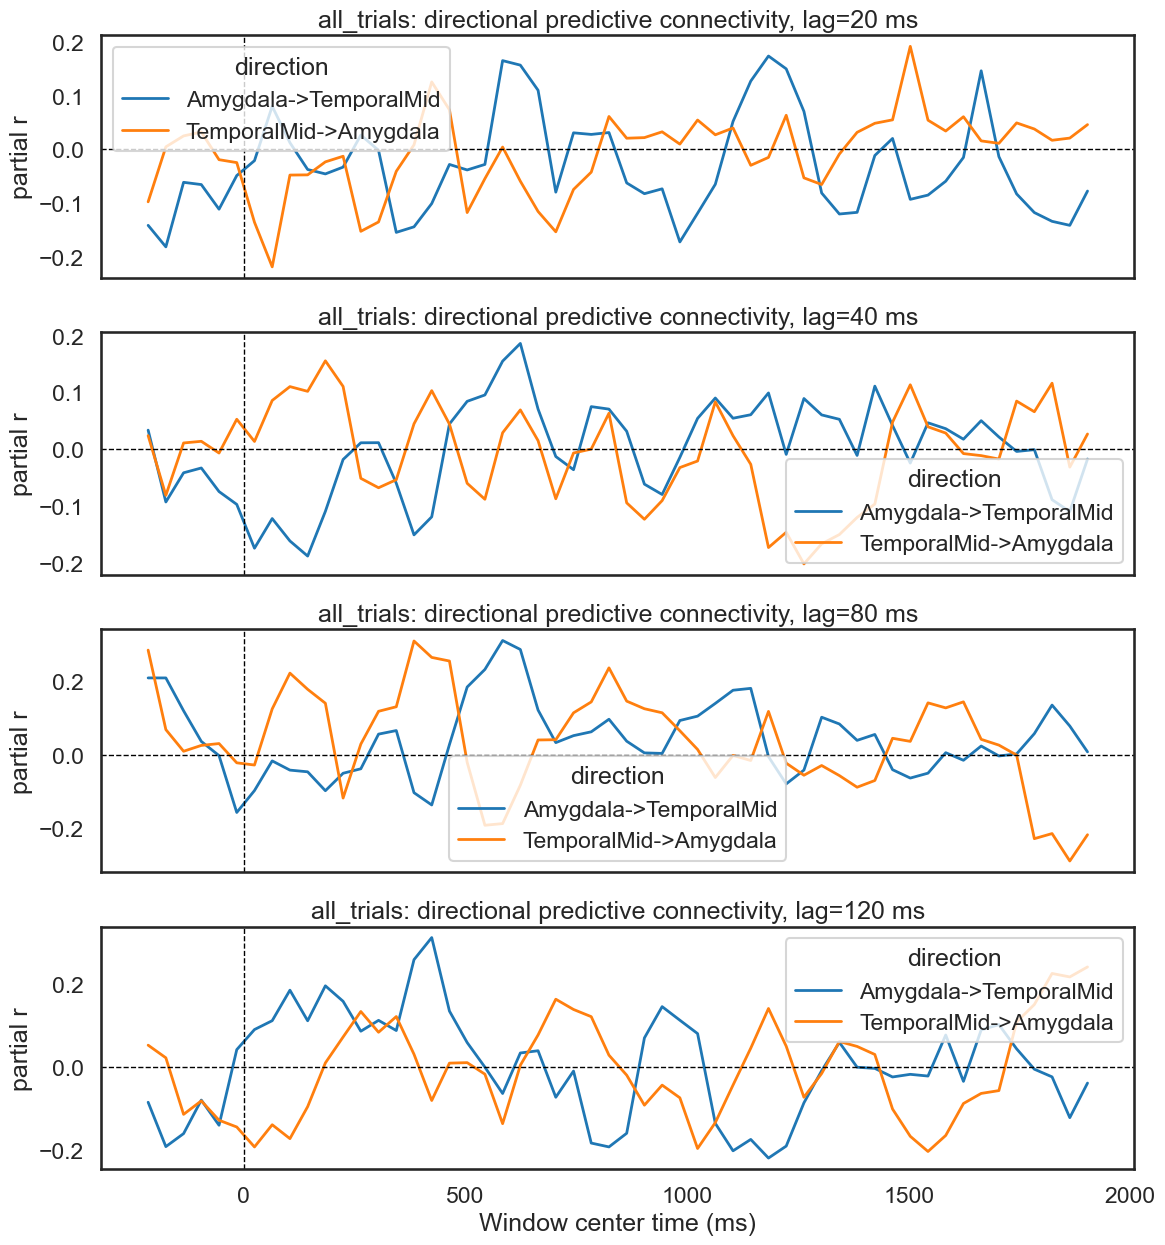

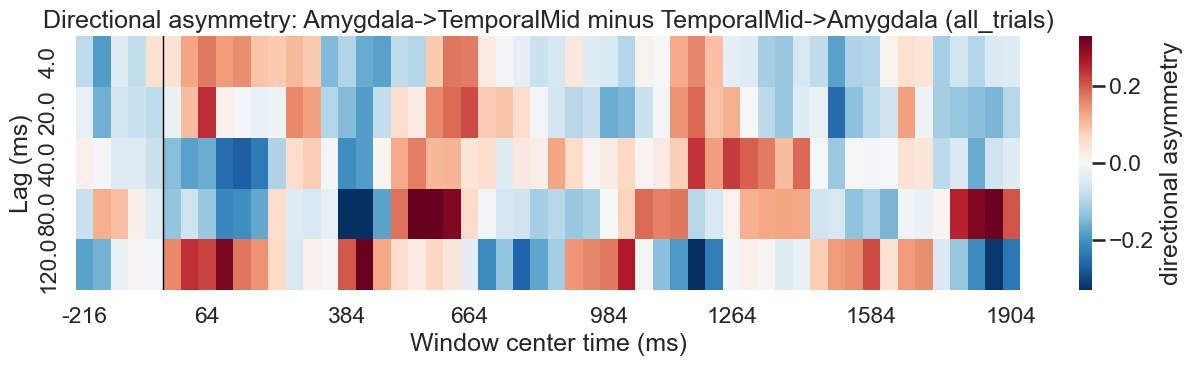

In [74]:
def plot_directional_pair_summary(summary_df, source_roi, target_roi, dataset_name, lags_to_plot=None, out_path=None):
    if lags_to_plot is None:
        lags_to_plot = sorted(summary_df["lag_ms"].dropna().unique())
    directions_to_plot = [f"{source_roi}->{target_roi}", f"{target_roi}->{source_roi}"]
    df = summary_df[
        (summary_df["dataset"] == dataset_name)
        & (summary_df["direction"].isin(directions_to_plot))
        & (summary_df["lag_ms"].isin(lags_to_plot))
    ].copy()

    fig, axes = plt.subplots(len(lags_to_plot), 1, figsize=(12, max(4, 3.2 * len(lags_to_plot))), sharex=True)
    if len(lags_to_plot) == 1:
        axes = [axes]
    for ax, lag in zip(axes, lags_to_plot):
        sub = df[df["lag_ms"] == lag]
        sns.lineplot(data=sub, x="window_center_ms", y="mean_value", hue="direction", ax=ax, linewidth=2)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{dataset_name}: directional predictive connectivity, lag={lag:g} ms")
        ax.set_ylabel("partial r")
        ax.set_xlabel("Window center time (ms)")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, axes


def plot_directional_asymmetry(summary_df, source_roi, target_roi, dataset_name, out_path=None):
    direction_name = f"{source_roi}->{target_roi} minus {target_roi}->{source_roi}"
    df = summary_df[(summary_df["dataset"] == dataset_name) & (summary_df["direction"] == direction_name)].copy()
    pivot = df.pivot(index="lag_ms", columns="window_center_ms", values="mean_value").sort_index()

    fig, ax = plt.subplots(figsize=(13, max(4, 0.5 * len(pivot))))
    vmax = np.nanpercentile(np.abs(pivot.to_numpy()), 98)
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={"label": "directional asymmetry"},
    )
    centers = pivot.columns.to_numpy(dtype=float)
    zero_idx = int(np.argmin(np.abs(centers)))
    ax.axvline(zero_idx, color="black", linewidth=1)
    ax.set_title(f"Directional asymmetry: {direction_name} ({dataset_name})")
    ax.set_xlabel("Window center time (ms)")
    ax.set_ylabel("Lag (ms)")
    tick_positions = np.linspace(0, len(centers) - 1, min(8, len(centers))).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([str(int(centers[i])) for i in tick_positions], rotation=0)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


fig, axes = plot_directional_pair_summary(
    directional_summary,
    DIRECTION_SOURCE_ROI,
    DIRECTION_TARGET_ROI,
    DIRECTION_DATASET,
    lags_to_plot=[20, 40, 80, 120],
    out_path=FIG_DIR / f"directional_curves_{DIRECTION_DATASET}_{DIRECTION_SOURCE_ROI}_{DIRECTION_TARGET_ROI}.png",
)
plt.show()

fig, ax = plot_directional_asymmetry(
    directional_summary,
    DIRECTION_SOURCE_ROI,
    DIRECTION_TARGET_ROI,
    DIRECTION_DATASET,
    out_path=FIG_DIR / f"directional_asymmetry_{DIRECTION_DATASET}_{DIRECTION_SOURCE_ROI}_{DIRECTION_TARGET_ROI}.png",
)
plt.show()


### Optional Interactive Directional Explorer

If `ipywidgets` is enabled in your notebook environment, this cell lets you choose dataset, source ROI, target ROI, lags, and window size, then computes and plots both directions plus their asymmetry.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display, clear_output
    _HAS_DIRECTION_WIDGETS = True
except Exception as exc:
    print("ipywidgets is not available; use the variable-based cells above instead.")
    _HAS_DIRECTION_WIDGETS = False

if _HAS_DIRECTION_WIDGETS:
    directional_datasets = build_directional_fusion_datasets()
    dataset_dropdown = widgets.Dropdown(options=list(directional_datasets.keys()), value=DIRECTION_DATASET, description="Dataset:")
    source_dropdown = widgets.Dropdown(options=roi_names, value=DIRECTION_SOURCE_ROI, description="Source:")
    target_dropdown = widgets.Dropdown(options=roi_names, value=DIRECTION_TARGET_ROI, description="Target:")
    lags_text = widgets.Text(value="4,20,40,80,120", description="Lags ms:", layout=widgets.Layout(width="300px"))
    window_int = widgets.IntText(value=160, description="Window ms:")
    step_int = widgets.IntText(value=40, description="Step ms:")
    run_button = widgets.Button(description="Run directional analysis", button_style="primary")
    dir_output = widgets.Output()

    def _run_directional_widget(_):
        with dir_output:
            clear_output(wait=True)
            src = source_dropdown.value
            tgt = target_dropdown.value
            if src == tgt:
                print("Choose two different ROIs.")
                return
            lags = [float(x.strip()) for x in lags_text.value.split(",") if x.strip()]
            dataset_name = dataset_dropdown.value
            print(f"Computing {src} -> {tgt} and {tgt} -> {src} for {dataset_name}...")
            result = compute_directional_pair(
                directional_datasets[dataset_name],
                src,
                tgt,
                roi_names,
                times_ms,
                lags_ms=lags,
                window_ms=int(window_int.value),
                step_ms=int(step_int.value),
            )
            long_df = directional_result_to_long(result, dataset_name)
            summary_df = group_directional_summary(long_df)
            plot_lags = sorted(summary_df["lag_ms"].dropna().unique())[:4]
            plot_directional_pair_summary(summary_df, src, tgt, dataset_name, lags_to_plot=plot_lags)
            plt.show()
            plot_directional_asymmetry(summary_df, src, tgt, dataset_name)
            plt.show()
            display(summary_df.head())

    run_button.on_click(_run_directional_widget)
    ipy_display(widgets.VBox([
        widgets.HBox([dataset_dropdown, source_dropdown, target_dropdown]),
        widgets.HBox([lags_text, window_int, step_int, run_button]),
        dir_output,
    ]))


## Step 16: Temporal Dependency Analysis for Hypothesized ROI Pathways

This step implements the two-stage approach for temporal dependency among selected ROI pathways, such as:

- `TemporalMid -> Fusiform`
- `Fusiform -> Insula`
- `Amygdala -> TemporalMid`

Stage 1 is exploratory **lead-lag correlation**:

`corr(source(t-lag), target(t))`

Stage 2 is confirmatory **lagged predictive dependency**:

`target(t) ~ target(t-lag) + source(t-lag) [+ global_fusion(t-lag)]`

The global-control option helps reduce the risk that all ROI signals are being driven by a shared EEG-fusion component. The output is still best described as directed predictive representational dependency, not anatomical causality.

In [ ]:
def build_temporal_dependency_datasets():
    """Return datasets as name -> subjects x rois x time fused ROI timecourses."""
    datasets = {cond: fusion_bc[:, ci, :, :] for ci, cond in enumerate(condition_names)}
    if "fusion_all_bc" in globals():
        datasets[ALL_TRIALS_NAME] = fusion_all_bc
    return datasets


def _corr_1d(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 4:
        return np.nan
    x = x[mask]
    y = y[mask]
    if np.nanstd(x) < 1e-8 or np.nanstd(y) < 1e-8:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def lead_lag_corr(source_ts, target_ts, lag_samples, target_indices, min_samples=8):
    """corr(source(t-lag), target(t)) within a target-time window."""
    target_indices = np.asarray(target_indices, dtype=int)
    valid_t = target_indices[target_indices - lag_samples >= 0]
    if len(valid_t) < min_samples:
        return np.nan
    return _corr_1d(source_ts[valid_t - lag_samples], target_ts[valid_t])


def _partial_corr_with_controls(y, x, controls, min_samples=8):
    y = np.asarray(y, dtype=np.float32)
    x = np.asarray(x, dtype=np.float32)
    controls = np.asarray(controls, dtype=np.float32)
    if controls.ndim == 1:
        controls = controls[:, None]
    mask = np.isfinite(y) & np.isfinite(x) & np.isfinite(controls).all(axis=1)
    if mask.sum() < min_samples:
        return np.nan
    y = y[mask]
    x = x[mask]
    controls = controls[mask]
    if np.nanstd(y) < 1e-8 or np.nanstd(x) < 1e-8:
        return np.nan
    X = np.column_stack([np.ones(len(y), dtype=np.float32), controls])
    beta_y, *_ = np.linalg.lstsq(X, y, rcond=None)
    beta_x, *_ = np.linalg.lstsq(X, x, rcond=None)
    y_resid = y - X @ beta_y
    x_resid = x - X @ beta_x
    return _corr_1d(x_resid, y_resid)


def lagged_predictive_dependency(source_ts, target_ts, lag_samples, target_indices, global_ts=None, control_global=True, min_samples=8):
    """Partial corr source(t-lag) with target(t), controlling target(t-lag) and optionally global(t-lag)."""
    target_indices = np.asarray(target_indices, dtype=int)
    valid_t = target_indices[target_indices - lag_samples >= 0]
    if len(valid_t) < min_samples:
        return np.nan
    y = target_ts[valid_t]
    x = source_ts[valid_t - lag_samples]
    controls = [target_ts[valid_t - lag_samples]]
    if control_global and global_ts is not None:
        controls.append(global_ts[valid_t - lag_samples])
    controls = np.column_stack(controls)
    return _partial_corr_with_controls(y, x, controls, min_samples=min_samples)


def compute_temporal_dependency_pair(dataset, source_roi, target_roi, roi_names, times_ms, lags_ms=(4, 20, 40, 80, 120), window_ms=160, step_ms=40, method="lead_lag", control_global=True):
    """Compute forward/reverse temporal dependency for one ROI pair.

    method='lead_lag' uses corr(source(t-lag), target(t)).
    method='predictive' uses partial corr controlling target(t-lag) and optional global(t-lag).
    """
    if source_roi == target_roi:
        raise ValueError("Choose two different ROIs.")
    source_idx = list(roi_names).index(source_roi)
    target_idx = list(roi_names).index(target_roi)
    sample_ms = float(np.nanmedian(np.diff(times_ms)))
    lag_samples = np.array([max(1, int(round(lag / sample_ms))) for lag in lags_ms], dtype=int)
    lag_ms_actual = lag_samples * sample_ms
    centers_ms, windows = make_lagged_windows(times_ms, window_ms=window_ms, step_ms=step_ms)

    n_subjects = dataset.shape[0]
    forward = np.full((n_subjects, len(windows), len(lag_samples)), np.nan, dtype=np.float32)
    reverse = np.full_like(forward, np.nan)
    global_signal = np.nanmean(dataset, axis=1) if control_global else None  # subjects x time

    for subj in range(n_subjects):
        src = np.asarray(dataset[subj, source_idx], dtype=np.float32)
        tgt = np.asarray(dataset[subj, target_idx], dtype=np.float32)
        glob = None if global_signal is None else np.asarray(global_signal[subj], dtype=np.float32)
        for wi, target_indices in enumerate(windows):
            for li, lag_samp in enumerate(lag_samples):
                if method == "lead_lag":
                    forward[subj, wi, li] = lead_lag_corr(src, tgt, lag_samp, target_indices)
                    reverse[subj, wi, li] = lead_lag_corr(tgt, src, lag_samp, target_indices)
                elif method == "predictive":
                    forward[subj, wi, li] = lagged_predictive_dependency(src, tgt, lag_samp, target_indices, global_ts=glob, control_global=control_global)
                    reverse[subj, wi, li] = lagged_predictive_dependency(tgt, src, lag_samp, target_indices, global_ts=glob, control_global=control_global)
                else:
                    raise ValueError("method must be 'lead_lag' or 'predictive'")

    return {
        "source_roi": source_roi,
        "target_roi": target_roi,
        "method": method,
        "control_global": control_global,
        "forward": forward,
        "reverse": reverse,
        "asymmetry": forward - reverse,
        "centers_ms": centers_ms,
        "lags_ms": lag_ms_actual.astype(np.float32),
        "window_ms": window_ms,
        "step_ms": step_ms,
    }


def temporal_dependency_result_to_long(result, dataset_name):
    rows = []
    src = result["source_roi"]
    tgt = result["target_roi"]
    method = result["method"]
    control_global = result["control_global"]
    directions = [
        (f"{src}->{tgt}", result["forward"]),
        (f"{tgt}->{src}", result["reverse"]),
        (f"{src}->{tgt} minus {tgt}->{src}", result["asymmetry"]),
    ]
    for direction, arr in directions:
        for subj in range(arr.shape[0]):
            for wi, center_ms in enumerate(result["centers_ms"]):
                for li, lag_ms in enumerate(result["lags_ms"]):
                    rows.append({
                        "dataset": dataset_name,
                        "method": method,
                        "control_global": control_global,
                        "subject": subj + 1,
                        "source_roi": src,
                        "target_roi": tgt,
                        "direction": direction,
                        "window_center_ms": float(center_ms),
                        "lag_ms": float(lag_ms),
                        "value": float(arr[subj, wi, li]) if np.isfinite(arr[subj, wi, li]) else np.nan,
                    })
    return pd.DataFrame(rows)


def summarize_temporal_dependency(long_df):
    rows = []
    group_cols = ["dataset", "method", "control_global", "source_roi", "target_roi", "direction", "window_center_ms", "lag_ms"]
    for keys, subdf in long_df.groupby(group_cols, dropna=False):
        vals = subdf["value"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            mean_value = np.nan
            sem_value = np.nan
        else:
            if "minus" in keys[5]:
                mean_value = float(np.nanmean(vals))
            else:
                mean_value = float(fisher_r(np.nanmean(fisher_z(vals))))
            sem_value = float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan
        rows.append(dict(zip(group_cols, keys), mean_value=mean_value, sem_value=sem_value, n=len(vals)))
    return pd.DataFrame(rows)


In [ ]:
TEMPORAL_DEPENDENCY_DATASET = ALL_TRIALS_NAME if "fusion_all_bc" in globals() else condition_names[0]
TEMPORAL_DEPENDENCY_PAIRS = [
    ("TemporalMid", "Fusiform"),
    ("Fusiform", "Insula"),
    ("Amygdala", "TemporalMid"),
    ("Amygdala", "Fusiform"),
    ("Fusiform", "Amygdala"),
]
TEMPORAL_DEPENDENCY_LAGS_MS = [4, 20, 40, 80, 120, 160]
TEMPORAL_DEPENDENCY_WINDOW_MS = 160
TEMPORAL_DEPENDENCY_STEP_MS = 40
TEMPORAL_DEPENDENCY_CONTROL_GLOBAL = True

temporal_dependency_datasets = build_temporal_dependency_datasets()
temporal_dependency_pairs = [pair for pair in TEMPORAL_DEPENDENCY_PAIRS if pair[0] in roi_names and pair[1] in roi_names and pair[0] != pair[1]]
print("Dataset:", TEMPORAL_DEPENDENCY_DATASET)
print("Pairs to run:", temporal_dependency_pairs)

all_dependency_long = []
for method in ["lead_lag", "predictive"]:
    for src, tgt in temporal_dependency_pairs:
        print(f"Running {method}: {src} -> {tgt}")
        result = compute_temporal_dependency_pair(
            temporal_dependency_datasets[TEMPORAL_DEPENDENCY_DATASET],
            src,
            tgt,
            roi_names,
            times_ms,
            lags_ms=TEMPORAL_DEPENDENCY_LAGS_MS,
            window_ms=TEMPORAL_DEPENDENCY_WINDOW_MS,
            step_ms=TEMPORAL_DEPENDENCY_STEP_MS,
            method=method,
            control_global=TEMPORAL_DEPENDENCY_CONTROL_GLOBAL,
        )
        all_dependency_long.append(temporal_dependency_result_to_long(result, TEMPORAL_DEPENDENCY_DATASET))

temporal_dependency_long = pd.concat(all_dependency_long, ignore_index=True) if all_dependency_long else pd.DataFrame()
temporal_dependency_summary = summarize_temporal_dependency(temporal_dependency_long) if len(temporal_dependency_long) else pd.DataFrame()

out_long = TABLE_DIR / f"temporal_dependency_{TEMPORAL_DEPENDENCY_DATASET}_subject_level.csv"
out_summary = TABLE_DIR / f"temporal_dependency_{TEMPORAL_DEPENDENCY_DATASET}_summary.csv"
temporal_dependency_long.to_csv(out_long, index=False)
temporal_dependency_summary.to_csv(out_summary, index=False)
print("Saved:", out_long)
print("Saved:", out_summary)
display(temporal_dependency_summary.head())


In [ ]:
def plot_temporal_dependency_asymmetry_grid(summary_df, dataset_name, method, source_roi, target_roi, out_path=None):
    direction_name = f"{source_roi}->{target_roi} minus {target_roi}->{source_roi}"
    df = summary_df[
        (summary_df["dataset"] == dataset_name)
        & (summary_df["method"] == method)
        & (summary_df["source_roi"] == source_roi)
        & (summary_df["target_roi"] == target_roi)
        & (summary_df["direction"] == direction_name)
    ].copy()
    if df.empty:
        print(f"No data for {method}: {direction_name}")
        return None, None
    pivot = df.pivot(index="lag_ms", columns="window_center_ms", values="mean_value").sort_index()
    fig, ax = plt.subplots(figsize=(13, max(4, 0.45 * len(pivot))))
    vmax = np.nanpercentile(np.abs(pivot.to_numpy()), 98)
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={"label": f"{method} asymmetry"},
    )
    centers = pivot.columns.to_numpy(dtype=float)
    zero_idx = int(np.argmin(np.abs(centers)))
    ax.axvline(zero_idx, color="black", linewidth=1)
    ax.set_title(f"{method}: {direction_name} ({dataset_name})")
    ax.set_xlabel("Window center time (ms)")
    ax.set_ylabel("Lag (ms)")
    tick_positions = np.linspace(0, len(centers) - 1, min(8, len(centers))).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([str(int(centers[i])) for i in tick_positions], rotation=0)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


def plot_temporal_dependency_curves(summary_df, dataset_name, method, source_roi, target_roi, lag_ms=40, out_path=None):
    directions = [f"{source_roi}->{target_roi}", f"{target_roi}->{source_roi}"]
    df = summary_df[
        (summary_df["dataset"] == dataset_name)
        & (summary_df["method"] == method)
        & (summary_df["source_roi"] == source_roi)
        & (summary_df["target_roi"] == target_roi)
        & (summary_df["direction"].isin(directions))
        & (summary_df["lag_ms"] == float(lag_ms))
    ].copy()
    if df.empty:
        print(f"No curve data for {method}: {source_roi}<->{target_roi}, lag {lag_ms}")
        return None, None
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=df, x="window_center_ms", y="mean_value", hue="direction", ax=ax, linewidth=2)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{method}: {source_roi}<->{target_roi}, lag={lag_ms:g} ms ({dataset_name})")
    ax.set_xlabel("Window center time (ms)")
    ax.set_ylabel("dependency value")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


if len(temporal_dependency_summary):
    for src, tgt in temporal_dependency_pairs:
        for method in ["lead_lag", "predictive"]:
            fig, ax = plot_temporal_dependency_asymmetry_grid(
                temporal_dependency_summary,
                TEMPORAL_DEPENDENCY_DATASET,
                method,
                src,
                tgt,
                out_path=FIG_DIR / f"temporal_dependency_asymmetry_{TEMPORAL_DEPENDENCY_DATASET}_{method}_{src}_{tgt}.png",
            )
            if fig is not None:
                plt.show()
            fig, ax = plot_temporal_dependency_curves(
                temporal_dependency_summary,
                TEMPORAL_DEPENDENCY_DATASET,
                method,
                src,
                tgt,
                lag_ms=40,
                out_path=FIG_DIR / f"temporal_dependency_curves_{TEMPORAL_DEPENDENCY_DATASET}_{method}_{src}_{tgt}_lag40.png",
            )
            if fig is not None:
                plt.show()


## Step 17: Dynamic Directed Representational Cascade Network

This step tests the idea of a temporally ordered directed network, for example:

`TemporalMid -> Fusiform -> Insula`

with possible feedback:

`Amygdala <-> TemporalMid`

Instead of testing only one ROI pair at a time, this builds a directed adjacency tensor over selected ROIs:

`subjects x lags x windows x source_roi x target_roi`

Each directed edge is a lagged predictive dependency:

`target(t) ~ target(t-lag) + source(t-lag) [+ global_fusion(t-lag)]`

Then the code derives:

- dynamic directed edge heatmaps
- source strength, receiver strength, and net flow for each ROI
- chain/motif scores such as `A -> B -> C`
- feedback scores such as `A <-> B`

This is the closest notebook implementation of a **dynamic directed representational network / temporal cascade**.

In [ ]:
# -----------------------------
# Dynamic directed cascade config
# -----------------------------
CASCADE_DATASET = ALL_TRIALS_NAME if "fusion_all_bc" in globals() else condition_names[0]

# Keep this False for hypothesis-driven analysis. Set True only if you want all 65 x 64 directed edges.
RUN_FULL_AAL3_DIRECTED_NETWORK = False

CASCADE_ROI_CANDIDATES = [
    "TemporalMid", "Fusiform", "Insula", "Amygdala", "TemporalInf", "TemporalSup",
    "OFCmed", "OFCant", "OFCpost", "ACCpre", "ACCsub", "ACCsup",
    "Hippocampus", "ParaHippocampal", "Calcarine", "Lingual",
]
CASCADE_ROIS = list(roi_names) if RUN_FULL_AAL3_DIRECTED_NETWORK else [r for r in CASCADE_ROI_CANDIDATES if r in roi_names]

CASCADE_LAGS_MS = [20, 40, 80, 120]
CASCADE_WINDOW_MS = 160
CASCADE_STEP_MS = 40
CASCADE_CONTROL_GLOBAL = True

# User-defined motifs to test. Missing ROIs are skipped automatically.
CASCADE_CHAINS = [
    ("TemporalMid", "Fusiform", "Insula"),
    ("Amygdala", "TemporalMid", "Fusiform"),
    ("Fusiform", "Insula", "ACCpre"),
    ("Calcarine", "Fusiform", "Amygdala"),
]
CASCADE_FEEDBACK_PAIRS = [
    ("Amygdala", "TemporalMid"),
    ("TemporalMid", "Fusiform"),
    ("Fusiform", "Insula"),
    ("Amygdala", "Fusiform"),
]

print("Dataset:", CASCADE_DATASET)
print("ROIs:", CASCADE_ROIS)
print("n directed edges:", len(CASCADE_ROIS) * (len(CASCADE_ROIS) - 1))
print("Lags:", CASCADE_LAGS_MS)


In [ ]:
def compute_directed_adjacency_network(dataset, roi_names, selected_rois, times_ms, lags_ms=(20, 40, 80), window_ms=160, step_ms=40, control_global=True):
    """Compute directed predictive adjacency for selected ROIs.

    Returns
    -------
    result : dict
        adj shape = subjects x lags x windows x source x target.
        Diagonal is NaN.
    """
    selected_rois = list(selected_rois)
    selected_idx = [list(roi_names).index(r) for r in selected_rois]
    data = np.asarray(dataset[:, selected_idx, :], dtype=np.float32)  # subjects x selected_rois x time
    n_subjects, n_rois, _ = data.shape

    sample_ms = float(np.nanmedian(np.diff(times_ms)))
    lag_samples = np.array([max(1, int(round(lag / sample_ms))) for lag in lags_ms], dtype=int)
    lag_ms_actual = lag_samples * sample_ms
    centers_ms, windows = make_lagged_windows(times_ms, window_ms=window_ms, step_ms=step_ms)

    adj = np.full((n_subjects, len(lag_samples), len(windows), n_rois, n_rois), np.nan, dtype=np.float32)
    global_signal = np.nanmean(data, axis=1) if control_global else None

    for subj in range(n_subjects):
        glob = None if global_signal is None else global_signal[subj]
        for li, lag_samp in enumerate(lag_samples):
            for wi, target_indices in enumerate(windows):
                for si in range(n_rois):
                    src = data[subj, si]
                    for ti in range(n_rois):
                        if si == ti:
                            continue
                        tgt = data[subj, ti]
                        adj[subj, li, wi, si, ti] = lagged_predictive_dependency(
                            src,
                            tgt,
                            lag_samp,
                            target_indices,
                            global_ts=glob,
                            control_global=control_global,
                        )

    return {
        "adj": adj,
        "selected_rois": selected_rois,
        "centers_ms": centers_ms,
        "lags_ms": lag_ms_actual.astype(np.float32),
        "window_ms": window_ms,
        "step_ms": step_ms,
        "control_global": control_global,
    }


def group_mean_directed_adjacency(adj):
    """Fisher-z group mean over subjects for directed adjacency."""
    return fisher_r(np.nanmean(fisher_z(adj), axis=0)).astype(np.float32)  # lags x windows x source x target


def directed_network_to_long(group_adj, selected_rois, centers_ms, lags_ms, dataset_name):
    rows = []
    n_lags, n_windows, n_rois, _ = group_adj.shape
    for li, lag in enumerate(lags_ms):
        for wi, center in enumerate(centers_ms):
            for si, src in enumerate(selected_rois):
                for ti, tgt in enumerate(selected_rois):
                    if si == ti:
                        continue
                    rows.append({
                        "dataset": dataset_name,
                        "lag_ms": float(lag),
                        "window_center_ms": float(center),
                        "source_roi": src,
                        "target_roi": tgt,
                        "edge": f"{src}->{tgt}",
                        "value": float(group_adj[li, wi, si, ti]),
                    })
    return pd.DataFrame(rows)


def compute_node_flow(group_adj, selected_rois, centers_ms, lags_ms, positive_only=False):
    """Compute outgoing, incoming, and net flow per ROI from group adjacency."""
    arr = group_adj.copy()
    if positive_only:
        arr = np.where(arr > 0, arr, np.nan)
    outgoing = np.nanmean(arr, axis=-1)  # lags x windows x source
    incoming = np.nanmean(arr, axis=-2)  # lags x windows x target
    net = outgoing - incoming
    rows = []
    for li, lag in enumerate(lags_ms):
        for wi, center in enumerate(centers_ms):
            for ri, roi in enumerate(selected_rois):
                rows.append({
                    "lag_ms": float(lag),
                    "window_center_ms": float(center),
                    "roi": roi,
                    "outgoing": float(outgoing[li, wi, ri]),
                    "incoming": float(incoming[li, wi, ri]),
                    "net_flow": float(net[li, wi, ri]),
                })
    return pd.DataFrame(rows)


In [ ]:
cascade_datasets = build_temporal_dependency_datasets()
if len(CASCADE_ROIS) < 2:
    raise ValueError("Need at least two available ROIs for cascade analysis.")

cascade_result = compute_directed_adjacency_network(
    cascade_datasets[CASCADE_DATASET],
    roi_names,
    CASCADE_ROIS,
    times_ms,
    lags_ms=CASCADE_LAGS_MS,
    window_ms=CASCADE_WINDOW_MS,
    step_ms=CASCADE_STEP_MS,
    control_global=CASCADE_CONTROL_GLOBAL,
)

cascade_adj = cascade_result["adj"]
cascade_group_adj = group_mean_directed_adjacency(cascade_adj)
cascade_selected_rois = cascade_result["selected_rois"]
cascade_centers_ms = cascade_result["centers_ms"]
cascade_lags_ms = cascade_result["lags_ms"]

CASCADE_CACHE = OUT_DIR / f"directed_cascade_network_{CASCADE_DATASET}.npz"
np.savez_compressed(
    CASCADE_CACHE,
    adj=cascade_adj,
    group_adj=cascade_group_adj,
    selected_rois=np.array(cascade_selected_rois),
    centers_ms=cascade_centers_ms,
    lags_ms=cascade_lags_ms,
    dataset=np.array(CASCADE_DATASET),
    control_global=np.array(CASCADE_CONTROL_GLOBAL),
)
print("Saved:", CASCADE_CACHE)
print("Subject adjacency:", cascade_adj.shape)
print("Group adjacency:", cascade_group_adj.shape)

cascade_edge_long = directed_network_to_long(cascade_group_adj, cascade_selected_rois, cascade_centers_ms, cascade_lags_ms, CASCADE_DATASET)
cascade_node_flow = compute_node_flow(cascade_group_adj, cascade_selected_rois, cascade_centers_ms, cascade_lags_ms, positive_only=False)
cascade_edge_long.to_csv(TABLE_DIR / f"directed_cascade_edges_{CASCADE_DATASET}.csv", index=False)
cascade_node_flow.to_csv(TABLE_DIR / f"directed_cascade_node_flow_{CASCADE_DATASET}.csv", index=False)
display(cascade_edge_long.sort_values("value", ascending=False).head(20))


In [ ]:
def plot_directed_edge_heatmap(edge_long, lag_ms, dataset_name, top_n=80, out_path=None):
    df = edge_long[edge_long["lag_ms"] == float(lag_ms)].copy()
    if df.empty:
        print("No edge data for lag", lag_ms)
        return None, None
    peak_order = df.groupby("edge")["value"].apply(lambda x: np.nanmax(np.abs(x))).sort_values(ascending=False)
    keep_edges = peak_order.head(top_n).index.tolist()
    df = df[df["edge"].isin(keep_edges)]
    pivot = df.pivot(index="edge", columns="window_center_ms", values="value").loc[keep_edges]

    fig, ax = plt.subplots(figsize=(14, max(8, 0.18 * len(keep_edges))))
    vmax = np.nanpercentile(np.abs(pivot.to_numpy()), 98)
    sns.heatmap(pivot, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax, cbar_kws={"label": "directed predictive edge"})
    centers = pivot.columns.to_numpy(dtype=float)
    zero_idx = int(np.argmin(np.abs(centers)))
    ax.axvline(zero_idx, color="black", linewidth=1)
    tick_positions = np.linspace(0, len(centers) - 1, min(8, len(centers))).astype(int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels([str(int(centers[i])) for i in tick_positions], rotation=0)
    ax.set_title(f"Dynamic directed edges, lag={lag_ms:g} ms ({dataset_name})")
    ax.set_xlabel("Window center time (ms)")
    ax.set_ylabel("Directed edge")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax


def plot_node_flow(node_flow_df, lag_ms, out_path=None):
    df = node_flow_df[node_flow_df["lag_ms"] == float(lag_ms)].copy()
    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
    for ax, measure in zip(axes, ["outgoing", "incoming", "net_flow"]):
        sns.lineplot(data=df, x="window_center_ms", y=measure, hue="roi", ax=ax, linewidth=1.8)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_ylabel(measure)
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    axes[-1].set_xlabel("Window center time (ms)")
    axes[0].set_title(f"Directed network source/receiver dynamics, lag={lag_ms:g} ms")
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, axes

PLOT_CASCADE_LAG_MS = 40 if 40 in set(cascade_lags_ms) else float(cascade_lags_ms[0])
fig, ax = plot_directed_edge_heatmap(
    cascade_edge_long,
    PLOT_CASCADE_LAG_MS,
    CASCADE_DATASET,
    top_n=min(100, len(CASCADE_ROIS) * (len(CASCADE_ROIS) - 1)),
    out_path=FIG_DIR / f"directed_cascade_edge_heatmap_{CASCADE_DATASET}_lag{int(PLOT_CASCADE_LAG_MS)}.png",
)
if fig is not None:
    plt.show()
fig, axes = plot_node_flow(
    cascade_node_flow,
    PLOT_CASCADE_LAG_MS,
    out_path=FIG_DIR / f"directed_cascade_node_flow_{CASCADE_DATASET}_lag{int(PLOT_CASCADE_LAG_MS)}.png",
)
plt.show()


In [ ]:
def compute_chain_motifs(group_adj, selected_rois, chains, centers_ms, lags_ms, step_shift=1):
    """Compute chain scores A->B->C.

    The first edge A->B is measured at window w. The second edge B->C is measured at window w+step_shift.
    step_shift=0 tests same-window chains; step_shift=1 tests temporal cascade continuation.
    Score uses sign-preserving product: edge1 * edge2.
    """
    rows = []
    roi_to_idx = {r: i for i, r in enumerate(selected_rois)}
    for chain in chains:
        if any(r not in roi_to_idx for r in chain):
            continue
        a, b, c = chain
        ia, ib, ic = roi_to_idx[a], roi_to_idx[b], roi_to_idx[c]
        for li, lag in enumerate(lags_ms):
            for wi in range(len(centers_ms) - step_shift):
                e1 = group_adj[li, wi, ia, ib]
                e2 = group_adj[li, wi + step_shift, ib, ic]
                rows.append({
                    "motif": f"{a}->{b}->{c}",
                    "lag_ms": float(lag),
                    "window_center_ms": float(centers_ms[wi]),
                    "next_window_center_ms": float(centers_ms[wi + step_shift]),
                    "edge_1": float(e1),
                    "edge_2": float(e2),
                    "chain_score": float(e1 * e2),
                    "chain_min": float(np.nanmin([e1, e2])),
                })
    return pd.DataFrame(rows)


def compute_feedback_motifs(group_adj, selected_rois, pairs, centers_ms, lags_ms, step_shift=1):
    """Compute feedback scores A->B followed by B->A."""
    rows = []
    roi_to_idx = {r: i for i, r in enumerate(selected_rois)}
    for a, b in pairs:
        if a not in roi_to_idx or b not in roi_to_idx:
            continue
        ia, ib = roi_to_idx[a], roi_to_idx[b]
        for li, lag in enumerate(lags_ms):
            for wi in range(len(centers_ms) - step_shift):
                e_ab = group_adj[li, wi, ia, ib]
                e_ba = group_adj[li, wi + step_shift, ib, ia]
                rows.append({
                    "motif": f"{a}<->{b}",
                    "lag_ms": float(lag),
                    "window_center_ms": float(centers_ms[wi]),
                    "next_window_center_ms": float(centers_ms[wi + step_shift]),
                    "forward_edge": float(e_ab),
                    "feedback_edge": float(e_ba),
                    "feedback_score": float(e_ab * e_ba),
                    "asymmetry": float(e_ab - e_ba),
                })
    return pd.DataFrame(rows)


def plot_motif_lines(df, value_col, title, lag_ms=40, out_path=None):
    sub = df[df["lag_ms"] == float(lag_ms)].copy()
    if sub.empty:
        print("No motif data for lag", lag_ms)
        return None, None
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=sub, x="window_center_ms", y=value_col, hue="motif", ax=ax, linewidth=2)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}, lag={lag_ms:g} ms")
    ax.set_xlabel("Window center time (ms)")
    ax.set_ylabel(value_col)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    return fig, ax

cascade_chain_df = compute_chain_motifs(cascade_group_adj, cascade_selected_rois, CASCADE_CHAINS, cascade_centers_ms, cascade_lags_ms, step_shift=1)
cascade_feedback_df = compute_feedback_motifs(cascade_group_adj, cascade_selected_rois, CASCADE_FEEDBACK_PAIRS, cascade_centers_ms, cascade_lags_ms, step_shift=1)
cascade_chain_df.to_csv(TABLE_DIR / f"directed_cascade_chain_motifs_{CASCADE_DATASET}.csv", index=False)
cascade_feedback_df.to_csv(TABLE_DIR / f"directed_cascade_feedback_motifs_{CASCADE_DATASET}.csv", index=False)

display(cascade_chain_df.sort_values("chain_score", ascending=False).head(20) if len(cascade_chain_df) else cascade_chain_df)
display(cascade_feedback_df.sort_values("feedback_score", ascending=False).head(20) if len(cascade_feedback_df) else cascade_feedback_df)

fig, ax = plot_motif_lines(
    cascade_chain_df,
    "chain_score",
    "Directed cascade chain motifs",
    lag_ms=PLOT_CASCADE_LAG_MS,
    out_path=FIG_DIR / f"directed_cascade_chain_motifs_{CASCADE_DATASET}_lag{int(PLOT_CASCADE_LAG_MS)}.png",
)
if fig is not None:
    plt.show()
fig, ax = plot_motif_lines(
    cascade_feedback_df,
    "feedback_score",
    "Directed feedback motifs",
    lag_ms=PLOT_CASCADE_LAG_MS,
    out_path=FIG_DIR / f"directed_cascade_feedback_motifs_{CASCADE_DATASET}_lag{int(PLOT_CASCADE_LAG_MS)}.png",
)
if fig is not None:
    plt.show()


## Step 18: Top-25% Voxel-to-Voxel Dynamic ROI Connectivity and 3D State Space

This step uses the four Harvard-Oxford masks containing the peak top 25% of fusion voxels. For each subject and each sliding time window, every voxel's EEG-fMRI fusion trajectory is standardized within the window. Pearson correlations are calculated for every cross-ROI voxel pair and averaged to one subject-level ROI-pair value. Subject values are Fisher-z averaged and transformed back to `r`, producing six ROI-to-ROI correlation time courses.

The default 160 ms window and 20 ms step estimate local synchrony while retaining useful temporal resolution. This is **dynamic connectivity of the fused representational signal**, not conventional BOLD functional connectivity and not evidence of directionality or causal influence.

Two 3D views are provided for EVC plus any two other ROIs:

1. **Representational state space:** the three group-average ROI fusion responses are the axes.
2. **Connectivity state space:** the three pairwise dynamic correlations are the axes.

Because the top-25% masks were selected using the same group fusion data, inferential testing on these trajectories would be circular. Use independent ROI definitions, held-out subjects, or nested cross-validation for confirmatory statistics.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from top25_voxel_dynamic_connectivity import (
    OUTPUT_DIR as TOP25_CONNECTIVITY_OUT_DIR,
    compute_voxel_dynamic_connectivity,
    plot_three_roi_state_space,
)

# A 160 ms window spans 41 samples at the 4 ms EEG-fusion sampling interval.
VOXEL_CONNECTIVITY_WINDOW_MS = 160.0
VOXEL_CONNECTIVITY_STEP_MS = 20.0
VOXEL_CONNECTIVITY_FORCE_RECOMPUTE = False

top25_voxel_connectivity = compute_voxel_dynamic_connectivity(
    window_ms=VOXEL_CONNECTIVITY_WINDOW_MS,
    step_ms=VOXEL_CONNECTIVITY_STEP_MS,
    force=VOXEL_CONNECTIVITY_FORCE_RECOMPUTE,
)

top25_roi_table = pd.DataFrame({
    "mask_value": top25_voxel_connectivity["roi_labels"],
    "short_name": ["EVC", "Dorsal", "Ventral", "Lateral OTC"],
    "role": top25_voxel_connectivity["roi_names"],
    "Harvard-Oxford ROI": top25_voxel_connectivity["roi_atlas_names"],
    "selected_voxels_3mm": top25_voxel_connectivity["roi_voxel_counts"],
})
display(top25_roi_table)
print("Subject ROI trajectories:", top25_voxel_connectivity["subject_roi_time"].shape)
print("Subject edge trajectories:", top25_voxel_connectivity["subject_edge_time"].shape)
print("Saved outputs:", TOP25_CONNECTIVITY_OUT_DIR)


In [ ]:
# Label 1 must remain EVC. Choose any two distinct labels from 2, 3, and 4.
STATE_SPACE_ROI_LABELS = (1, 2, 3)  # EVC + dorsal + ventral
STATE_SPACE_GAUSSIAN_SIGMA_MS = 20.0  # 0 shows unsmoothed curves

state_space_name = "_".join(map(str, STATE_SPACE_ROI_LABELS))
fig = plot_three_roi_state_space(
    top25_voxel_connectivity,
    selected_labels=STATE_SPACE_ROI_LABELS,
    gaussian_sigma_ms=STATE_SPACE_GAUSSIAN_SIGMA_MS,
    output_path=TOP25_CONNECTIVITY_OUT_DIR / f"state_space_labels_{state_space_name}.png",
)
plt.show()


In [ ]:
# Interactive EVC + two-ROI state-space explorer.
try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display

    secondary_roi_options = [
        ("Dorsal visual stream", 2),
        ("Ventral visual stream", 3),
        ("Lateral occipitotemporal cortex", 4),
    ]
    roi_b_dropdown = widgets.Dropdown(
        options=secondary_roi_options, value=2, description="ROI 2:"
    )
    roi_c_dropdown = widgets.Dropdown(
        options=secondary_roi_options, value=3, description="ROI 3:"
    )
    smoothing_toggle = widgets.Checkbox(
        value=True, description="Gaussian smoothing"
    )
    smoothing_slider = widgets.FloatSlider(
        value=20.0, min=0.0, max=100.0, step=4.0,
        description="Sigma (ms):", continuous_update=False,
    )
    state_output = widgets.Output()

    def refresh_top25_state_space(*_):
        with state_output:
            clear_output(wait=True)
            if roi_b_dropdown.value == roi_c_dropdown.value:
                print("Choose two different non-EVC ROIs.")
                return
            sigma_ms = smoothing_slider.value if smoothing_toggle.value else 0.0
            interactive_fig = plot_three_roi_state_space(
                top25_voxel_connectivity,
                selected_labels=(1, roi_b_dropdown.value, roi_c_dropdown.value),
                gaussian_sigma_ms=sigma_ms,
            )
            display(interactive_fig)
            plt.close(interactive_fig)

    for control in (roi_b_dropdown, roi_c_dropdown, smoothing_toggle, smoothing_slider):
        control.observe(refresh_top25_state_space, names="value")
    display(
        widgets.HBox([roi_b_dropdown, roi_c_dropdown]),
        widgets.HBox([smoothing_toggle, smoothing_slider]),
        state_output,
    )
    refresh_top25_state_space()
except ImportError:
    print("ipywidgets is unavailable; use STATE_SPACE_ROI_LABELS in the preceding cell.")


## Step 19: Smooth the Four-ROI Fusion Curves

This plotting-only step applies Gaussian smoothing to the group four-ROI fusion curves. The raw curves remain faintly visible, so the smoothing does not replace the original data. Change `FOUR_ROI_GAUSSIAN_SIGMA_MS` to adjust the amount of smoothing; set it to `0` for raw curves.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FOUR_ROI_FUSION_CACHE = OUT_DIR / "kastner_aal3_4roi_all_trials_roi_fusion_timeseries.npz"
FOUR_ROI_GAUSSIAN_SIGMA_MS = 40.0  # 0 = raw; 20-40 ms is a moderate visual smoothing
FOUR_ROI_SHOW_RAW = True

def smooth_curve_gaussian(y, sigma_ms, times_ms):
    y = np.asarray(y, dtype=float)
    if sigma_ms is None or sigma_ms <= 0:
        return y.copy()
    dt = float(np.nanmedian(np.diff(times_ms)))
    sigma_samples = float(sigma_ms) / dt
    radius = max(1, int(4.0 * sigma_samples + 0.5))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")

z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
times_4roi = np.asarray(z["times_ms"], dtype=float)
roi_names_4roi = [str(x) for x in z["roi_names"]]
group_mean_4roi = np.asarray(z["group_mean"], dtype=float)
sem_4roi = np.asarray(z["sem"], dtype=float)

smoothed_4roi = np.vstack([
    smooth_curve_gaussian(y, FOUR_ROI_GAUSSIAN_SIGMA_MS, times_4roi)
    for y in group_mean_4roi
])
smoothed_sem_4roi = np.vstack([
    smooth_curve_gaussian(y, FOUR_ROI_GAUSSIAN_SIGMA_MS, times_4roi)
    for y in sem_4roi
])

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]
fig, ax = plt.subplots(figsize=(13, 6.8))
for ri, (roi, color) in enumerate(zip(roi_names_4roi, colors)):
    if FOUR_ROI_SHOW_RAW:
        ax.plot(times_4roi, group_mean_4roi[ri], color=color, alpha=0.18, linewidth=0.8)
    ax.fill_between(
        times_4roi,
        smoothed_4roi[ri] - smoothed_sem_4roi[ri],
        smoothed_4roi[ri] + smoothed_sem_4roi[ri],
        color=color, alpha=0.12, linewidth=0,
    )
    ax.plot(times_4roi, smoothed_4roi[ri], color=color, linewidth=2.4, label=roi)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
smooth_label = f"{FOUR_ROI_GAUSSIAN_SIGMA_MS:g} ms Gaussian smoothing" if FOUR_ROI_GAUSSIAN_SIGMA_MS > 0 else "raw"
ax.set_title(f"Four Visual-Stream ROIs: ROI-Pattern Fusion ({smooth_label})")
ax.set_xlabel("EEG-fusion time (ms)")
ax.set_ylabel("Baseline-corrected fusion r")
ax.legend(title="ROI")
ax.grid(alpha=0.18)
fig.tight_layout()
smooth_tag = int(FOUR_ROI_GAUSSIAN_SIGMA_MS) if FOUR_ROI_GAUSSIAN_SIGMA_MS > 0 else 0
smooth_fig_path = FIG_DIR / f"kastner_aal3_4roi_all_trials_roi_fusion_timecourses_gaussian_sigma{smooth_tag}ms.png"
fig.savefig(smooth_fig_path, dpi=220, bbox_inches="tight")

smooth_rows = []
for ri, roi in enumerate(roi_names_4roi):
    for ti, time_ms in enumerate(times_4roi):
        smooth_rows.append({
            "time_ms": float(time_ms),
            "roi": roi,
            "raw_group_mean_bc_fusion_r": float(group_mean_4roi[ri, ti]),
            "smoothed_group_mean_bc_fusion_r": float(smoothed_4roi[ri, ti]),
            "smoothed_sem": float(smoothed_sem_4roi[ri, ti]),
            "gaussian_sigma_ms": float(FOUR_ROI_GAUSSIAN_SIGMA_MS),
        })
smooth_table_path = TABLE_DIR / f"kastner_aal3_4roi_all_trials_fusion_timecourses_gaussian_sigma{smooth_tag}ms.csv"
pd.DataFrame(smooth_rows).to_csv(smooth_table_path, index=False)
print("Saved figure:", smooth_fig_path)
print("Saved table:", smooth_table_path)
plt.show()


## Step 20: Pairwise V1 State Spaces

This step plots the smoothed V1 fusion trajectory against each other selected ROI. Each point is one EEG-fusion time point, and color encodes time. The three panels show V1-IPS, V1-Fusiform, and V1-LO1/LO2 state spaces.

In [ ]:
# Pairwise state spaces using the smoothed curves from Step 19.
PAIRWISE_STATE_SPACE_SIGMA_MS = FOUR_ROI_GAUSSIAN_SIGMA_MS
PAIRWISE_STATE_SPACE_V1_NAME = "V1"

if "smoothed_4roi" not in globals():
    z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
    times_4roi = np.asarray(z["times_ms"], dtype=float)
    roi_names_4roi = [str(x) for x in z["roi_names"]]
    group_mean_4roi = np.asarray(z["group_mean"], dtype=float)
    sem_4roi = np.asarray(z["sem"], dtype=float)
    smoothed_4roi = np.vstack([
        smooth_curve_gaussian(y, PAIRWISE_STATE_SPACE_SIGMA_MS, times_4roi)
        for y in group_mean_4roi
    ])

v1_idx = roi_names_4roi.index(PAIRWISE_STATE_SPACE_V1_NAME)
other_roi_names = [r for r in roi_names_4roi if r != PAIRWISE_STATE_SPACE_V1_NAME]
time_colors = times_4roi
fig, axes = plt.subplots(1, len(other_roi_names), figsize=(18, 5.5), squeeze=False, constrained_layout=True)
axes = axes.ravel()
state_rows = []

for ax, target_roi in zip(axes, other_roi_names):
    target_idx = roi_names_4roi.index(target_roi)
    x = smoothed_4roi[v1_idx]
    y = smoothed_4roi[target_idx]
    ax.plot(x, y, color="0.55", alpha=0.55, linewidth=1.0, zorder=1)
    points = ax.scatter(x, y, c=time_colors, cmap="viridis", s=16, linewidths=0, zorder=2)
    ax.scatter(x[0], y[0], color="black", marker="o", s=45, label="start", zorder=3)
    zero_idx = int(np.argmin(np.abs(times_4roi)))
    ax.scatter(x[zero_idx], y[zero_idx], color="red", marker="x", s=55, label="0 ms", zorder=3)
    ax.scatter(x[-1], y[-1], color="black", marker="s", s=38, label="end", zorder=3)
    ax.axvline(0, color="0.75", linestyle=":", linewidth=0.8)
    ax.axhline(0, color="0.75", linestyle=":", linewidth=0.8)
    ax.set_title(f"V1 to {target_roi}")
    ax.set_xlabel("V1 smoothed fusion r")
    ax.set_ylabel(f"{target_roi} smoothed fusion r")
    ax.grid(alpha=0.2)
    for ti in range(len(times_4roi)):
        state_rows.append({
            "time_ms": float(times_4roi[ti]),
            "source_roi": "V1",
            "target_roi": target_roi,
            "v1_fusion_smoothed_r": float(x[ti]),
            "target_fusion_smoothed_r": float(y[ti]),
            "gaussian_sigma_ms": float(PAIRWISE_STATE_SPACE_SIGMA_MS),
        })

cbar = fig.colorbar(points, ax=axes.tolist(), pad=0.03, shrink=0.9)
cbar.set_label("EEG-fusion time (ms)")
fig.suptitle(f"Pairwise V1 State Spaces ({PAIRWISE_STATE_SPACE_SIGMA_MS:g} ms Gaussian smoothing)", y=1.02)
# constrained_layout handles the panel and colorbar spacing.
state_space_fig_path = FIG_DIR / f"kastner_aal3_pairwise_v1_state_spaces_gaussian_sigma{int(PAIRWISE_STATE_SPACE_SIGMA_MS)}ms.png"
fig.savefig(state_space_fig_path, dpi=220, bbox_inches="tight")
state_space_table_path = TABLE_DIR / f"kastner_aal3_pairwise_v1_state_spaces_gaussian_sigma{int(PAIRWISE_STATE_SPACE_SIGMA_MS)}ms.csv"
pd.DataFrame(state_rows).to_csv(state_space_table_path, index=False)
print("Saved figure:", state_space_fig_path)
print("Saved table:", state_space_table_path)
plt.show()


## Step 21: Subject-Level V1 versus IPS State Space

This step shows the smoothed V1-versus-IPS state-space trajectory separately for all 20 subjects. Every panel uses the same axis limits and time color scale.

In [ ]:
SUBJECT_STATE_SPACE_SIGMA_MS = FOUR_ROI_GAUSSIAN_SIGMA_MS
SUBJECT_STATE_SPACE_FUSION_CACHE = FOUR_ROI_FUSION_CACHE

subject_z = np.load(SUBJECT_STATE_SPACE_FUSION_CACHE, allow_pickle=True)
subject_times_ms = np.asarray(subject_z["times_ms"], dtype=float)
subject_roi_names = [str(x) for x in subject_z["roi_names"]]
subject_fusion_bc = np.asarray(subject_z["fusion_bc"], dtype=float)
subject_v1_idx = subject_roi_names.index("V1")
subject_ips_idx = subject_roi_names.index("IPS")

subject_smoothed = np.empty_like(subject_fusion_bc, dtype=float)
for si in range(subject_fusion_bc.shape[0]):
    for ri in (subject_v1_idx, subject_ips_idx):
        subject_smoothed[si, ri] = smooth_curve_gaussian(
            subject_fusion_bc[si, ri],
            SUBJECT_STATE_SPACE_SIGMA_MS,
            subject_times_ms,
        )

x_all = subject_smoothed[:, subject_v1_idx, :].ravel()
y_all = subject_smoothed[:, subject_ips_idx, :].ravel()
finite = np.isfinite(x_all) & np.isfinite(y_all)
plot_min = float(np.nanmin(np.concatenate([x_all[finite], y_all[finite]])))
plot_max = float(np.nanmax(np.concatenate([x_all[finite], y_all[finite]])))
plot_pad = 0.06 * (plot_max - plot_min)
plot_limits = (plot_min - plot_pad, plot_max + plot_pad)

fig, axes = plt.subplots(4, 5, figsize=(16, 12), constrained_layout=True)
axes = axes.ravel()
zero_idx_subject = int(np.argmin(np.abs(subject_times_ms)))
subject_state_rows = []

for si, ax in enumerate(axes):
    x = subject_smoothed[si, subject_v1_idx]
    y = subject_smoothed[si, subject_ips_idx]
    ax.plot(x, y, color="0.55", alpha=0.65, linewidth=0.8)
    points = ax.scatter(x, y, c=subject_times_ms, cmap="viridis", s=7, linewidths=0)
    ax.scatter(x[zero_idx_subject], y[zero_idx_subject], color="red", marker="x", s=30, linewidths=1.2, zorder=3)
    ax.scatter(x[0], y[0], color="black", marker="o", s=20, zorder=3)
    ax.scatter(x[-1], y[-1], color="black", marker="s", s=18, zorder=3)
    ax.axvline(0, color="0.75", linestyle=":", linewidth=0.6)
    ax.axhline(0, color="0.75", linestyle=":", linewidth=0.6)
    ax.set_xlim(*plot_limits)
    ax.set_ylim(*plot_limits)
    ax.set_title(f"Subject {si + 1:02d}")
    ax.set_xlabel("V1 fusion r")
    ax.set_ylabel("IPS fusion r")
    ax.grid(alpha=0.18)
    for ti, time_ms in enumerate(subject_times_ms):
        subject_state_rows.append({
            "subject": si + 1,
            "time_ms": float(time_ms),
            "v1_fusion_smoothed_r": float(x[ti]),
            "ips_fusion_smoothed_r": float(y[ti]),
            "gaussian_sigma_ms": float(SUBJECT_STATE_SPACE_SIGMA_MS),
        })

cbar = fig.colorbar(points, ax=axes.tolist(), pad=0.02, shrink=0.88)
cbar.set_label("EEG-fusion time (ms)")
fig.suptitle(f"Subject-Level V1 versus IPS State Space ({SUBJECT_STATE_SPACE_SIGMA_MS:g} ms Gaussian smoothing)", y=1.01)
subject_state_fig_path = FIG_DIR / f"kastner_aal3_subject_level_v1_vs_ips_state_space_gaussian_sigma{int(SUBJECT_STATE_SPACE_SIGMA_MS)}ms.png"
fig.savefig(subject_state_fig_path, dpi=220, bbox_inches="tight")
subject_state_table_path = TABLE_DIR / f"kastner_aal3_subject_level_v1_vs_ips_state_space_gaussian_sigma{int(SUBJECT_STATE_SPACE_SIGMA_MS)}ms.csv"
pd.DataFrame(subject_state_rows).to_csv(subject_state_table_path, index=False)
print("Saved figure:", subject_state_fig_path)
print("Saved table:", subject_state_table_path)
plt.show()


## Step 22: All-Subject IPS Fusion Curves

This step keeps the IPS ROI and overlays the smoothed fusion timecourse from every subject. The thick curve is the group mean, and the thin curves are individual subjects.

In [ ]:
IPS_SUBJECT_CURVES_SIGMA_MS = FOUR_ROI_GAUSSIAN_SIGMA_MS
IPS_SUBJECT_CURVES_SHOW_GROUP_MEAN = True

ips_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
ips_times_ms = np.asarray(ips_z["times_ms"], dtype=float)
ips_roi_names = [str(x) for x in ips_z["roi_names"]]
ips_fusion_bc = np.asarray(ips_z["fusion_bc"], dtype=float)
ips_idx = ips_roi_names.index("IPS")
ips_subject_raw = ips_fusion_bc[:, ips_idx, :]
ips_subject_smoothed = np.vstack([
    smooth_curve_gaussian(subject_curve, IPS_SUBJECT_CURVES_SIGMA_MS, ips_times_ms)
    for subject_curve in ips_subject_raw
])
ips_group_mean = np.nanmean(ips_subject_smoothed, axis=0)
ips_group_sem = np.nanstd(ips_subject_smoothed, axis=0, ddof=1) / np.sqrt(ips_subject_smoothed.shape[0])

fig, ax = plt.subplots(figsize=(13, 6.8))
for si, subject_curve in enumerate(ips_subject_smoothed):
    ax.plot(
        ips_times_ms,
        subject_curve,
        color="#d62728",
        alpha=0.28,
        linewidth=1.0,
        label="Individual subjects" if si == 0 else None,
    )

if IPS_SUBJECT_CURVES_SHOW_GROUP_MEAN:
    ax.fill_between(
        ips_times_ms,
        ips_group_mean - ips_group_sem,
        ips_group_mean + ips_group_sem,
        color="#d62728",
        alpha=0.14,
        linewidth=0,
        label="Group SEM",
    )
    ax.plot(
        ips_times_ms,
        ips_group_mean,
        color="#b2182b",
        linewidth=2.8,
        label="Group mean",
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
ax.set_title(f"IPS Fusion Timecourses Across 20 Subjects ({IPS_SUBJECT_CURVES_SIGMA_MS:g} ms Gaussian smoothing)")
ax.set_xlabel("EEG-fusion time (ms)")
ax.set_ylabel("Baseline-corrected IPS fusion r")
ax.legend(loc="upper right")
ax.grid(alpha=0.18)
fig.tight_layout()
ips_curves_fig_path = FIG_DIR / f"kastner_aal3_ips_all_subject_curves_gaussian_sigma{int(IPS_SUBJECT_CURVES_SIGMA_MS)}ms.png"
fig.savefig(ips_curves_fig_path, dpi=220, bbox_inches="tight")

ips_curve_rows = []
for si, subject_curve in enumerate(ips_subject_smoothed):
    for ti, time_ms in enumerate(ips_times_ms):
        ips_curve_rows.append({
            "subject": si + 1,
            "time_ms": float(time_ms),
            "ips_fusion_raw_r": float(ips_subject_raw[si, ti]),
            "ips_fusion_smoothed_r": float(subject_curve[ti]),
            "gaussian_sigma_ms": float(IPS_SUBJECT_CURVES_SIGMA_MS),
        })
ips_curves_table_path = TABLE_DIR / f"kastner_aal3_ips_all_subject_curves_gaussian_sigma{int(IPS_SUBJECT_CURVES_SIGMA_MS)}ms.csv"
pd.DataFrame(ips_curve_rows).to_csv(ips_curves_table_path, index=False)
print("Saved figure:", ips_curves_fig_path)
print("Saved table:", ips_curves_table_path)
plt.show()


## Step 23: IPS Curves After Excluding Strongly Negative Subjects

This step retains subjects whose smoothed IPS fusion curve never falls below the specified threshold. The original 20-subject plot from Step 22 is unchanged.

In [ ]:
IPS_FILTER_THRESHOLD_R = -0.04
IPS_FILTER_SIGMA_MS = FOUR_ROI_GAUSSIAN_SIGMA_MS

filter_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
filter_times_ms = np.asarray(filter_z["times_ms"], dtype=float)
filter_roi_names = [str(x) for x in filter_z["roi_names"]]
filter_fusion_bc = np.asarray(filter_z["fusion_bc"], dtype=float)
filter_ips_idx = filter_roi_names.index("IPS")
filter_ips_raw = filter_fusion_bc[:, filter_ips_idx, :]
filter_ips_smoothed = np.vstack([
    smooth_curve_gaussian(curve, IPS_FILTER_SIGMA_MS, filter_times_ms)
    for curve in filter_ips_raw
])

subject_min_ips = np.nanmin(filter_ips_smoothed, axis=1)
ips_keep_mask = subject_min_ips >= IPS_FILTER_THRESHOLD_R
ips_keep_indices = np.flatnonzero(ips_keep_mask)
ips_keep_subject_numbers = ips_keep_indices + 1

filtered_ips = filter_ips_smoothed[ips_keep_mask]
filtered_ips_group_mean = np.nanmean(filtered_ips, axis=0)
filtered_ips_group_sem = np.nanstd(filtered_ips, axis=0, ddof=1) / np.sqrt(filtered_ips.shape[0])

fig, ax = plt.subplots(figsize=(13, 6.8))
for local_i, (subject_number, curve) in enumerate(zip(ips_keep_subject_numbers, filtered_ips)):
    ax.plot(
        filter_times_ms,
        curve,
        color="#d62728",
        alpha=0.35,
        linewidth=1.1,
        label="Retained subjects" if local_i == 0 else None,
    )

ax.fill_between(
    filter_times_ms,
    filtered_ips_group_mean - filtered_ips_group_sem,
    filtered_ips_group_mean + filtered_ips_group_sem,
    color="#d62728",
    alpha=0.14,
    linewidth=0,
    label="Retained-subject SEM",
)
ax.plot(
    filter_times_ms,
    filtered_ips_group_mean,
    color="#b2182b",
    linewidth=2.8,
    label="Retained-subject mean",
)
ax.axhline(IPS_FILTER_THRESHOLD_R, color="#555555", linestyle="--", linewidth=1.0, label=f"Threshold {IPS_FILTER_THRESHOLD_R:g}")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
ax.set_title(
    f"IPS Fusion Curves: Retained Subjects ({len(ips_keep_subject_numbers)}/20; no value < {IPS_FILTER_THRESHOLD_R:g})"
    f"\n{IPS_FILTER_SIGMA_MS:g} ms Gaussian smoothing; subjects: {', '.join(f'{n:02d}' for n in ips_keep_subject_numbers)}"
)
ax.set_xlabel("EEG-fusion time (ms)")
ax.set_ylabel("Baseline-corrected IPS fusion r")
ax.legend(loc="upper right")
ax.grid(alpha=0.18)
fig.tight_layout()
filtered_ips_fig_path = FIG_DIR / f"kastner_aal3_ips_filtered_subject_curves_threshold{IPS_FILTER_THRESHOLD_R:g}_sigma{int(IPS_FILTER_SIGMA_MS)}ms.png"
fig.savefig(filtered_ips_fig_path, dpi=220, bbox_inches="tight")

filter_rows = []
for subject_number, minimum_r, keep in zip(np.arange(1, len(subject_min_ips) + 1), subject_min_ips, ips_keep_mask):
    filter_rows.append({
        "subject": int(subject_number),
        "minimum_smoothed_ips_r": float(minimum_r),
        "threshold_r": float(IPS_FILTER_THRESHOLD_R),
        "retained": bool(keep),
        "gaussian_sigma_ms": float(IPS_FILTER_SIGMA_MS),
    })
filter_table_path = TABLE_DIR / f"kastner_aal3_ips_subject_filter_threshold{IPS_FILTER_THRESHOLD_R:g}_sigma{int(IPS_FILTER_SIGMA_MS)}ms.csv"
pd.DataFrame(filter_rows).to_csv(filter_table_path, index=False)
print("Retained subjects:", [f"{n:02d}" for n in ips_keep_subject_numbers])
print(f"Retained {len(ips_keep_subject_numbers)} of {len(subject_min_ips)} subjects.")
print("Saved figure:", filtered_ips_fig_path)
print("Saved filter table:", filter_table_path)
plt.show()


## Step 24: V1 and IPS Curves for the Retained Subjects

This step applies the IPS-based subject filter from Step 23 to both V1 and IPS. It plots individual curves and retained-subject group means with SEM.

In [ ]:
# Reuse Step 23's retained subjects when available; otherwise recompute the mask.
V1_IPS_RETAINED_SIGMA_MS = FOUR_ROI_GAUSSIAN_SIGMA_MS
if "IPS_FILTER_THRESHOLD_R" not in globals():
    IPS_FILTER_THRESHOLD_R = -0.04

roi_pair_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
roi_pair_times_ms = np.asarray(roi_pair_z["times_ms"], dtype=float)
roi_pair_names = [str(x) for x in roi_pair_z["roi_names"]]
roi_pair_fusion_bc = np.asarray(roi_pair_z["fusion_bc"], dtype=float)
roi_pair_v1_idx = roi_pair_names.index("V1")
roi_pair_ips_idx = roi_pair_names.index("IPS")

roi_pair_smoothed = np.empty_like(roi_pair_fusion_bc, dtype=float)
for si in range(roi_pair_fusion_bc.shape[0]):
    for ri in (roi_pair_v1_idx, roi_pair_ips_idx):
        roi_pair_smoothed[si, ri] = smooth_curve_gaussian(
            roi_pair_fusion_bc[si, ri],
            V1_IPS_RETAINED_SIGMA_MS,
            roi_pair_times_ms,
        )

if "ips_keep_mask" not in globals():
    ips_keep_mask = np.nanmin(roi_pair_smoothed[:, roi_pair_ips_idx, :], axis=1) >= IPS_FILTER_THRESHOLD_R
ips_retained_indices = np.flatnonzero(ips_keep_mask)
ips_retained_subject_numbers = ips_retained_indices + 1

roi_pair_colors = {"V1": "#1f77b4", "IPS": "#d62728"}
roi_pair_group_means = {}
roi_pair_group_sems = {}
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True, constrained_layout=True)

for ax, roi_name, roi_idx in zip(axes, ("V1", "IPS"), (roi_pair_v1_idx, roi_pair_ips_idx)):
    retained_curves = roi_pair_smoothed[ips_keep_mask, roi_idx, :]
    group_mean = np.nanmean(retained_curves, axis=0)
    group_sem = np.nanstd(retained_curves, axis=0, ddof=1) / np.sqrt(retained_curves.shape[0])
    roi_pair_group_means[roi_name] = group_mean
    roi_pair_group_sems[roi_name] = group_sem
    color = roi_pair_colors[roi_name]
    for local_i, (subject_number, curve) in enumerate(zip(ips_retained_subject_numbers, retained_curves)):
        ax.plot(
            roi_pair_times_ms, curve, color=color, alpha=0.32, linewidth=1.0,
            label="Individual retained subjects" if local_i == 0 else None,
        )
    ax.fill_between(
        roi_pair_times_ms, group_mean - group_sem, group_mean + group_sem,
        color=color, alpha=0.14, linewidth=0, label="Retained-subject SEM",
    )
    ax.plot(
        roi_pair_times_ms, group_mean, color=color, linewidth=2.8,
        label="Retained-subject mean",
    )
    ax.axhline(IPS_FILTER_THRESHOLD_R, color="#555555", linestyle="--", linewidth=0.9)
    ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel(f"Baseline-corrected {roi_name} fusion r")
    ax.set_title(roi_name)
    ax.grid(alpha=0.18)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("EEG-fusion time (ms)")
fig.suptitle(
    f"V1 and IPS Fusion for IPS-Retained Subjects ({len(ips_retained_subject_numbers)}/20)"
    f"\nSubjects: {', '.join(f'{n:02d}' for n in ips_retained_subject_numbers)}; {V1_IPS_RETAINED_SIGMA_MS:g} ms Gaussian smoothing",
    y=1.02,
)
v1_ips_retained_fig_path = FIG_DIR / f"kastner_aal3_v1_ips_retained_subject_curves_threshold{IPS_FILTER_THRESHOLD_R:g}_sigma{int(V1_IPS_RETAINED_SIGMA_MS)}ms.png"
fig.savefig(v1_ips_retained_fig_path, dpi=220, bbox_inches="tight")

v1_ips_rows = []
for subject_number, subject_index in zip(ips_retained_subject_numbers, ips_retained_indices):
    for ti, time_ms in enumerate(roi_pair_times_ms):
        v1_ips_rows.append({
            "subject": int(subject_number),
            "time_ms": float(time_ms),
            "v1_fusion_smoothed_r": float(roi_pair_smoothed[subject_index, roi_pair_v1_idx, ti]),
            "ips_fusion_smoothed_r": float(roi_pair_smoothed[subject_index, roi_pair_ips_idx, ti]),
            "gaussian_sigma_ms": float(V1_IPS_RETAINED_SIGMA_MS),
            "ips_filter_threshold_r": float(IPS_FILTER_THRESHOLD_R),
        })
v1_ips_table_path = TABLE_DIR / f"kastner_aal3_v1_ips_retained_subject_curves_threshold{IPS_FILTER_THRESHOLD_R:g}_sigma{int(V1_IPS_RETAINED_SIGMA_MS)}ms.csv"
pd.DataFrame(v1_ips_rows).to_csv(v1_ips_table_path, index=False)
print("Retained subjects used for both ROIs:", [f"{n:02d}" for n in ips_retained_subject_numbers])
print("Saved figure:", v1_ips_retained_fig_path)
print("Saved table:", v1_ips_table_path)
plt.show()


## Step 25: All-Subject V1 and T-Map-Defined Fusion Curves

The supplied t-map is a whole-brain searchlight result, not an atlas ROI. This step treats its nonzero significant voxels as one t-map-defined region, computes an all-trial fMRI RDM within each subject, fuses it with the all-trial EEG RDM, and plots its curve alongside V1 for all 20 subjects.

In [ ]:
TMAP_FUSION_PATH = Path(r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\final_results2\tmap_beh60_raw_euclidean_fdr01_cluster30_motor_removed.nii.gz")
TMAP_FUSION_CACHE = OUT_DIR / "tmap_defined_all_trials_roi_fusion_timeseries.npz"
TMAP_FUSION_SIGMA_MS = FOUR_ROI_GAUSSIAN_SIGMA_MS

if not TMAP_FUSION_PATH.exists():
    raise FileNotFoundError(TMAP_FUSION_PATH)

tmap_img = nib.load(str(TMAP_FUSION_PATH))
tmap_data = np.asarray(tmap_img.get_fdata(), dtype=float)
tmap_mask = np.isfinite(tmap_data) & (tmap_data != 0)
if tmap_img.shape[:3] != tuple(brain_mask.shape):
    raise ValueError(f"T-map shape {tmap_img.shape[:3]} does not match fMRI grid {brain_mask.shape}.")
if not np.allclose(tmap_img.affine, template_img.affine):
    raise ValueError("T-map affine does not match the fMRI template affine.")

# Reuse the existing all-trials EEG RDM cache.
all_eeg_cache_for_tmap = OUT_DIR / "all_trials_eeg_rdm_vectors.npz"
if all_eeg_cache_for_tmap.exists():
    all_eeg_z_for_tmap = np.load(all_eeg_cache_for_tmap, allow_pickle=True)
    tmap_eeg_vecs = np.asarray(all_eeg_z_for_tmap["eeg_vecs_all"], dtype=np.float32)
    tmap_times_ms = np.asarray(all_eeg_z_for_tmap["times_ms"], dtype=float)
else:
    raise FileNotFoundError(f"Missing all-trials EEG RDM cache: {all_eeg_cache_for_tmap}. Run the all-trials EEG cell first.")

# The V1 curve comes from the same all-trial four-ROI fusion cache used above.
four_roi_z_for_tmap = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
four_roi_names_for_tmap = [str(x) for x in four_roi_z_for_tmap["roi_names"]]
v1_idx_for_tmap = four_roi_names_for_tmap.index("V1")
v1_fusion_bc_for_tmap = np.asarray(four_roi_z_for_tmap["fusion_bc"][:, v1_idx_for_tmap, :], dtype=float)

tmap_fmri_vecs = np.full((allsub_avg.shape[0], tmap_eeg_vecs.shape[-1]), np.nan, dtype=np.float32)
flat_tmap_mask = tmap_mask.ravel()
tmap_valid_voxel_count = int(tmap_mask.sum())
for subj in range(allsub_avg.shape[0]):
    tmap_patterns = np.asarray(allsub_avg[subj], dtype=np.float32)[:, flat_tmap_mask]
    valid_voxels = np.isfinite(tmap_patterns).all(axis=0)
    tmap_patterns = tmap_patterns[:, valid_voxels]
    if tmap_patterns.shape[1] < 2:
        continue
    tmap_fmri_vecs[subj] = rdm_vector(tmap_patterns, metric=RDM_METRIC)

tmap_fusion = np.full((allsub_avg.shape[0], tmap_eeg_vecs.shape[1]), np.nan, dtype=np.float32)
for subj in range(allsub_avg.shape[0]):
    eeg_norm = normalize_for_rowwise_corr(tmap_eeg_vecs[subj], method=FUSION_CORRELATION)
    brain_norm = normalize_for_rowwise_corr(tmap_fmri_vecs[subj], method=FUSION_CORRELATION)
    if np.isfinite(brain_norm).all():
        tmap_fusion[subj] = eeg_norm @ brain_norm

baseline_tmap = tmap_times_ms < 0
tmap_fusion_bc = tmap_fusion - np.nanmean(tmap_fusion[:, baseline_tmap], axis=1, keepdims=True)

np.savez_compressed(
    TMAP_FUSION_CACHE,
    v1_fusion_bc=v1_fusion_bc_for_tmap,
    tmap_fusion_bc=tmap_fusion_bc,
    times_ms=tmap_times_ms,
    tmap_mask=tmap_mask.astype(np.uint8),
    tmap_voxel_count=np.array(tmap_valid_voxel_count),
    tmap_source=np.array(str(TMAP_FUSION_PATH)),
)

v1_plot = np.vstack([smooth_curve_gaussian(curve, TMAP_FUSION_SIGMA_MS, tmap_times_ms) for curve in v1_fusion_bc_for_tmap])
tmap_plot = np.vstack([smooth_curve_gaussian(curve, TMAP_FUSION_SIGMA_MS, tmap_times_ms) for curve in tmap_fusion_bc])

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True, constrained_layout=True)
plot_specs = [(axes[0], v1_plot, "V1", "#1f77b4"), (axes[1], tmap_plot, "T-map-defined region", "#ff7f0e")]
for ax, subject_curves, label, color in plot_specs:
    for si, curve in enumerate(subject_curves):
        ax.plot(
            tmap_times_ms, curve, color=color, alpha=0.28, linewidth=1.0,
            label="All 20 subjects" if si == 0 else None,
        )
    group_mean = np.nanmean(subject_curves, axis=0)
    group_sem = np.nanstd(subject_curves, axis=0, ddof=1) / np.sqrt(subject_curves.shape[0])
    ax.fill_between(tmap_times_ms, group_mean - group_sem, group_mean + group_sem, color=color, alpha=0.14, linewidth=0, label="SEM")
    ax.plot(tmap_times_ms, group_mean, color=color, linewidth=2.8, label="Group mean")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
    ax.set_ylabel(f"Baseline-corrected {label} fusion r")
    ax.set_title(label)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.18)
axes[-1].set_xlabel("EEG-fusion time (ms)")
fig.suptitle(f"All 20 Subjects: V1 and T-Map-Defined Fusion ({TMAP_FUSION_SIGMA_MS:g} ms Gaussian smoothing)", y=1.02)
tmap_fig_path = FIG_DIR / f"kastner_aal3_all_subject_v1_and_tmap_fusion_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.png"
fig.savefig(tmap_fig_path, dpi=220, bbox_inches="tight")

tmap_rows = []
for si in range(allsub_avg.shape[0]):
    for ti, time_ms in enumerate(tmap_times_ms):
        tmap_rows.append({
            "subject": si + 1,
            "time_ms": float(time_ms),
            "v1_fusion_smoothed_r": float(v1_plot[si, ti]),
            "tmap_region_fusion_smoothed_r": float(tmap_plot[si, ti]),
            "gaussian_sigma_ms": float(TMAP_FUSION_SIGMA_MS),
            "tmap_voxel_count": tmap_valid_voxel_count,
        })
tmap_table_path = TABLE_DIR / f"kastner_aal3_all_subject_v1_and_tmap_fusion_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.csv"
pd.DataFrame(tmap_rows).to_csv(tmap_table_path, index=False)
print("T-map source:", TMAP_FUSION_PATH)
print("T-map-defined nonzero voxels:", tmap_valid_voxel_count)
print("Saved cache:", TMAP_FUSION_CACHE)
print("Saved figure:", tmap_fig_path)
print("Saved table:", tmap_table_path)
plt.show()


## Step 26: Superimposed V1 and T-Map Fusion Means

This step superimposes the all-subject mean fusion curves for V1 and the t-map-defined region, with a SEM band for each curve.

In [ ]:
# Use Step 25 outputs.
combined_z = np.load(TMAP_FUSION_CACHE, allow_pickle=True)
combined_times_ms = np.asarray(combined_z["times_ms"], dtype=float)
combined_v1_bc = np.asarray(combined_z["v1_fusion_bc"], dtype=float)
combined_tmap_bc = np.asarray(combined_z["tmap_fusion_bc"], dtype=float)

combined_v1_smoothed = np.vstack([
    smooth_curve_gaussian(curve, TMAP_FUSION_SIGMA_MS, combined_times_ms)
    for curve in combined_v1_bc
])
combined_tmap_smoothed = np.vstack([
    smooth_curve_gaussian(curve, TMAP_FUSION_SIGMA_MS, combined_times_ms)
    for curve in combined_tmap_bc
])

combined_v1_mean = np.nanmean(combined_v1_smoothed, axis=0)
combined_v1_sem = np.nanstd(combined_v1_smoothed, axis=0, ddof=1) / np.sqrt(combined_v1_smoothed.shape[0])
combined_tmap_mean = np.nanmean(combined_tmap_smoothed, axis=0)
combined_tmap_sem = np.nanstd(combined_tmap_smoothed, axis=0, ddof=1) / np.sqrt(combined_tmap_smoothed.shape[0])

fig, ax = plt.subplots(figsize=(13, 6.8))
ax.fill_between(
    combined_times_ms, combined_v1_mean - combined_v1_sem, combined_v1_mean + combined_v1_sem,
    color="#1f77b4", alpha=0.16, linewidth=0,
)
ax.plot(combined_times_ms, combined_v1_mean, color="#1f77b4", linewidth=2.8, label="V1 mean ± SEM")
ax.fill_between(
    combined_times_ms, combined_tmap_mean - combined_tmap_sem, combined_tmap_mean + combined_tmap_sem,
    color="#ff7f0e", alpha=0.16, linewidth=0,
)
ax.plot(combined_times_ms, combined_tmap_mean, color="#ff7f0e", linewidth=2.8, label="T-map-defined region mean ± SEM")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
ax.set_title(f"V1 and T-Map-Defined Fusion Means Across 20 Subjects ({TMAP_FUSION_SIGMA_MS:g} ms Gaussian smoothing)")
ax.set_xlabel("EEG-fusion time (ms)")
ax.set_ylabel("Baseline-corrected fusion r")
ax.legend(loc="upper right")
ax.grid(alpha=0.18)
fig.tight_layout()
combined_fig_path = FIG_DIR / f"kastner_aal3_v1_and_tmap_superimposed_means_sem_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.png"
fig.savefig(combined_fig_path, dpi=220, bbox_inches="tight")

combined_rows = []
for ti, time_ms in enumerate(combined_times_ms):
    combined_rows.append({
        "time_ms": float(time_ms),
        "v1_mean_r": float(combined_v1_mean[ti]),
        "v1_sem": float(combined_v1_sem[ti]),
        "tmap_region_mean_r": float(combined_tmap_mean[ti]),
        "tmap_region_sem": float(combined_tmap_sem[ti]),
        "gaussian_sigma_ms": float(TMAP_FUSION_SIGMA_MS),
    })
combined_table_path = TABLE_DIR / f"kastner_aal3_v1_and_tmap_superimposed_means_sem_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.csv"
pd.DataFrame(combined_rows).to_csv(combined_table_path, index=False)
print("Saved figure:", combined_fig_path)
print("Saved table:", combined_table_path)
plt.show()


## Step 27: V1 and LOTC Means After T-Map Subject Filtering

LOTC is the t-map-defined region from Step 25. This step excludes any subject whose minimum smoothed LOTC fusion is below or equal to `-0.06`, then recomputes the V1 and LOTC means with SEM using subjects whose minimum is above `-0.06`.

In [ ]:
LOTC_FILTER_THRESHOLD_R = -0.06
if "TMAP_FUSION_CACHE" not in globals():
    TMAP_FUSION_CACHE = OUT_DIR / "tmap_defined_all_trials_roi_fusion_timeseries.npz"
if "TMAP_FUSION_SIGMA_MS" not in globals():
    TMAP_FUSION_SIGMA_MS = 40.0

lotc_filter_z = np.load(TMAP_FUSION_CACHE, allow_pickle=True)
lotc_times_ms = np.asarray(lotc_filter_z["times_ms"], dtype=float)
lotc_v1_bc = np.asarray(lotc_filter_z["v1_fusion_bc"], dtype=float)
lotc_bc = np.asarray(lotc_filter_z["tmap_fusion_bc"], dtype=float)
lotc_v1_smoothed = np.vstack([
    smooth_curve_gaussian(curve, TMAP_FUSION_SIGMA_MS, lotc_times_ms)
    for curve in lotc_v1_bc
])
lotc_smoothed = np.vstack([
    smooth_curve_gaussian(curve, TMAP_FUSION_SIGMA_MS, lotc_times_ms)
    for curve in lotc_bc
])

lotc_subject_min_r = np.nanmin(lotc_smoothed, axis=1)
lotc_exclude_mask = lotc_subject_min_r <= LOTC_FILTER_THRESHOLD_R
lotc_keep_mask = ~lotc_exclude_mask
lotc_keep_indices = np.flatnonzero(lotc_keep_mask)
lotc_exclude_subjects = np.flatnonzero(lotc_exclude_mask) + 1
lotc_keep_subjects = lotc_keep_indices + 1

lotc_v1_retained = lotc_v1_smoothed[lotc_keep_mask]
lotc_lotc_retained = lotc_smoothed[lotc_keep_mask]
lotc_v1_mean = np.nanmean(lotc_v1_retained, axis=0)
lotc_v1_sem = np.nanstd(lotc_v1_retained, axis=0, ddof=1) / np.sqrt(lotc_v1_retained.shape[0])
lotc_mean = np.nanmean(lotc_lotc_retained, axis=0)
lotc_sem = np.nanstd(lotc_lotc_retained, axis=0, ddof=1) / np.sqrt(lotc_lotc_retained.shape[0])

fig, ax = plt.subplots(figsize=(13, 6.8))
ax.fill_between(lotc_times_ms, lotc_v1_mean - lotc_v1_sem, lotc_v1_mean + lotc_v1_sem, color="#1f77b4", alpha=0.16, linewidth=0)
ax.plot(lotc_times_ms, lotc_v1_mean, color="#1f77b4", linewidth=2.8, label="V1 mean ± SEM")
ax.fill_between(lotc_times_ms, lotc_mean - lotc_sem, lotc_mean + lotc_sem, color="#ff7f0e", alpha=0.16, linewidth=0)
ax.plot(lotc_times_ms, lotc_mean, color="#ff7f0e", linewidth=2.8, label="LOTC mean ± SEM")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
ax.set_title(f"V1 and LOTC Fusion Means (N={len(lotc_keep_subjects)})")
ax.set_xlabel("EEG-fusion time (ms)")
ax.set_ylabel("Baseline-corrected fusion r")
ax.legend(loc="upper right")
ax.grid(alpha=0.18)
fig.tight_layout()
lotc_filtered_fig_path = FIG_DIR / f"kastner_aal3_v1_lotc_filtered_means_sem_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.png"
fig.savefig(lotc_filtered_fig_path, dpi=220, bbox_inches="tight")

lotc_filter_rows = []
for subject_number, minimum_r, excluded in zip(np.arange(1, len(lotc_subject_min_r) + 1), lotc_subject_min_r, lotc_exclude_mask):
    lotc_filter_rows.append({
        "subject": int(subject_number),
        "minimum_smoothed_LOTC_r": float(minimum_r),
        "threshold_r": float(LOTC_FILTER_THRESHOLD_R),
        "excluded": bool(excluded),
        "retained": bool(not excluded),
        "gaussian_sigma_ms": float(TMAP_FUSION_SIGMA_MS),
    })
lotc_filter_table_path = TABLE_DIR / f"kastner_aal3_lotc_subject_filter_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.csv"
pd.DataFrame(lotc_filter_rows).to_csv(lotc_filter_table_path, index=False)

lotc_mean_rows = []
for ti, time_ms in enumerate(lotc_times_ms):
    lotc_mean_rows.append({
        "time_ms": float(time_ms),
        "v1_mean_r": float(lotc_v1_mean[ti]),
        "v1_sem": float(lotc_v1_sem[ti]),
        "lotc_mean_r": float(lotc_mean[ti]),
        "lotc_sem": float(lotc_sem[ti]),
        "gaussian_sigma_ms": float(TMAP_FUSION_SIGMA_MS),
        "lotc_threshold_r": float(LOTC_FILTER_THRESHOLD_R),
        "n_retained_subjects": int(len(lotc_keep_subjects)),
    })
lotc_mean_table_path = TABLE_DIR / f"kastner_aal3_v1_lotc_filtered_means_sem_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.csv"
pd.DataFrame(lotc_mean_rows).to_csv(lotc_mean_table_path, index=False)
print("Excluded subjects:", [f"{n:02d}" for n in lotc_exclude_subjects])
print("Retained subjects:", [f"{n:02d}" for n in lotc_keep_subjects])
print("Saved figure:", lotc_filtered_fig_path)
print("Saved filter table:", lotc_filter_table_path)
print("Saved mean table:", lotc_mean_table_path)
plt.show()


## Step 28: Retained-Subject V1 versus LOTC State Space

This figure shows the smoothed V1-versus-LOTC state-space trajectory for each retained subject. Points are colored by EEG-fusion time, with the same axes across subjects.

In [ ]:
# State space for the subjects retained by Step 27.
lotc_state_times_ms = lotc_times_ms
lotc_state_v1 = lotc_v1_smoothed[lotc_keep_mask]
lotc_state_lotc = lotc_smoothed[lotc_keep_mask]

state_values = np.concatenate([lotc_state_v1.ravel(), lotc_state_lotc.ravel()])
state_values = state_values[np.isfinite(state_values)]
state_min = float(np.min(state_values))
state_max = float(np.max(state_values))
state_pad = 0.06 * (state_max - state_min)
state_limits = (state_min - state_pad, state_max + state_pad)

n_retained = len(lotc_keep_subjects)
ncols = 4
nrows = int(np.ceil(n_retained / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(9.5, 9.8), squeeze=False, constrained_layout=True)
axes = axes.ravel()
zero_idx_lotc = int(np.argmin(np.abs(lotc_state_times_ms)))

for panel_i, (subject_number, x, y) in enumerate(zip(lotc_keep_subjects, lotc_state_v1, lotc_state_lotc)):
    ax = axes[panel_i]
    ax.plot(x, y, color="0.55", alpha=0.6, linewidth=0.9)
    points = ax.scatter(x, y, c=lotc_state_times_ms, cmap="viridis", s=9, linewidths=0)
    ax.scatter(x[0], y[0], color="black", marker="o", s=24, zorder=3)
    ax.scatter(x[zero_idx_lotc], y[zero_idx_lotc], color="red", marker="x", s=34, linewidths=1.2, zorder=3)
    ax.scatter(x[-1], y[-1], color="black", marker="s", s=20, zorder=3)
    ax.axvline(0, color="0.75", linestyle=":", linewidth=0.7)
    ax.axhline(0, color="0.75", linestyle=":", linewidth=0.7)
    ax.set_xlim(*state_limits)
    ax.set_ylim(*state_limits)
    ax.set_box_aspect(1)
    ax.set_title(f"Subject {panel_i + 1:02d}")
    ax.set_xlabel("V1 smoothed fusion r" if panel_i // ncols == nrows - 1 else "")
    ax.set_ylabel("LOTC smoothed fusion r" if panel_i % ncols == 0 else "")
    ax.grid(alpha=0.18)

for ax in axes[n_retained:]:
    ax.set_visible(False)

cbar = fig.colorbar(points, ax=axes[:n_retained].tolist(), orientation="horizontal", pad=0.07, fraction=0.04, aspect=45)
cbar.set_label("EEG-fusion time (ms)")
fig.suptitle(f"V1 versus LOTC State Space (N={n_retained})")
lotc_state_fig_path = FIG_DIR / f"kastner_aal3_retained_v1_vs_lotc_state_space_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.png"
fig.savefig(lotc_state_fig_path, dpi=220, bbox_inches="tight")

lotc_state_rows = []
for pseudo_index, (subject_number, x, y) in enumerate(zip(lotc_keep_subjects, lotc_state_v1, lotc_state_lotc), start=1):
    for ti, time_ms in enumerate(lotc_state_times_ms):
        lotc_state_rows.append({
            "pseudo_subject": f"Subject {pseudo_index:02d}",
            "original_subject": int(subject_number),
            "time_ms": float(time_ms),
            "v1_fusion_smoothed_r": float(x[ti]),
            "lotc_fusion_smoothed_r": float(y[ti]),
            "gaussian_sigma_ms": float(TMAP_FUSION_SIGMA_MS),
            "lotc_threshold_r": float(LOTC_FILTER_THRESHOLD_R),
        })
lotc_state_table_path = TABLE_DIR / f"kastner_aal3_retained_v1_vs_lotc_state_space_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.csv"
pd.DataFrame(lotc_state_rows).to_csv(lotc_state_table_path, index=False)
lotc_subject_mapping_path = TABLE_DIR / "kastner_aal3_lotc_pseudo_subject_mapping.csv"
pd.DataFrame({
    "pseudo_subject": [f"Subject {i:02d}" for i in range(1, n_retained + 1)],
    "original_subject": lotc_keep_subjects.astype(int),
}).to_csv(lotc_subject_mapping_path, index=False)
print("Retained subjects in state space:", [f"{n:02d}" for n in lotc_keep_subjects])
print("Saved figure:", lotc_state_fig_path)
print("Saved table:", lotc_state_table_path)
print("Saved pseudo-subject mapping:", lotc_subject_mapping_path)
plt.show()


## Step 29: Combined V1/LOTC Mean and State-Space Figure

This step combines the filtered V1/LOTC mean curves and the retained-subject state-space panels into one figure.

In [ ]:
# Combined figure using the retained subjects from Step 27.
combined_n = len(lotc_keep_subjects)
combined_state_v1 = lotc_v1_smoothed[lotc_keep_mask]
combined_state_lotc = lotc_smoothed[lotc_keep_mask]

combined_fig = plt.figure(figsize=(9.5, 11.8), constrained_layout=True)
combined_grid = combined_fig.add_gridspec(4, 1, height_ratios=[1.05, 0.10, 3.0, 0.08])
mean_ax = combined_fig.add_subplot(combined_grid[0, 0])

mean_ax.fill_between(lotc_times_ms, lotc_v1_mean - lotc_v1_sem, lotc_v1_mean + lotc_v1_sem, color="#1f77b4", alpha=0.16, linewidth=0)
mean_ax.plot(lotc_times_ms, lotc_v1_mean, color="#1f77b4", linewidth=2.8, label="V1 mean +/- SEM")
mean_ax.fill_between(lotc_times_ms, lotc_mean - lotc_sem, lotc_mean + lotc_sem, color="#ff7f0e", alpha=0.16, linewidth=0)
mean_ax.plot(lotc_times_ms, lotc_mean, color="#ff7f0e", linewidth=2.8, label="LOTC mean +/- SEM")
mean_ax.axvline(0, color="black", linestyle="--", linewidth=1)
mean_ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
mean_ax.set_title(f"V1 and LOTC Fusion Means (N={combined_n})")
mean_ax.set_xlabel("EEG-fusion time (ms)")
mean_ax.set_ylabel("Baseline-corrected fusion r")
mean_ax.legend(loc="upper right")
mean_ax.grid(alpha=0.18)

state_title_ax = combined_fig.add_subplot(combined_grid[1, 0])
state_title_ax.axis("off")
state_title_ax.text(0.5, 0.12, f"V1 versus LOTC State Space (N={combined_n})", ha="center", va="bottom", fontsize=14)
state_grid = combined_grid[2, 0].subgridspec(3, 4, wspace=0.18, hspace=0.01)
combined_state_axes = []
state_values_combined = np.concatenate([combined_state_v1.ravel(), combined_state_lotc.ravel()])
state_values_combined = state_values_combined[np.isfinite(state_values_combined)]
combined_state_min = float(np.min(state_values_combined))
combined_state_max = float(np.max(state_values_combined))
combined_state_pad = 0.06 * (combined_state_max - combined_state_min)
combined_state_limits = (combined_state_min - combined_state_pad, combined_state_max + combined_state_pad)
combined_zero_idx = int(np.argmin(np.abs(lotc_times_ms)))

for panel_i, (subject_number, x, y) in enumerate(zip(lotc_keep_subjects, combined_state_v1, combined_state_lotc)):
    state_ax = combined_fig.add_subplot(state_grid[panel_i // 4, panel_i % 4])
    combined_state_axes.append(state_ax)
    state_ax.plot(x, y, color="0.55", alpha=0.6, linewidth=0.9)
    state_points = state_ax.scatter(x, y, c=lotc_times_ms, cmap="viridis", s=9, linewidths=0)
    state_ax.scatter(x[0], y[0], color="black", marker="o", s=24, zorder=3)
    state_ax.scatter(x[combined_zero_idx], y[combined_zero_idx], color="red", marker="x", s=34, linewidths=1.2, zorder=3)
    state_ax.scatter(x[-1], y[-1], color="black", marker="s", s=20, zorder=3)
    state_ax.axvline(0, color="0.75", linestyle=":", linewidth=0.7)
    state_ax.axhline(0, color="0.75", linestyle=":", linewidth=0.7)
    state_ax.set_xlim(*combined_state_limits)
    state_ax.set_ylim(*combined_state_limits)
    state_ax.set_box_aspect(1)
    state_ax.set_title(f"Subject {panel_i + 1:02d}")
    state_ax.set_xlabel("V1 fusion r" if panel_i // 4 == 2 else "")
    state_ax.set_ylabel("LOTC fusion r" if panel_i % 4 == 0 else "")
    state_ax.grid(alpha=0.18)

combined_cbar_ax = combined_fig.add_subplot(combined_grid[3, 0])
combined_cbar = combined_fig.colorbar(state_points, cax=combined_cbar_ax, orientation="horizontal")
combined_cbar.set_label("EEG-fusion time (ms)")
combined_fig_path = FIG_DIR / f"kastner_aal3_v1_lotc_combined_means_state_space_N{combined_n}_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.png"
combined_fig.savefig(combined_fig_path, dpi=300, bbox_inches="tight")
combined_pdf_path = FIG_DIR / f"kastner_aal3_v1_lotc_combined_means_state_space_N{combined_n}_threshold{LOTC_FILTER_THRESHOLD_R:g}_sigma{int(TMAP_FUSION_SIGMA_MS)}ms.pdf"
combined_fig.savefig(combined_pdf_path, bbox_inches="tight")
print("Saved combined figure:", combined_fig_path)
print("Saved publication PDF:", combined_pdf_path)
plt.show()


## Step 30: V1 and Kastner LOC Fusion and State Space

LOC is defined as the union of the Kastner LO1 and LO2 masks. This figure uses all 20 subjects and shows V1/LOC means with SEM plus individual V1-versus-LOC state spaces using consecutive pseudo-subject IDs.

In [ ]:
LOC_FILTER_THRESHOLD_R = -0.06
LOC_GAUSSIAN_SIGMA_MS = 40.0
if "FOUR_ROI_FUSION_CACHE" not in globals():
    FOUR_ROI_FUSION_CACHE = OUT_DIR / "kastner_aal3_4roi_all_trials_roi_fusion_timeseries.npz"

loc_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
loc_times_ms = np.asarray(loc_z["times_ms"], dtype=float)
loc_roi_names = [str(x) for x in loc_z["roi_names"]]
loc_fusion_bc = np.asarray(loc_z["fusion_bc"], dtype=float)
loc_v1_idx = loc_roi_names.index("V1")
loc_idx = loc_roi_names.index("LO1_LO2")

loc_v1_smoothed = np.vstack([
    smooth_curve_gaussian(curve, LOC_GAUSSIAN_SIGMA_MS, loc_times_ms)
    for curve in loc_fusion_bc[:, loc_v1_idx, :]
])
loc_smoothed = np.vstack([
    smooth_curve_gaussian(curve, LOC_GAUSSIAN_SIGMA_MS, loc_times_ms)
    for curve in loc_fusion_bc[:, loc_idx, :]
])

loc_subject_min_r = np.nanmin(loc_smoothed, axis=1)
loc_keep_mask = np.ones(len(loc_subject_min_r), dtype=bool)
loc_exclude_mask = ~loc_keep_mask
loc_keep_indices = np.flatnonzero(loc_keep_mask)
loc_keep_subjects = loc_keep_indices + 1
loc_exclude_subjects = np.flatnonzero(loc_exclude_mask) + 1
loc_n = len(loc_keep_subjects)

loc_v1_retained = loc_v1_smoothed[loc_keep_mask]
loc_retained = loc_smoothed[loc_keep_mask]
loc_v1_mean = np.nanmean(loc_v1_retained, axis=0)
loc_v1_sem = np.nanstd(loc_v1_retained, axis=0, ddof=1) / np.sqrt(loc_n)
loc_mean = np.nanmean(loc_retained, axis=0)
loc_sem = np.nanstd(loc_retained, axis=0, ddof=1) / np.sqrt(loc_n)

loc_fig = plt.figure(figsize=(10.5, 13.2), constrained_layout=True)
loc_grid = loc_fig.add_gridspec(4, 1, height_ratios=[1.0, 0.10, 3.4, 0.08])
loc_mean_ax = loc_fig.add_subplot(loc_grid[0, 0])
loc_mean_ax.fill_between(loc_times_ms, loc_v1_mean - loc_v1_sem, loc_v1_mean + loc_v1_sem, color="#1f77b4", alpha=0.16, linewidth=0)
loc_mean_ax.plot(loc_times_ms, loc_v1_mean, color="#1f77b4", linewidth=2.8, label="V1 mean +/- SEM")
loc_mean_ax.fill_between(loc_times_ms, loc_mean - loc_sem, loc_mean + loc_sem, color="#ff7f0e", alpha=0.16, linewidth=0)
loc_mean_ax.plot(loc_times_ms, loc_mean, color="#ff7f0e", linewidth=2.8, label="LOC mean +/- SEM")
loc_mean_ax.axvline(0, color="black", linestyle="--", linewidth=1)
loc_mean_ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
loc_mean_ax.set_title(f"V1 and LOC Fusion Means (N={loc_n})")
loc_mean_ax.set_xlabel("EEG-fusion time (ms)")
loc_mean_ax.set_ylabel("Baseline-corrected fusion r")
loc_mean_ax.legend(loc="upper right")
loc_mean_ax.grid(alpha=0.18)

loc_state_title_ax = loc_fig.add_subplot(loc_grid[1, 0])
loc_state_title_ax.axis("off")
loc_state_title_ax.text(0.5, 0.12, f"V1 versus LOC State Space (N={loc_n})", ha="center", va="bottom", fontsize=14)
loc_state_grid = loc_grid[2, 0].subgridspec(4, 5, wspace=0.18, hspace=0.03)
loc_state_axes = []
loc_state_values = np.concatenate([loc_v1_retained.ravel(), loc_retained.ravel()])
loc_state_values = loc_state_values[np.isfinite(loc_state_values)]
loc_state_min = float(np.min(loc_state_values))
loc_state_max = float(np.max(loc_state_values))
loc_state_pad = 0.06 * (loc_state_max - loc_state_min)
loc_state_limits = (loc_state_min - loc_state_pad, loc_state_max + loc_state_pad)
loc_zero_idx = int(np.argmin(np.abs(loc_times_ms)))

for panel_i, (original_subject, x, y) in enumerate(zip(loc_keep_subjects, loc_v1_retained, loc_retained)):
    row, col = divmod(panel_i, 5)
    ax = loc_fig.add_subplot(loc_state_grid[row, col])
    loc_state_axes.append(ax)
    ax.plot(x, y, color="0.55", alpha=0.6, linewidth=0.9)
    loc_points = ax.scatter(x, y, c=loc_times_ms, cmap="viridis", s=8, linewidths=0)
    ax.scatter(x[0], y[0], color="black", marker="o", s=22, zorder=3)
    ax.scatter(x[loc_zero_idx], y[loc_zero_idx], color="red", marker="x", s=32, linewidths=1.2, zorder=3)
    ax.scatter(x[-1], y[-1], color="black", marker="s", s=19, zorder=3)
    ax.axvline(0, color="0.75", linestyle=":", linewidth=0.7)
    ax.axhline(0, color="0.75", linestyle=":", linewidth=0.7)
    ax.set_xlim(*loc_state_limits)
    ax.set_ylim(*loc_state_limits)
    ax.set_box_aspect(1)
    ax.set_title(f"Subject {panel_i + 1:02d}")
    ax.set_xlabel("V1 fusion r" if row == 3 else "")
    ax.set_ylabel("LOC fusion r" if col == 0 else "")
    ax.grid(alpha=0.18)

loc_cbar_ax = loc_fig.add_subplot(loc_grid[3, 0])
loc_cbar = loc_fig.colorbar(loc_points, cax=loc_cbar_ax, orientation="horizontal")
loc_cbar.set_label("EEG-fusion time (ms)")

loc_fig_path = FIG_DIR / f"kastner_v1_loc_all_subjects_combined_means_state_space_N{loc_n}_sigma{int(LOC_GAUSSIAN_SIGMA_MS)}ms.png"
loc_pdf_path = FIG_DIR / f"kastner_v1_loc_all_subjects_combined_means_state_space_N{loc_n}_sigma{int(LOC_GAUSSIAN_SIGMA_MS)}ms.pdf"
loc_fig.savefig(loc_fig_path, dpi=300, bbox_inches="tight")
loc_fig.savefig(loc_pdf_path, bbox_inches="tight")

loc_filter_table = pd.DataFrame({
    "original_subject": np.arange(1, len(loc_subject_min_r) + 1),
    "minimum_smoothed_LOC_r": loc_subject_min_r,
    "threshold_r": LOC_FILTER_THRESHOLD_R,
    "retained": loc_keep_mask,
})
loc_filter_table_path = TABLE_DIR / "kastner_loc_all_subjects_minimum_smoothed_fusion.csv"
loc_filter_table.to_csv(loc_filter_table_path, index=False)

loc_mapping_path = TABLE_DIR / "kastner_loc_pseudo_subject_mapping.csv"
pd.DataFrame({
    "pseudo_subject": [f"Subject {i:02d}" for i in range(1, loc_n + 1)],
    "original_subject": loc_keep_subjects.astype(int),
}).to_csv(loc_mapping_path, index=False)

loc_state_rows = []
for pseudo_index, (original_subject, x, y) in enumerate(zip(loc_keep_subjects, loc_v1_retained, loc_retained), start=1):
    for ti, time_ms in enumerate(loc_times_ms):
        loc_state_rows.append({
            "pseudo_subject": f"Subject {pseudo_index:02d}",
            "original_subject": int(original_subject),
            "time_ms": float(time_ms),
            "v1_fusion_smoothed_r": float(x[ti]),
            "loc_fusion_smoothed_r": float(y[ti]),
        })
loc_state_table_path = TABLE_DIR / "kastner_v1_loc_all_subjects_state_space.csv"
pd.DataFrame(loc_state_rows).to_csv(loc_state_table_path, index=False)

print("Excluded original subjects:", [f"{n:02d}" for n in loc_exclude_subjects])
print("Retained original subjects:", [f"{n:02d}" for n in loc_keep_subjects])
print("Saved figure:", loc_fig_path)
print("Saved publication PDF:", loc_pdf_path)
print("Saved pseudo-subject mapping:", loc_mapping_path)
plt.show()


## Step 31: Remove Subjects With LOC Onset Earlier Than V1

This step estimates subject-level onsets from the 40 ms Gaussian-smoothed V1 and Kastner LOC fusion curves. Onset is the first crossing of the subject/ROI baseline mean plus 2 SD that remains positive and above threshold for five consecutive samples, with a minimum plausible onset of 100 ms. A subject is removed only when both onsets are measurable and LOC onset is earlier than V1 onset. The final figure shows the retained-subject mean curves and one group-average V1-versus-LOC state-space trajectory.


In [ ]:
# Subject-level V1/LOC onset filter and publication figure.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

LOC_ONSET_SIGMA_MS = 40.0
LOC_ONSET_THRESHOLD_SD = 2.0
LOC_ONSET_MIN_CONSECUTIVE = 5
LOC_ONSET_MIN_TIME_MS = 100.0

if "OUT_DIR" not in globals():
    OUT_DIR = Path("aal3_fusion_connectivity_outputs")
if "FIG_DIR" not in globals():
    FIG_DIR = OUT_DIR / "figures"
if "TABLE_DIR" not in globals():
    TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
if "FOUR_ROI_FUSION_CACHE" not in globals():
    FOUR_ROI_FUSION_CACHE = OUT_DIR / "kastner_aal3_4roi_all_trials_roi_fusion_timeseries.npz"

onset_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
onset_times_ms = np.asarray(onset_z["times_ms"], dtype=float)
onset_roi_names = [str(x) for x in onset_z["roi_names"]]
onset_fusion_bc = np.asarray(onset_z["fusion_bc"], dtype=float)
onset_v1_idx = onset_roi_names.index("V1")
onset_loc_idx = onset_roi_names.index("LO1_LO2")
onset_dt_ms = float(np.median(np.diff(onset_times_ms)))
onset_sigma_samples = LOC_ONSET_SIGMA_MS / onset_dt_ms

onset_v1_smoothed = gaussian_filter1d(
    onset_fusion_bc[:, onset_v1_idx, :], onset_sigma_samples, axis=-1, mode="nearest"
)
onset_loc_smoothed = gaussian_filter1d(
    onset_fusion_bc[:, onset_loc_idx, :], onset_sigma_samples, axis=-1, mode="nearest"
)
onset_baseline_mask = onset_times_ms < 0
onset_search_start = int(np.flatnonzero(onset_times_ms >= LOC_ONSET_MIN_TIME_MS)[0])

def find_subject_fusion_onset(curve):
    baseline = curve[onset_baseline_mask]
    baseline_mean = float(np.nanmean(baseline))
    baseline_sd = float(np.nanstd(baseline))
    threshold = baseline_mean + LOC_ONSET_THRESHOLD_SD * baseline_sd
    above = np.isfinite(curve) & (curve >= threshold) & (curve > 0)
    above[:onset_search_start] = False
    last_start = len(curve) - LOC_ONSET_MIN_CONSECUTIVE + 1
    for sample_i in range(onset_search_start, last_start):
        if np.all(above[sample_i:sample_i + LOC_ONSET_MIN_CONSECUTIVE]):
            return float(onset_times_ms[sample_i]), threshold
    return np.nan, threshold

onset_rows = []
for subject_i, (v1_curve, loc_curve) in enumerate(zip(onset_v1_smoothed, onset_loc_smoothed), start=1):
    v1_onset, v1_threshold = find_subject_fusion_onset(v1_curve)
    loc_onset, loc_threshold = find_subject_fusion_onset(loc_curve)
    comparable = bool(np.isfinite(v1_onset) and np.isfinite(loc_onset))
    onset_lag = float(loc_onset - v1_onset) if comparable else np.nan
    excluded = bool(comparable and onset_lag < 0)
    onset_rows.append({
        "original_subject": subject_i,
        "v1_onset_ms": v1_onset,
        "loc_onset_ms": loc_onset,
        "loc_minus_v1_onset_ms": onset_lag,
        "v1_threshold_r": v1_threshold,
        "loc_threshold_r": loc_threshold,
        "comparable_onsets": comparable,
        "excluded_loc_earlier_than_v1": excluded,
        "retained": not excluded,
    })

loc_onset_filter_df = pd.DataFrame(onset_rows)
loc_onset_keep_mask = loc_onset_filter_df["retained"].to_numpy(dtype=bool)
loc_onset_keep_subjects = loc_onset_filter_df.loc[loc_onset_keep_mask, "original_subject"].to_numpy(dtype=int)
loc_onset_excluded_subjects = loc_onset_filter_df.loc[~loc_onset_keep_mask, "original_subject"].to_numpy(dtype=int)
loc_onset_n = int(loc_onset_keep_mask.sum())

filtered_v1 = onset_v1_smoothed[loc_onset_keep_mask]
filtered_loc = onset_loc_smoothed[loc_onset_keep_mask]
filtered_v1_mean = np.nanmean(filtered_v1, axis=0)
filtered_loc_mean = np.nanmean(filtered_loc, axis=0)
filtered_v1_sem = np.nanstd(filtered_v1, axis=0, ddof=1) / np.sqrt(loc_onset_n)
filtered_loc_sem = np.nanstd(filtered_loc, axis=0, ddof=1) / np.sqrt(loc_onset_n)

onset_fig = plt.figure(figsize=(11.0, 4.8), constrained_layout=False)
mean_ax = onset_fig.add_axes([0.07, 0.16, 0.43, 0.72])
mean_ax.fill_between(onset_times_ms, filtered_v1_mean - filtered_v1_sem, filtered_v1_mean + filtered_v1_sem, color="#2166ac", alpha=0.18, linewidth=0)
mean_ax.plot(onset_times_ms, filtered_v1_mean, color="#2166ac", linewidth=2.5, label="V1 mean +/- SEM")
mean_ax.fill_between(onset_times_ms, filtered_loc_mean - filtered_loc_sem, filtered_loc_mean + filtered_loc_sem, color="#b2182b", alpha=0.18, linewidth=0)
mean_ax.plot(onset_times_ms, filtered_loc_mean, color="#b2182b", linewidth=2.5, label="LOC mean +/- SEM")
mean_ax.axvline(0, color="black", linestyle="--", linewidth=0.9)
mean_ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
mean_ax.set_title(f"V1 and LOC Fusion Means (N={loc_onset_n})")
mean_ax.set_xlabel("EEG-fusion time (ms)")
mean_ax.set_ylabel("Baseline-corrected fusion r")
mean_ax.legend(loc="upper right", frameon=False)
mean_ax.grid(alpha=0.16)

state_ax = onset_fig.add_axes([0.57, 0.16, 0.32, 0.72])
state_values = np.concatenate([filtered_v1_mean, filtered_loc_mean])
state_values = state_values[np.isfinite(state_values)]
state_min, state_max = float(state_values.min()), float(state_values.max())
state_pad = max(0.004, 0.08 * (state_max - state_min))
state_limits = (state_min - state_pad, state_max + state_pad)
zero_idx = int(np.argmin(np.abs(onset_times_ms)))
peak_loc_idx = int(np.nanargmax(filtered_loc_mean))

state_ax.plot(filtered_v1_mean, filtered_loc_mean, color="0.55", linewidth=1.2, alpha=0.80, zorder=1)
state_points = state_ax.scatter(
    filtered_v1_mean,
    filtered_loc_mean,
    c=onset_times_ms,
    cmap="viridis",
    s=24,
    linewidths=0,
    zorder=2,
)
state_ax.scatter(filtered_v1_mean[zero_idx], filtered_loc_mean[zero_idx], color="#d73027", marker="x", s=52, linewidths=1.4, zorder=3, label="0 ms")
state_ax.scatter(filtered_v1_mean[peak_loc_idx], filtered_loc_mean[peak_loc_idx], facecolor="white", edgecolor="#111111", marker="o", s=58, linewidths=1.2, zorder=3, label="Peak LOC")
state_ax.axvline(0, color="0.78", linestyle=":", linewidth=0.8)
state_ax.axhline(0, color="0.78", linestyle=":", linewidth=0.8)
state_ax.set_xlim(*state_limits)
state_ax.set_ylim(*state_limits)
state_ax.set_box_aspect(1)
state_ax.set_title("Mean V1 versus LOC State Space")
state_ax.set_xlabel("V1 fusion r")
state_ax.set_ylabel("LOC fusion r")
state_ax.legend(loc="lower right", frameon=False)
state_ax.grid(alpha=0.16)

cbar_ax = onset_fig.add_axes([0.925, 0.16, 0.018, 0.72])
cbar = onset_fig.colorbar(state_points, cax=cbar_ax, orientation="vertical")
cbar.set_label("EEG-fusion time (ms)")

onset_stem = f"kastner_v1_loc_onset_order_filtered_N{loc_onset_n}_mean_state_side_by_side_same_height_sigma{int(LOC_ONSET_SIGMA_MS)}ms"
onset_fig_path = FIG_DIR / f"{onset_stem}.png"
onset_pdf_path = FIG_DIR / f"{onset_stem}.pdf"
onset_fig.savefig(onset_fig_path, dpi=300, bbox_inches="tight")
onset_fig.savefig(onset_pdf_path, bbox_inches="tight")

onset_filter_table_path = TABLE_DIR / "kastner_v1_loc_subject_onset_order_filter.csv"
loc_onset_filter_df.assign(
    onset_threshold_sd=LOC_ONSET_THRESHOLD_SD,
    min_consecutive_samples=LOC_ONSET_MIN_CONSECUTIVE,
    min_onset_ms=LOC_ONSET_MIN_TIME_MS,
    gaussian_sigma_ms=LOC_ONSET_SIGMA_MS,
).to_csv(onset_filter_table_path, index=False)

onset_mapping_path = TABLE_DIR / "kastner_loc_onset_filtered_pseudo_subject_mapping.csv"
pd.DataFrame({
    "pseudo_subject": [f"Subject {i:02d}" for i in range(1, loc_onset_n + 1)],
    "original_subject": loc_onset_keep_subjects,
}).to_csv(onset_mapping_path, index=False)

onset_state_table_path = TABLE_DIR / "kastner_v1_loc_onset_filtered_mean_state_space.csv"
pd.DataFrame({
    "time_ms": onset_times_ms,
    "v1_mean_smoothed_r": filtered_v1_mean,
    "loc_mean_smoothed_r": filtered_loc_mean,
    "n_subjects": loc_onset_n,
}).to_csv(onset_state_table_path, index=False)

onset_mean_table_path = TABLE_DIR / "kastner_v1_loc_onset_filtered_group_mean_sem.csv"
pd.DataFrame({
    "time_ms": onset_times_ms,
    "v1_mean_r": filtered_v1_mean,
    "v1_sem": filtered_v1_sem,
    "loc_mean_r": filtered_loc_mean,
    "loc_sem": filtered_loc_sem,
    "n_subjects": loc_onset_n,
}).to_csv(onset_mean_table_path, index=False)

print("Excluded original subjects (LOC onset < V1 onset):", [f"{n:02d}" for n in loc_onset_excluded_subjects])
print("Retained original subjects:", [f"{n:02d}" for n in loc_onset_keep_subjects])
print("Saved figure:", onset_fig_path)
print("Saved publication PDF:", onset_pdf_path)
print("Saved onset audit table:", onset_filter_table_path)
plt.show()


## Step 32: All-Subject V1 and AAL3 TemporalSup Mean State Space Without SEM Shading

This step uses all 20 subjects, keeps Kastner V1, replaces LO with bilateral AAL3 TemporalSup, plots only the group mean fusion curves without SEM shading, and shows one group-average V1-versus-TemporalSup state-space trajectory with EEG-fusion time on the colorbar.


In [ ]:
# All-subject V1/TemporalSup publication figure without SEM shading.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ALL_TEMPORAL_SUP_SIGMA_MS = 40.0
AAL3_TEMPORAL_SUP_ROI = "TemporalSup"

if "OUT_DIR" not in globals():
    OUT_DIR = Path("aal3_fusion_connectivity_outputs")
if "FIG_DIR" not in globals():
    FIG_DIR = OUT_DIR / "figures"
if "TABLE_DIR" not in globals():
    TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
if "FOUR_ROI_FUSION_CACHE" not in globals():
    FOUR_ROI_FUSION_CACHE = OUT_DIR / "kastner_aal3_4roi_all_trials_roi_fusion_timeseries.npz"
ALL_AAL3_FUSION_CACHE = OUT_DIR / "all_trials_aal3_roi_eeg_fmri_fusion_timeseries.npz"

v1_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
v1_times_ms = np.asarray(v1_z["times_ms"], dtype=float)
v1_roi_names = [str(x) for x in v1_z["roi_names"]]
v1_group_mean = np.asarray(v1_z["group_mean"], dtype=float)
v1_idx = v1_roi_names.index("V1")

aal3_z = np.load(ALL_AAL3_FUSION_CACHE, allow_pickle=True)
aal3_times_ms = np.asarray(aal3_z["times_ms"], dtype=float)
aal3_roi_names = [str(x) for x in aal3_z["roi_names"]]
aal3_fusion = np.asarray(aal3_z["fusion_all"], dtype=float)
temporal_sup_idx = aal3_roi_names.index(AAL3_TEMPORAL_SUP_ROI)

if not np.array_equal(v1_times_ms, aal3_times_ms):
    raise ValueError("V1 and AAL3 TemporalSup time axes do not match.")
all_times_ms = v1_times_ms
all_n = int(min(v1_z["fusion_bc"].shape[0], aal3_fusion.shape[0]))

def baseline_correct_subject_roi_curves(curves, times_ms):
    curves = np.asarray(curves, dtype=float)
    baseline_mask = np.asarray(times_ms) < 0
    baseline = np.nanmean(curves[:, baseline_mask], axis=1, keepdims=True)
    return curves - baseline

def smooth_curve_like_four_roi_panel(y, sigma_ms, times_ms):
    y = np.asarray(y, dtype=float)
    if sigma_ms is None or sigma_ms <= 0:
        return y.copy()
    dt = float(np.nanmedian(np.diff(times_ms)))
    sigma_samples = float(sigma_ms) / dt
    radius = max(1, int(4.0 * sigma_samples + 0.5))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")

# V1 matches the four-ROI panel exactly: cached all-subject group_mean plus the same custom smoother.
all_v1_mean = smooth_curve_like_four_roi_panel(v1_group_mean[v1_idx], ALL_TEMPORAL_SUP_SIGMA_MS, all_times_ms)

# AAL3 TemporalSup is already bilateral in this notebook's AAL3 mask dictionary/cache.
temporal_sup_bc = baseline_correct_subject_roi_curves(aal3_fusion[:, temporal_sup_idx, :], all_times_ms)
temporal_sup_group_mean = np.nanmean(temporal_sup_bc, axis=0)
all_temporal_sup_mean = smooth_curve_like_four_roi_panel(temporal_sup_group_mean, ALL_TEMPORAL_SUP_SIGMA_MS, all_times_ms)

all_fig = plt.figure(figsize=(11.0, 4.8), constrained_layout=False)
mean_ax = all_fig.add_axes([0.07, 0.16, 0.43, 0.72])
mean_ax.plot(all_times_ms, all_v1_mean, color="#1f77b4", linewidth=2.7, label="V1 mean")
mean_ax.plot(all_times_ms, all_temporal_sup_mean, color="#ff7f0e", linewidth=2.7, label="TemporalSup mean")
mean_ax.axvline(0, color="black", linestyle="--", linewidth=0.9)
mean_ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
mean_ax.set_title(f"V1 and TemporalSup Fusion Means (N={all_n})")
mean_ax.set_xlabel("EEG-fusion time (ms)")
mean_ax.set_ylabel("Baseline-corrected fusion r")
mean_ax.legend(loc="upper right", frameon=False)
mean_ax.grid(alpha=0.16)

state_ax = all_fig.add_axes([0.57, 0.16, 0.32, 0.72])
state_values = np.concatenate([all_v1_mean, all_temporal_sup_mean])
state_values = state_values[np.isfinite(state_values)]
state_min, state_max = float(state_values.min()), float(state_values.max())
state_pad = max(0.004, 0.08 * (state_max - state_min))
state_limits = (state_min - state_pad, state_max + state_pad)
zero_idx = int(np.argmin(np.abs(all_times_ms)))
peak_temporal_sup_idx = int(np.nanargmax(all_temporal_sup_mean))

state_ax.plot(all_v1_mean, all_temporal_sup_mean, color="0.55", linewidth=1.2, alpha=0.80, zorder=1)
state_points = state_ax.scatter(
    all_v1_mean,
    all_temporal_sup_mean,
    c=all_times_ms,
    cmap="viridis",
    s=24,
    linewidths=0,
    zorder=2,
)
state_ax.scatter(all_v1_mean[zero_idx], all_temporal_sup_mean[zero_idx], color="#d73027", marker="x", s=52, linewidths=1.4, zorder=3, label="0 ms")
state_ax.scatter(all_v1_mean[peak_temporal_sup_idx], all_temporal_sup_mean[peak_temporal_sup_idx], facecolor="white", edgecolor="#111111", marker="o", s=58, linewidths=1.2, zorder=3, label="Peak TemporalSup")
state_ax.axvline(0, color="0.78", linestyle=":", linewidth=0.8)
state_ax.axhline(0, color="0.78", linestyle=":", linewidth=0.8)
state_ax.set_xlim(*state_limits)
state_ax.set_ylim(*state_limits)
state_ax.set_box_aspect(1)
state_ax.set_title("Mean V1 versus TemporalSup State Space")
state_ax.set_xlabel("V1 fusion r")
state_ax.set_ylabel("TemporalSup fusion r")
state_ax.legend(loc="lower right", frameon=False)
state_ax.grid(alpha=0.16)

cbar_ax = all_fig.add_axes([0.925, 0.16, 0.018, 0.72])
cbar = all_fig.colorbar(state_points, cax=cbar_ax, orientation="vertical")
cbar.set_label("EEG-fusion time (ms)")

all_stem = f"kastner_v1_aal3_temporal_sup_all_subjects_N{all_n}_mean_state_no_sem_shade_sigma{int(ALL_TEMPORAL_SUP_SIGMA_MS)}ms"
all_fig_path = FIG_DIR / f"{all_stem}.png"
all_pdf_path = FIG_DIR / f"{all_stem}.pdf"
all_fig.savefig(all_fig_path, dpi=300, bbox_inches="tight")
all_fig.savefig(all_pdf_path, bbox_inches="tight")

all_state_table_path = TABLE_DIR / "kastner_v1_aal3_temporal_sup_all_subjects_mean_state_space.csv"
pd.DataFrame({
    "time_ms": all_times_ms,
    "v1_mean_smoothed_r": all_v1_mean,
    "temporal_sup_mean_smoothed_r": all_temporal_sup_mean,
    "n_subjects": all_n,
}).to_csv(all_state_table_path, index=False)

print("Using AAL3 ROI:", AAL3_TEMPORAL_SUP_ROI)
print("Saved all-subject no-shade figure:", all_fig_path)
print("Saved all-subject no-shade PDF:", all_pdf_path)
print("Saved all-subject mean state table:", all_state_table_path)
plt.show()


## Step 33: Hemisphere-Split V1 and LO Fusion State Space

This step splits the existing Kastner V1 and LO1/LO2 masks by MNI x-coordinate into left and right hemispheres, recomputes all-trials ROI fusion for V1-L, V1-R, LO-L, and LO-R, and plots four mean fusion curves above two separate hemisphere state-space panels.


In [ ]:
# Hemisphere-split V1 and LO all-subject fusion curves and state spaces.
from pathlib import Path
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist

HEMI_SIGMA_MS = 40.0
HEMI_MASK_DIR = PROJECT_DIR / "top_roi_selection_outputs" / "kastner_aal3_visual_stream_4roi_masks"
HEMI_V1_MASK_PATH = HEMI_MASK_DIR / "01_V1_mni152_3mm.nii.gz"
HEMI_LO_MASK_PATH = HEMI_MASK_DIR / "04_LO1_LO2_mni152_3mm.nii.gz"
HEMI_EEG_CACHE = OUT_DIR / "all_trials_eeg_rdm_vectors.npz"
HEMI_FUSION_CACHE = OUT_DIR / "kastner_v1_lo_hemi_all_trials_roi_fusion_timeseries.npz"
HEMI_FORCE_RECOMPUTE = False

for path in [HEMI_V1_MASK_PATH, HEMI_LO_MASK_PATH, HEMI_EEG_CACHE]:
    if not Path(path).exists():
        raise FileNotFoundError(path)

if "template_img" not in globals():
    template_img = nib.load(str(TEMPLATE_IMG_PATH))
if "brain_mask" not in globals():
    brain_mask = np.load(BRAIN_MASK_PATH, mmap_mode="r")
if "allsub_avg" not in globals():
    allsub_avg = np.load(FMRI_PATH, mmap_mode="r")
if "RDM_METRIC" not in globals():
    RDM_METRIC = "correlation"
if "FUSION_CORRELATION" not in globals():
    FUSION_CORRELATION = "spearman"
if "MIN_VALID_VOXELS_PER_ROI" not in globals():
    MIN_VALID_VOXELS_PER_ROI = 5

hemi_eeg_z = np.load(HEMI_EEG_CACHE, allow_pickle=True)
hemi_eeg_vecs = np.asarray(hemi_eeg_z["eeg_vecs_all"], dtype=np.float32)
hemi_times_ms = np.asarray(hemi_eeg_z["times_ms"], dtype=float)


def rdm_vector_local(patterns, metric="correlation"):
    if "rdm_vector" in globals():
        return rdm_vector(patterns, metric=metric)
    patterns = np.asarray(patterns, dtype=np.float32)
    patterns = np.nan_to_num(patterns, nan=0.0, posinf=0.0, neginf=0.0)
    if patterns.ndim != 2 or patterns.shape[0] < 2 or patterns.shape[1] < 1:
        return np.full(patterns.shape[0] * (patterns.shape[0] - 1) // 2, np.nan, dtype=np.float32)
    return np.nan_to_num(pdist(patterns, metric=metric).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)


def ordinal_rank_rows_local(x):
    x = np.asarray(x, dtype=np.float32)
    was_1d = x.ndim == 1
    if was_1d:
        x = x[None, :]
    order = np.argsort(x, axis=1)
    ranks = np.empty_like(order, dtype=np.float32)
    rows = np.arange(x.shape[0])[:, None]
    ranks[rows, order] = np.arange(x.shape[1], dtype=np.float32)
    return ranks[0] if was_1d else ranks


def normalize_for_rowwise_corr_local(x, method="pearson"):
    if "normalize_for_rowwise_corr" in globals():
        return normalize_for_rowwise_corr(x, method=method)
    x = np.asarray(x, dtype=np.float32)
    was_1d = x.ndim == 1
    if was_1d:
        x = x[None, :]
    finite_rows = np.isfinite(x).all(axis=1)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    if method == "spearman":
        x = ordinal_rank_rows_local(x)
    elif method != "pearson":
        raise ValueError("method must be 'pearson' or 'spearman'")
    x = x - x.mean(axis=1, keepdims=True)
    denom = np.linalg.norm(x, axis=1, keepdims=True)
    valid = finite_rows & (denom[:, 0] > 1e-8)
    x = np.divide(x, denom, out=np.full_like(x, np.nan, dtype=np.float32), where=denom > 1e-8)
    x[~valid] = np.nan
    return x[0] if was_1d else x


def baseline_correct_subject_time(curves, times_ms):
    curves = np.asarray(curves, dtype=float)
    baseline_mask = np.asarray(times_ms) < 0
    baseline = np.nanmean(curves[..., baseline_mask], axis=-1, keepdims=True)
    return curves - baseline


def smooth_curve_hemi(y, sigma_ms, times_ms):
    y = np.asarray(y, dtype=float)
    if sigma_ms is None or sigma_ms <= 0:
        return y.copy()
    dt = float(np.nanmedian(np.diff(times_ms)))
    sigma_samples = float(sigma_ms) / dt
    radius = max(1, int(4.0 * sigma_samples + 0.5))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")


def load_native_mask(mask_path, target_img, brain_mask):
    img = nib.load(str(mask_path))
    if img.shape[:3] != target_img.shape[:3] or not np.allclose(img.affine, target_img.affine):
        raise ValueError(
            f"Mask {mask_path} does not match the fMRI grid. "
            "Resample it to the template grid before running the hemisphere split."
        )
    return (np.asarray(img.get_fdata()) > 0) & np.asarray(brain_mask, dtype=bool), img.affine


def split_mask_lr(mask, affine):
    ijk = np.indices(mask.shape).reshape(3, -1).T
    xyz = nib.affines.apply_affine(affine, ijk)
    x_coords = xyz[:, 0].reshape(mask.shape)
    left = mask & (x_coords < 0)
    right = mask & (x_coords > 0)
    return left, right

v1_mask, native_affine = load_native_mask(HEMI_V1_MASK_PATH, template_img, brain_mask)
lo_mask, _ = load_native_mask(HEMI_LO_MASK_PATH, template_img, brain_mask)
v1_left, v1_right = split_mask_lr(v1_mask, native_affine)
lo_left, lo_right = split_mask_lr(lo_mask, native_affine)
hemi_masks = {
    "V1-L": v1_left,
    "V1-R": v1_right,
    "LO-L": lo_left,
    "LO-R": lo_right,
}
hemi_roi_names = list(hemi_masks.keys())
hemi_voxel_counts = np.array([int(hemi_masks[name].sum()) for name in hemi_roi_names], dtype=np.int32)
if np.any(hemi_voxel_counts < MIN_VALID_VOXELS_PER_ROI):
    raise ValueError(dict(zip(hemi_roi_names, hemi_voxel_counts.tolist())))

if HEMI_FUSION_CACHE.exists() and not HEMI_FORCE_RECOMPUTE:
    hemi_z = np.load(HEMI_FUSION_CACHE, allow_pickle=True)
    hemi_fusion = np.asarray(hemi_z["fusion"], dtype=np.float32)
    hemi_fusion_bc = np.asarray(hemi_z["fusion_bc"], dtype=np.float32)
    hemi_group_mean = np.asarray(hemi_z["group_mean"], dtype=np.float32)
    hemi_roi_names = [str(x) for x in hemi_z["roi_names"]]
    hemi_voxel_counts = np.asarray(hemi_z["voxel_counts"], dtype=np.int32)
    print("Loading cached hemisphere fusion:", HEMI_FUSION_CACHE)
else:
    n_subjects = int(allsub_avg.shape[0])
    n_rois = len(hemi_roi_names)
    n_pairs = int(hemi_eeg_vecs.shape[-1])
    n_time = int(hemi_eeg_vecs.shape[1])
    hemi_fmri_vecs = np.full((n_subjects, n_rois, n_pairs), np.nan, dtype=np.float32)
    hemi_fusion = np.full((n_subjects, n_rois, n_time), np.nan, dtype=np.float32)
    hemi_flat_masks = {roi: hemi_masks[roi].ravel() for roi in hemi_roi_names}

    for subj in range(n_subjects):
        subj_data = np.asarray(allsub_avg[subj], dtype=np.float32)
        for ri, roi in enumerate(hemi_roi_names):
            patterns = subj_data[:, hemi_flat_masks[roi]]
            valid_voxels = np.isfinite(patterns).all(axis=0)
            patterns = patterns[:, valid_voxels]
            if patterns.shape[1] < MIN_VALID_VOXELS_PER_ROI:
                continue
            hemi_fmri_vecs[subj, ri] = rdm_vector_local(patterns, metric=RDM_METRIC)

        eeg_norm = normalize_for_rowwise_corr_local(hemi_eeg_vecs[subj], method=FUSION_CORRELATION)
        for ri in range(n_rois):
            brain_norm = normalize_for_rowwise_corr_local(hemi_fmri_vecs[subj, ri], method=FUSION_CORRELATION)
            if np.isfinite(brain_norm).all():
                hemi_fusion[subj, ri] = eeg_norm @ brain_norm

    hemi_fusion_bc = baseline_correct_subject_time(hemi_fusion, hemi_times_ms).astype(np.float32)
    hemi_group_mean = np.nanmean(hemi_fusion_bc, axis=0).astype(np.float32)
    hemi_sem = (np.nanstd(hemi_fusion_bc, axis=0, ddof=1) / np.sqrt(n_subjects)).astype(np.float32)
    np.savez_compressed(
        HEMI_FUSION_CACHE,
        fusion=hemi_fusion,
        fusion_bc=hemi_fusion_bc,
        group_mean=hemi_group_mean,
        sem=hemi_sem,
        times_ms=hemi_times_ms,
        roi_names=np.array(hemi_roi_names),
        voxel_counts=hemi_voxel_counts,
        v1_mask_source=np.array(str(HEMI_V1_MASK_PATH)),
        lo_mask_source=np.array(str(HEMI_LO_MASK_PATH)),
        split_rule=np.array("MNI x < 0 = left, MNI x > 0 = right"),
        fusion_correlation=np.array(FUSION_CORRELATION),
        rdm_metric=np.array(RDM_METRIC),
    )
    print("Saved hemisphere fusion cache:", HEMI_FUSION_CACHE)

hemi_n = int(hemi_fusion_bc.shape[0])
hemi_smoothed = np.vstack([
    smooth_curve_hemi(hemi_group_mean[ri], HEMI_SIGMA_MS, hemi_times_ms)
    for ri in range(len(hemi_roi_names))
])
hemi_curve = {roi: hemi_smoothed[hemi_roi_names.index(roi)] for roi in hemi_roi_names}

colors = {
    "V1-L": "#1f77b4",  # blue
    "V1-R": "#2ca02c",  # green
    "LO-L": "#ff7f0e",  # orange
    "LO-R": "#d62728",  # red
}

fig = plt.figure(figsize=(10.8, 8.6), constrained_layout=False)
grid = fig.add_gridspec(
    3, 3,
    height_ratios=[1.15, 0.08, 1.0],
    width_ratios=[1.0, 1.0, 0.045],
    left=0.08, right=0.95, bottom=0.10, top=0.92,
    hspace=0.26, wspace=0.18,
)
curve_ax = fig.add_subplot(grid[0, :2])
for roi in ["V1-L", "V1-R", "LO-L", "LO-R"]:
    curve_ax.plot(hemi_times_ms, hemi_curve[roi], color=colors[roi], linewidth=2.6, label=roi)
curve_ax.axvline(0, color="black", linestyle="--", linewidth=0.9)
curve_ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
curve_ax.set_title(f"Hemisphere-Split V1 and LO Fusion Means (N={hemi_n})")
curve_ax.set_xlabel("EEG-fusion time (ms)")
curve_ax.set_ylabel("Baseline-corrected fusion r")
curve_ax.legend(loc="upper right", ncol=2, frameon=False)
curve_ax.grid(alpha=0.16)

state_values = np.concatenate([
    hemi_curve["V1-L"], hemi_curve["LO-L"], hemi_curve["V1-R"], hemi_curve["LO-R"]
])
state_values = state_values[np.isfinite(state_values)]
state_min, state_max = float(state_values.min()), float(state_values.max())
state_pad = max(0.004, 0.08 * (state_max - state_min))
state_limits = (state_min - state_pad, state_max + state_pad)
zero_idx = int(np.argmin(np.abs(hemi_times_ms)))

state_axes = []
state_specs = [
    ("Left hemisphere", "V1-L", "LO-L"),
    ("Right hemisphere", "V1-R", "LO-R"),
]
state_points = None
for panel_i, (title, v1_roi, lo_roi) in enumerate(state_specs):
    ax = fig.add_subplot(grid[2, panel_i])
    state_axes.append(ax)
    x = hemi_curve[v1_roi]
    y = hemi_curve[lo_roi]
    peak_idx = int(np.nanargmax(y))
    ax.plot(x, y, color="0.55", linewidth=1.2, alpha=0.80, zorder=1)
    state_points = ax.scatter(x, y, c=hemi_times_ms, cmap="viridis", s=22, linewidths=0, zorder=2)
    ax.scatter(x[zero_idx], y[zero_idx], color="#d73027", marker="x", s=48, linewidths=1.3, zorder=3, label="0 ms")
    ax.scatter(x[peak_idx], y[peak_idx], facecolor="white", edgecolor="#111111", marker="o", s=54, linewidths=1.1, zorder=3, label=f"Peak {lo_roi}")
    ax.axvline(0, color="0.78", linestyle=":", linewidth=0.8)
    ax.axhline(0, color="0.78", linestyle=":", linewidth=0.8)
    ax.set_xlim(*state_limits)
    ax.set_ylim(*state_limits)
    ax.set_box_aspect(1)
    ax.set_title(title)
    ax.set_xlabel(f"{v1_roi} fusion r")
    ax.set_ylabel(f"{lo_roi} fusion r")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    ax.grid(alpha=0.16)

cbar_ax = fig.add_subplot(grid[2, 2])
cbar = fig.colorbar(state_points, cax=cbar_ax, orientation="vertical")
cbar.set_label("EEG-fusion time (ms)")

sigma_tag = int(HEMI_SIGMA_MS) if HEMI_SIGMA_MS > 0 else 0
hemi_fig_path = FIG_DIR / f"kastner_v1_lo_hemisphere_split_curves_state_spaces_N{hemi_n}_sigma{sigma_tag}ms.png"
hemi_pdf_path = FIG_DIR / f"kastner_v1_lo_hemisphere_split_curves_state_spaces_N{hemi_n}_sigma{sigma_tag}ms.pdf"
fig.savefig(hemi_fig_path, dpi=300, bbox_inches="tight")
fig.savefig(hemi_pdf_path, bbox_inches="tight")

rows = []
for roi in hemi_roi_names:
    for ti, time_ms in enumerate(hemi_times_ms):
        rows.append({
            "time_ms": float(time_ms),
            "roi": roi,
            "mean_smoothed_fusion_r": float(hemi_curve[roi][ti]),
            "mean_unsmoothed_fusion_r": float(hemi_group_mean[hemi_roi_names.index(roi), ti]),
            "n_subjects": hemi_n,
            "voxel_count": int(hemi_voxel_counts[hemi_roi_names.index(roi)]),
            "gaussian_sigma_ms": float(HEMI_SIGMA_MS),
        })
hemi_table_path = TABLE_DIR / f"kastner_v1_lo_hemisphere_split_curves_state_spaces_N{hemi_n}_sigma{sigma_tag}ms.csv"
pd.DataFrame(rows).to_csv(hemi_table_path, index=False)

print("Hemisphere ROI voxel counts:", dict(zip(hemi_roi_names, hemi_voxel_counts.astype(int))))
print("Saved cache:", HEMI_FUSION_CACHE)
print("Saved figure:", hemi_fig_path)
print("Saved PDF:", hemi_pdf_path)
print("Saved table:", hemi_table_path)
plt.show()


## Step 34: All-Subject V1 and AAL3 SupraMarginal Mean State Space

This step uses all 20 subjects, keeps Kastner V1, pairs it with bilateral AAL3 SupraMarginal, plots group mean fusion curves without SEM shading, and shows one group-average V1-versus-SupraMarginal state-space trajectory.


In [ ]:
# All-subject V1/SupraMarginal publication figure without SEM shading.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

V1_SUPRAMARGINAL_SIGMA_MS = 40.0
AAL3_SUPRAMARGINAL_ROI = "SupraMarginal"

if "OUT_DIR" not in globals():
    OUT_DIR = Path("aal3_fusion_connectivity_outputs")
if "FIG_DIR" not in globals():
    FIG_DIR = OUT_DIR / "figures"
if "TABLE_DIR" not in globals():
    TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
if "FOUR_ROI_FUSION_CACHE" not in globals():
    FOUR_ROI_FUSION_CACHE = OUT_DIR / "kastner_aal3_4roi_all_trials_roi_fusion_timeseries.npz"
ALL_AAL3_FUSION_CACHE = OUT_DIR / "all_trials_aal3_roi_eeg_fmri_fusion_timeseries.npz"

v1_z = np.load(FOUR_ROI_FUSION_CACHE, allow_pickle=True)
v1_times_ms = np.asarray(v1_z["times_ms"], dtype=float)
v1_roi_names = [str(x) for x in v1_z["roi_names"]]
v1_group_mean = np.asarray(v1_z["group_mean"], dtype=float)
v1_idx = v1_roi_names.index("V1")

aal3_z = np.load(ALL_AAL3_FUSION_CACHE, allow_pickle=True)
aal3_times_ms = np.asarray(aal3_z["times_ms"], dtype=float)
aal3_roi_names = [str(x) for x in aal3_z["roi_names"]]
aal3_fusion = np.asarray(aal3_z["fusion_all"], dtype=float)
supramarginal_idx = aal3_roi_names.index(AAL3_SUPRAMARGINAL_ROI)

if not np.array_equal(v1_times_ms, aal3_times_ms):
    raise ValueError("V1 and AAL3 SupraMarginal time axes do not match.")
plot_times_ms = v1_times_ms
plot_n = int(min(v1_z["fusion_bc"].shape[0], aal3_fusion.shape[0]))

def baseline_correct_subject_roi_curves(curves, times_ms):
    curves = np.asarray(curves, dtype=float)
    baseline_mask = np.asarray(times_ms) < 0
    baseline = np.nanmean(curves[:, baseline_mask], axis=1, keepdims=True)
    return curves - baseline

def smooth_curve_like_four_roi_panel(y, sigma_ms, times_ms):
    y = np.asarray(y, dtype=float)
    if sigma_ms is None or sigma_ms <= 0:
        return y.copy()
    dt = float(np.nanmedian(np.diff(times_ms)))
    sigma_samples = float(sigma_ms) / dt
    radius = max(1, int(4.0 * sigma_samples + 0.5))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma_samples) ** 2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")

v1_mean = smooth_curve_like_four_roi_panel(v1_group_mean[v1_idx], V1_SUPRAMARGINAL_SIGMA_MS, plot_times_ms)
supramarginal_bc = baseline_correct_subject_roi_curves(aal3_fusion[:, supramarginal_idx, :], plot_times_ms)
supramarginal_group_mean = np.nanmean(supramarginal_bc, axis=0)
supramarginal_mean = smooth_curve_like_four_roi_panel(supramarginal_group_mean, V1_SUPRAMARGINAL_SIGMA_MS, plot_times_ms)

fig = plt.figure(figsize=(11.0, 4.8), constrained_layout=False)
mean_ax = fig.add_axes([0.07, 0.16, 0.43, 0.72])
mean_ax.plot(plot_times_ms, v1_mean, color="#1f77b4", linewidth=2.7, label="V1 mean")
mean_ax.plot(plot_times_ms, supramarginal_mean, color="#ff7f0e", linewidth=2.7, label="SupraMarginal mean")
mean_ax.axvline(0, color="black", linestyle="--", linewidth=0.9)
mean_ax.axhline(0, color="black", linestyle=":", linewidth=0.8)
mean_ax.set_title(f"V1 and SupraMarginal Fusion Means (N={plot_n})")
mean_ax.set_xlabel("EEG-fusion time (ms)")
mean_ax.set_ylabel("Baseline-corrected fusion r")
mean_ax.legend(loc="upper right", frameon=False)
mean_ax.grid(alpha=0.16)

state_ax = fig.add_axes([0.57, 0.16, 0.32, 0.72])
state_values = np.concatenate([v1_mean, supramarginal_mean])
state_values = state_values[np.isfinite(state_values)]
state_min, state_max = float(state_values.min()), float(state_values.max())
state_pad = max(0.004, 0.08 * (state_max - state_min))
state_limits = (state_min - state_pad, state_max + state_pad)
zero_idx = int(np.argmin(np.abs(plot_times_ms)))
peak_supramarginal_idx = int(np.nanargmax(supramarginal_mean))

state_ax.plot(v1_mean, supramarginal_mean, color="0.55", linewidth=1.2, alpha=0.80, zorder=1)
state_points = state_ax.scatter(v1_mean, supramarginal_mean, c=plot_times_ms, cmap="viridis", s=24, linewidths=0, zorder=2)
state_ax.scatter(v1_mean[zero_idx], supramarginal_mean[zero_idx], color="#d73027", marker="x", s=52, linewidths=1.4, zorder=3, label="0 ms")
state_ax.scatter(v1_mean[peak_supramarginal_idx], supramarginal_mean[peak_supramarginal_idx], facecolor="white", edgecolor="#111111", marker="o", s=58, linewidths=1.2, zorder=3, label="Peak SupraMarginal")
state_ax.axvline(0, color="0.78", linestyle=":", linewidth=0.8)
state_ax.axhline(0, color="0.78", linestyle=":", linewidth=0.8)
state_ax.set_xlim(*state_limits)
state_ax.set_ylim(*state_limits)
state_ax.set_box_aspect(1)
state_ax.set_title("Mean V1 versus SupraMarginal State Space")
state_ax.set_xlabel("V1 fusion r")
state_ax.set_ylabel("SupraMarginal fusion r")
state_ax.legend(loc="lower right", frameon=False)
state_ax.grid(alpha=0.16)

cbar_ax = fig.add_axes([0.925, 0.16, 0.018, 0.72])
cbar = fig.colorbar(state_points, cax=cbar_ax, orientation="vertical")
cbar.set_label("EEG-fusion time (ms)")

sigma_tag = int(V1_SUPRAMARGINAL_SIGMA_MS) if V1_SUPRAMARGINAL_SIGMA_MS > 0 else 0
fig_path = FIG_DIR / f"kastner_v1_aal3_supramarginal_all_subjects_N{plot_n}_mean_state_no_sem_shade_sigma{sigma_tag}ms.png"
pdf_path = FIG_DIR / f"kastner_v1_aal3_supramarginal_all_subjects_N{plot_n}_mean_state_no_sem_shade_sigma{sigma_tag}ms.pdf"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

table_path = TABLE_DIR / f"kastner_v1_aal3_supramarginal_all_subjects_mean_state_space_sigma{sigma_tag}ms.csv"
pd.DataFrame({
    "time_ms": plot_times_ms,
    "v1_mean_smoothed_r": v1_mean,
    "supramarginal_mean_smoothed_r": supramarginal_mean,
    "n_subjects": plot_n,
    "gaussian_sigma_ms": V1_SUPRAMARGINAL_SIGMA_MS,
}).to_csv(table_path, index=False)

print("Using AAL3 ROI:", AAL3_SUPRAMARGINAL_ROI)
print("Saved figure:", fig_path)
print("Saved PDF:", pdf_path)
print("Saved table:", table_path)
plt.show()
